C:\Users\pm5cd\AppData\Local\Temp\ipykernel_18724\1108215932.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(train_df['binary_label'], palette=["#2ecc71", "#e74c3c"])


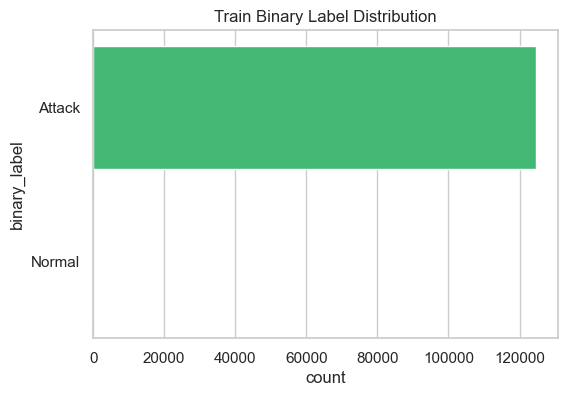

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_18724\1108215932.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(test_df['binary_label'], palette=["#3498db", "#e67e22"])


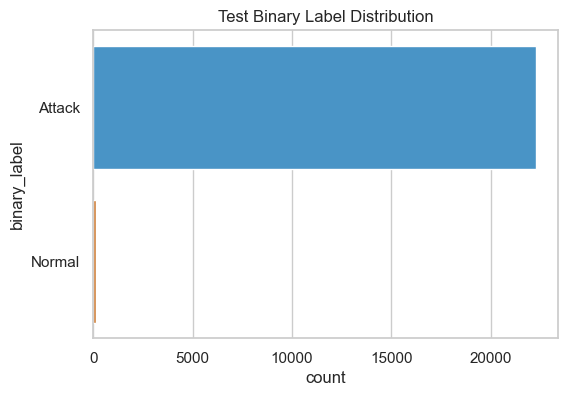

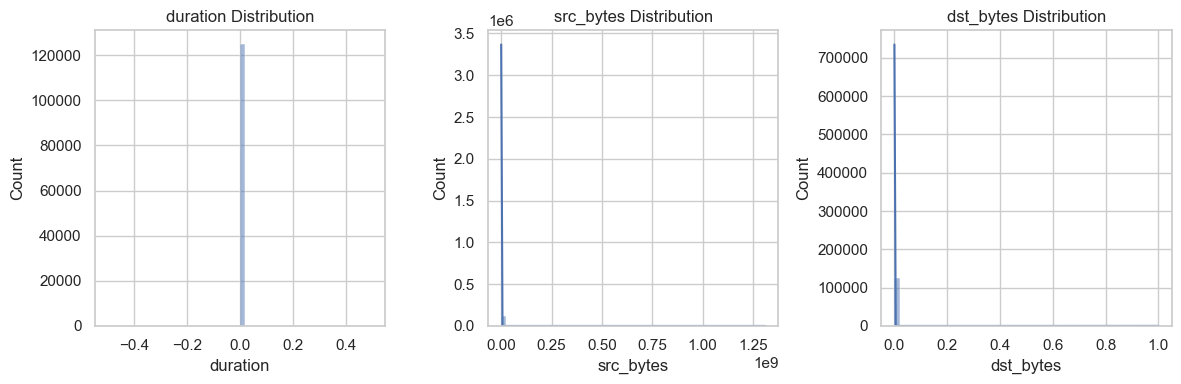

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_18724\1108215932.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='protocol_type', data=X_train, palette='pastel')


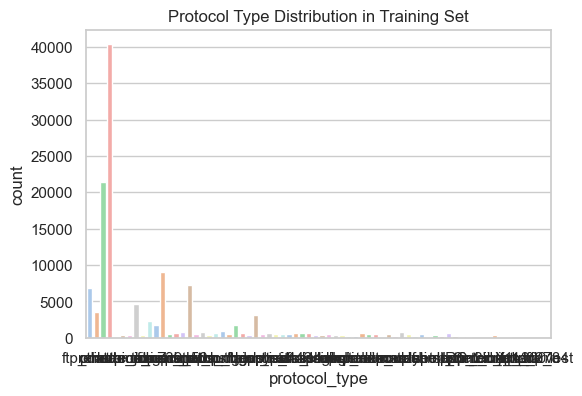


Training Logistic Regression

Training Decision Tree

Training Random Forest

Training Gradient Boosting

Model Performance Metrics:
                 Model  Train Accuracy  Train Sensitivity  Train Specificity  \
0  Logistic Regression        0.999607           0.999992           0.272727   
1        Decision Tree        1.000000           1.000000           1.000000   
2        Random Forest        1.000000           1.000000           1.000000   
3    Gradient Boosting        0.999511           0.999952           0.166667   

   Train Precision  Train F1  Train AUC  Test Accuracy  Test Sensitivity  \
0         0.999615  0.999803   0.013223       0.994513          1.000000   
1         1.000000  1.000000   0.000000       0.994424          0.999821   
2         1.000000  1.000000   0.000000       0.994513          1.000000   
3         0.999559  0.999755   0.648779       0.993978          0.999372   

   Test Specificity  Test Precision   Test F1  Test AUC  
0           0.00000       

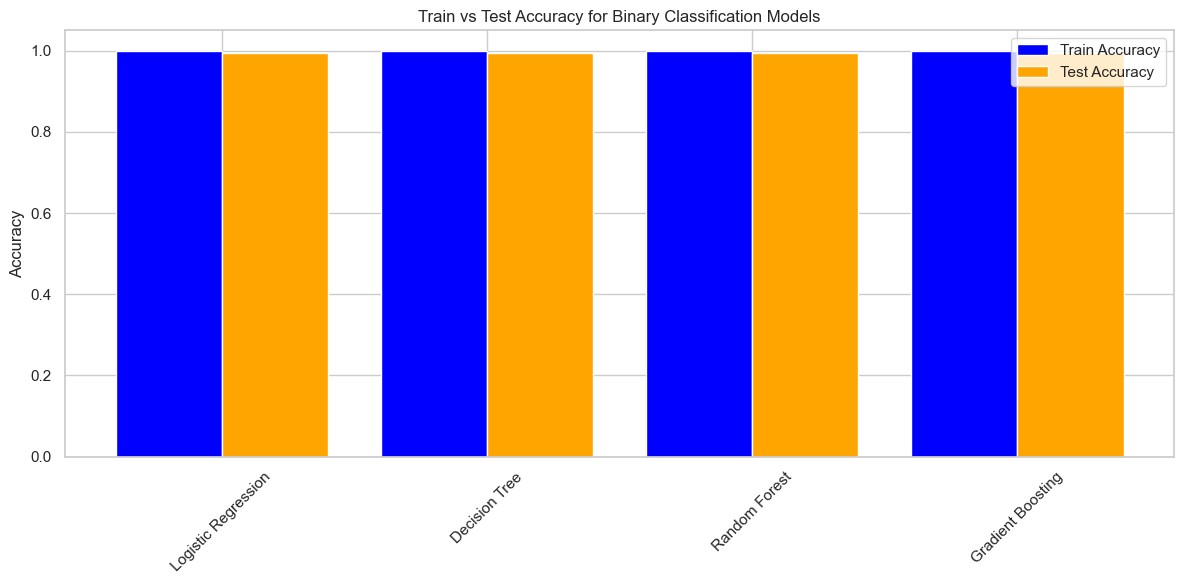

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

sns.set(style='whitegrid')

# Load dataset & columns
column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label"
]

train_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTrain+.txt'
test_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTest+.txt'

train_df = pd.read_csv(train_file, names=column_names)
test_df = pd.read_csv(test_file, names=column_names)

# Map numeric labels to string names
label_map = {0:'normal',1:'neptune',2:'warezclient',3:'ipsweep',4:'portsweep',5:'teardrop',
             6:'nmap',7:'satan',8:'smurf',9:'guess_passwd',10:'pod',11:'buffer_overflow',
             12:'imap',13:'back',14:'land',15:'ftp_write',16:'multihop',17:'phf',
             18:'perl',19:'spy',20:'rootkit',21:'loadmodule'}

train_df['label'] = train_df['label'].map(label_map)
test_df['label'] = test_df['label'].map(label_map)

# Drop duplicates
train_df.drop_duplicates(inplace=True)
test_df.drop_duplicates(inplace=True)

# Create binary label Normal vs Attack
train_df['binary_label'] = train_df['label'].apply(lambda x: 'Normal' if x == 'normal' else 'Attack')
test_df['binary_label'] = test_df['label'].apply(lambda x: 'Normal' if x == 'normal' else 'Attack')

# Visualize Distribution
plt.figure(figsize=(6,4))
sns.countplot(train_df['binary_label'], palette=["#2ecc71", "#e74c3c"])
plt.title('Train Binary Label Distribution')
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(test_df['binary_label'], palette=["#3498db", "#e67e22"])
plt.title('Test Binary Label Distribution')
plt.show()

# Feature sets for training
X_train = train_df.drop(['label','binary_label'], axis=1)
y_train = train_df['binary_label']
X_test = test_df.drop(['label','binary_label'], axis=1)
y_test = test_df['binary_label']

categorical_features = ['protocol_type', 'service', 'flag']
numeric_features = [c for c in X_train.columns if c not in categorical_features]

# Fix numeric columns & fill NA
for col in numeric_features:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
X_train[numeric_features] = X_train[numeric_features].fillna(0)
X_test[numeric_features] = X_test[numeric_features].fillna(0)

# Visualize numeric distributions
plt.figure(figsize=(12,4))
for i,col in enumerate(['duration','src_bytes','dst_bytes']):
    plt.subplot(1,3,i+1)
    sns.histplot(X_train[col], bins=50, kde=True)
    plt.title(f'{col} Distribution')
plt.tight_layout()
plt.show()

# Visualize protocol_type categorical
plt.figure(figsize=(6,4))
sns.countplot(x='protocol_type', data=X_train, palette='pastel')
plt.title('Protocol Type Distribution in Training Set')
plt.show()

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Models to train
models = {
    'Logistic Regression': LogisticRegression(max_iter=300),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}

# Compute metrics including sensitivity, specificity, precision, F1, AUC for binary classification
def compute_metrics(y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label='Attack')
    recall = recall_score(y_true, y_pred, pos_label='Attack')  # sensitivity
    specificity = recall_score(y_true, y_pred, pos_label='Normal')
    f1 = f1_score(y_true, y_pred, pos_label='Attack')
    fpr, tpr, _ = roc_curve([1 if x=='Attack' else 0 for x in y_true], y_proba)
    auc_score = auc(fpr, tpr)
    return acc, recall, specificity, precision, f1, auc_score

# Train, predict and evaluate
results = []
for name, model in models.items():
    print(f"\nTraining {name}")
    model.fit(X_train_processed, y_train)

    train_pred = model.predict(X_train_processed)
    test_pred = model.predict(X_test_processed)

    # For probability, needed for AUC score
    if hasattr(model, "predict_proba"):
        train_proba = model.predict_proba(X_train_processed)[:, 1]
        test_proba = model.predict_proba(X_test_processed)[:, 1]
    else:
        # For models without predict_proba (e.g., some SVMs) use decision_function but LogisticReg/SVM have predict_proba generally
        train_proba = model.decision_function(X_train_processed)
        test_proba = model.decision_function(X_test_processed)

    # Training metrics
    train_metrics = compute_metrics(y_train, train_pred, train_proba)
    # Testing metrics
    test_metrics = compute_metrics(y_test, test_pred, test_proba)

    results.append({
        'Model': name,
        'Train Accuracy': train_metrics[0],
        'Train Sensitivity': train_metrics[1],
        'Train Specificity': train_metrics[2],
        'Train Precision': train_metrics[3],
        'Train F1': train_metrics[4],
        'Train AUC': train_metrics[5],
        'Test Accuracy': test_metrics[0],
        'Test Sensitivity': test_metrics[1],
        'Test Specificity': test_metrics[2],
        'Test Precision': test_metrics[3],
        'Test F1': test_metrics[4],
        'Test AUC': test_metrics[5]
    })

# Convert results to DataFrame and display
results_df = pd.DataFrame(results)
print("\nModel Performance Metrics:")
print(results_df)

# Plotting accuracy comparison with colors
plt.figure(figsize=(12,6))
x = range(len(results_df))
plt.bar(x, results_df['Train Accuracy'], width=0.4, label='Train Accuracy', color='blue')
plt.bar([i + 0.4 for i in x], results_df['Test Accuracy'], width=0.4, label='Test Accuracy', color='orange')
plt.xticks([i + 0.2 for i in x], results_df['Model'], rotation=45)
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy for Binary Classification Models')
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_16424\1190070129.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index, palette='Spectral')


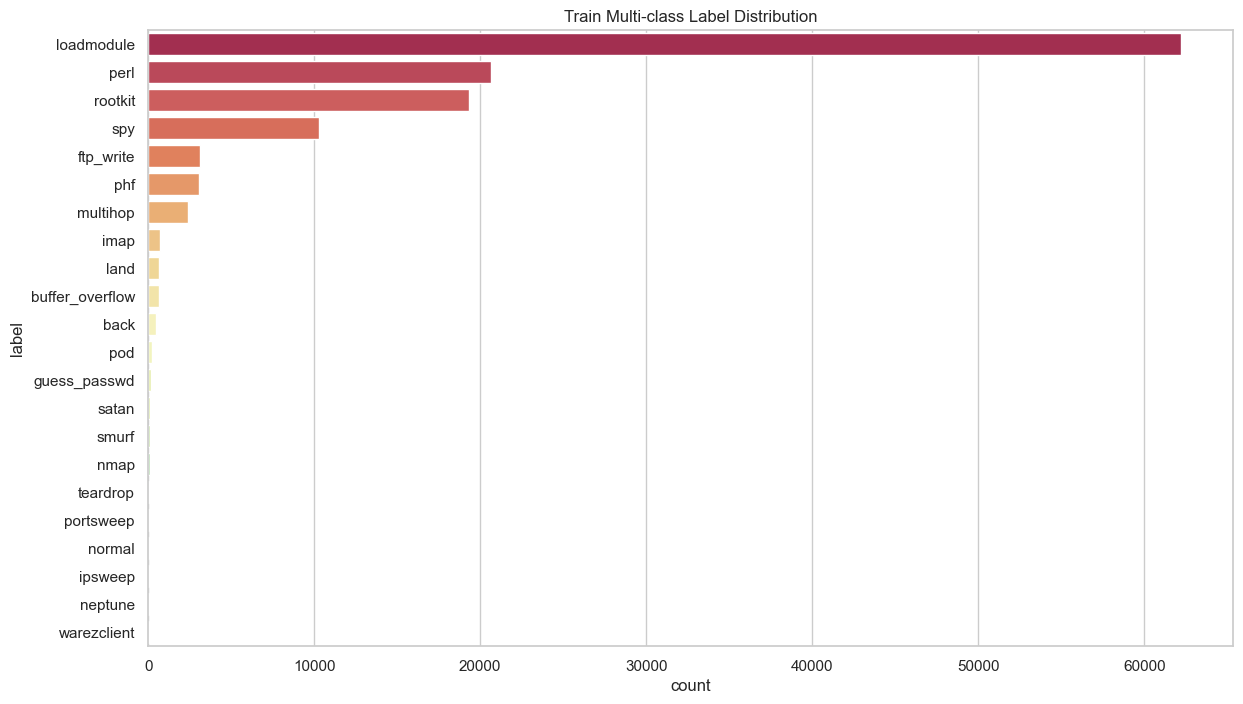

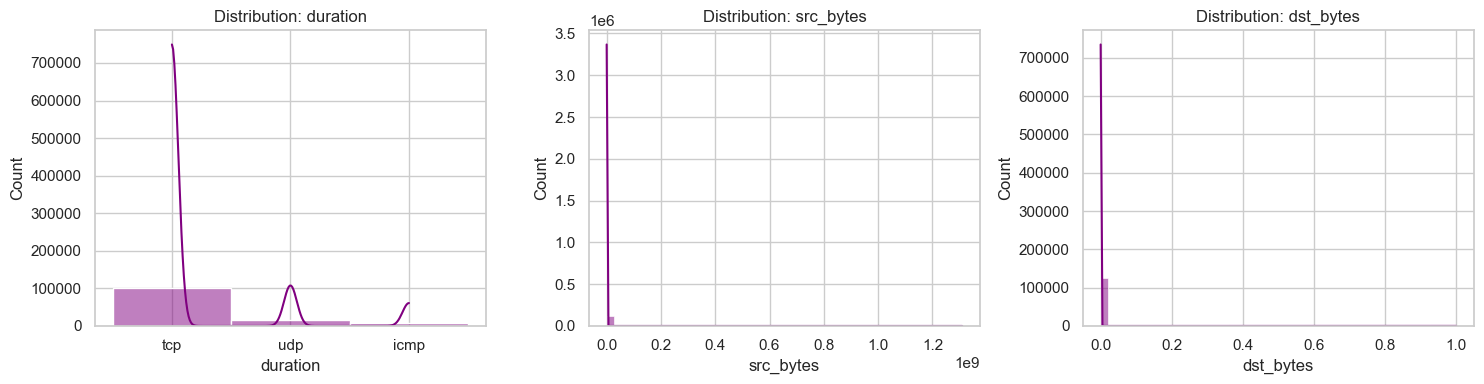

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_16424\1190070129.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='protocol_type', data=X_train, palette='pastel')


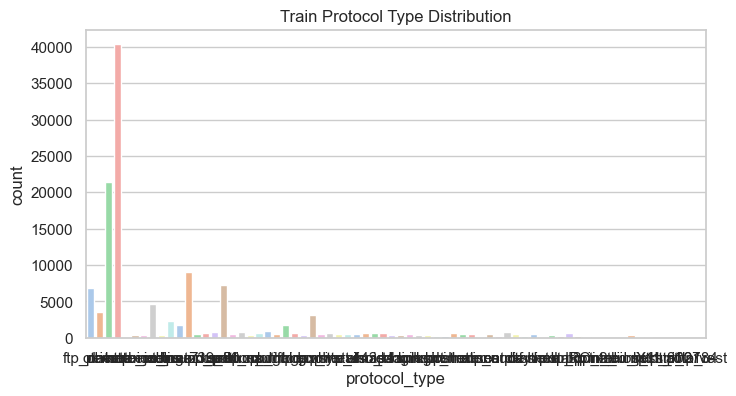

Training Logistic Regression...


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Train accuracy: 0.7074
Test accuracy: 0.5641


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Classification Report (Test):
                 precision    recall  f1-score   support

           back     0.0000    0.0000    0.0000       513
buffer_overflow     0.1216    0.0781    0.0951       461
      ftp_write     0.2847    0.0332    0.0594      1176
   guess_passwd     0.0000    0.0000    0.0000       106
           imap     0.0833    0.0041    0.0078       486
        ipsweep     0.0000    0.0000    0.0000       116
           land     0.0132    0.0027    0.0045       730
     loadmodule     0.7872    0.9591    0.8647     10694
       multihop     0.1434    0.0597    0.0843       670
        neptune     0.0000    0.0000    0.0000        87
           nmap     0.0000    0.0000    0.0000       157
         normal     0.0000    0.0000    0.0000       123
           perl     0.3482    0.4396    0.3886      2882
            phf     0.1336    0.0251    0.0423      1154
            pod     0.2727    0.0154    0.0291       195
      portsweep     0.0000    0.0000    0.0000       100


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Classification Report (Test):
                 precision    recall  f1-score   support

           back     0.1386    0.0273    0.0456       513
buffer_overflow     0.2258    0.0152    0.0285       461
      ftp_write     0.5123    0.1420    0.2224      1176
   guess_passwd     0.0392    0.0189    0.0255       106
           imap     0.1667    0.0185    0.0333       486
        ipsweep     0.0000    0.0000    0.0000       116
           land     0.1684    0.0658    0.0946       730
     loadmodule     0.7801    0.9739    0.8663     10694
       multihop     0.3778    0.1776    0.2416       670
        neptune     0.0000    0.0000    0.0000        87
           nmap     0.0000    0.0000    0.0000       157
         normal     0.2500    0.0163    0.0305       123
           perl     0.5358    0.6600    0.5914      2882
            phf     0.3832    0.0910    0.1471      1154
            pod     0.0720    0.0462    0.0563       195
      portsweep     0.0185    0.0100    0.0130       100


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Classification Report (Test):
                 precision    recall  f1-score   support

           back     0.0386    0.0409    0.0397       513
buffer_overflow     0.1778    0.0174    0.0316       461
      ftp_write     0.3171    0.0221    0.0413      1176
   guess_passwd     0.0091    0.0283    0.0138       106
           imap     0.0526    0.0062    0.0110       486
        ipsweep     0.0000    0.0000    0.0000       116
           land     0.1667    0.0055    0.0106       730
     loadmodule     0.8065    0.9693    0.8805     10694
       multihop     0.1622    0.0627    0.0904       670
        neptune     0.0000    0.0000    0.0000        87
           nmap     0.0000    0.0000    0.0000       157
         normal     0.1250    0.0163    0.0288       123
           perl     0.5358    0.6329    0.5803      2882
            phf     0.3041    0.1144    0.1662      1154
            pod     0.0000    0.0000    0.0000       195
      portsweep     0.2000    0.0100    0.0190       100


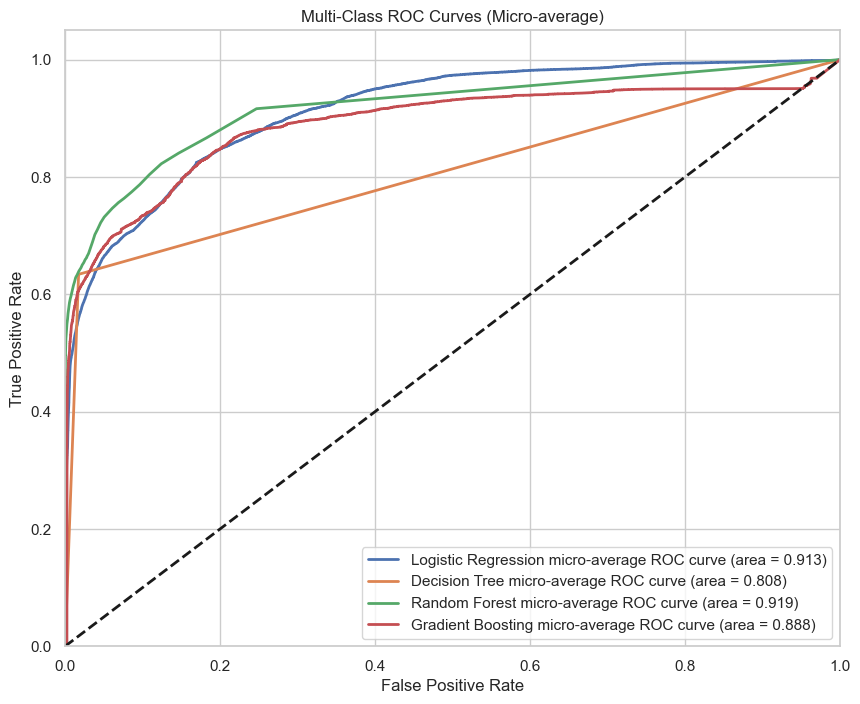

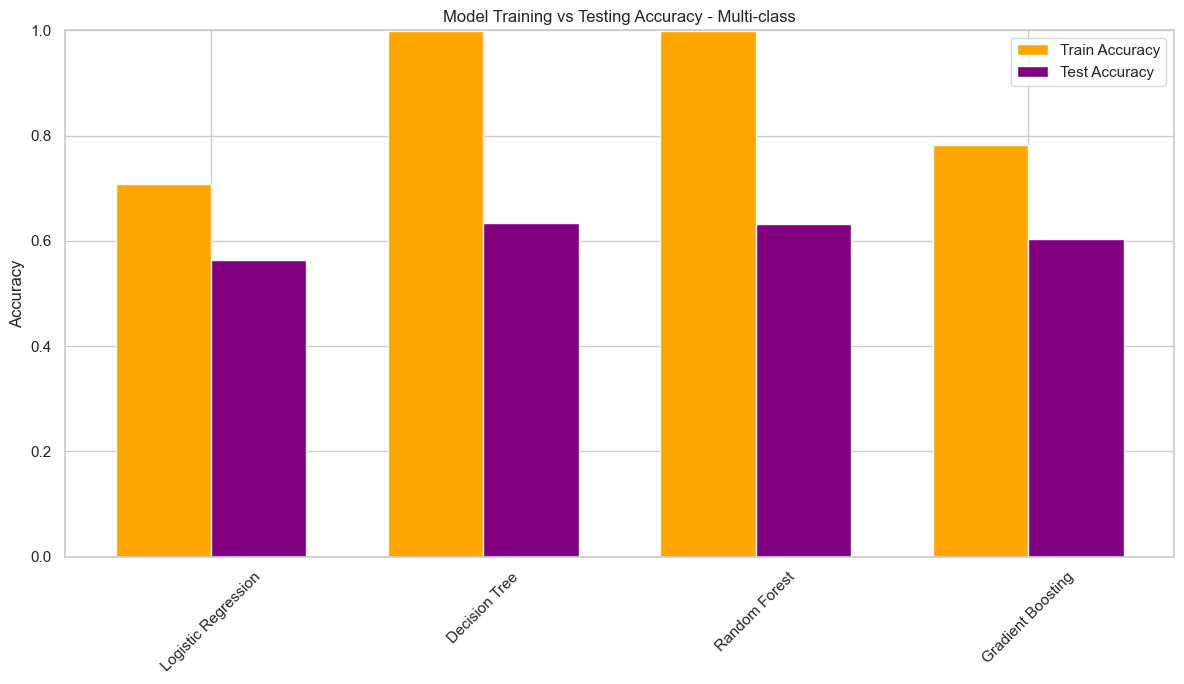

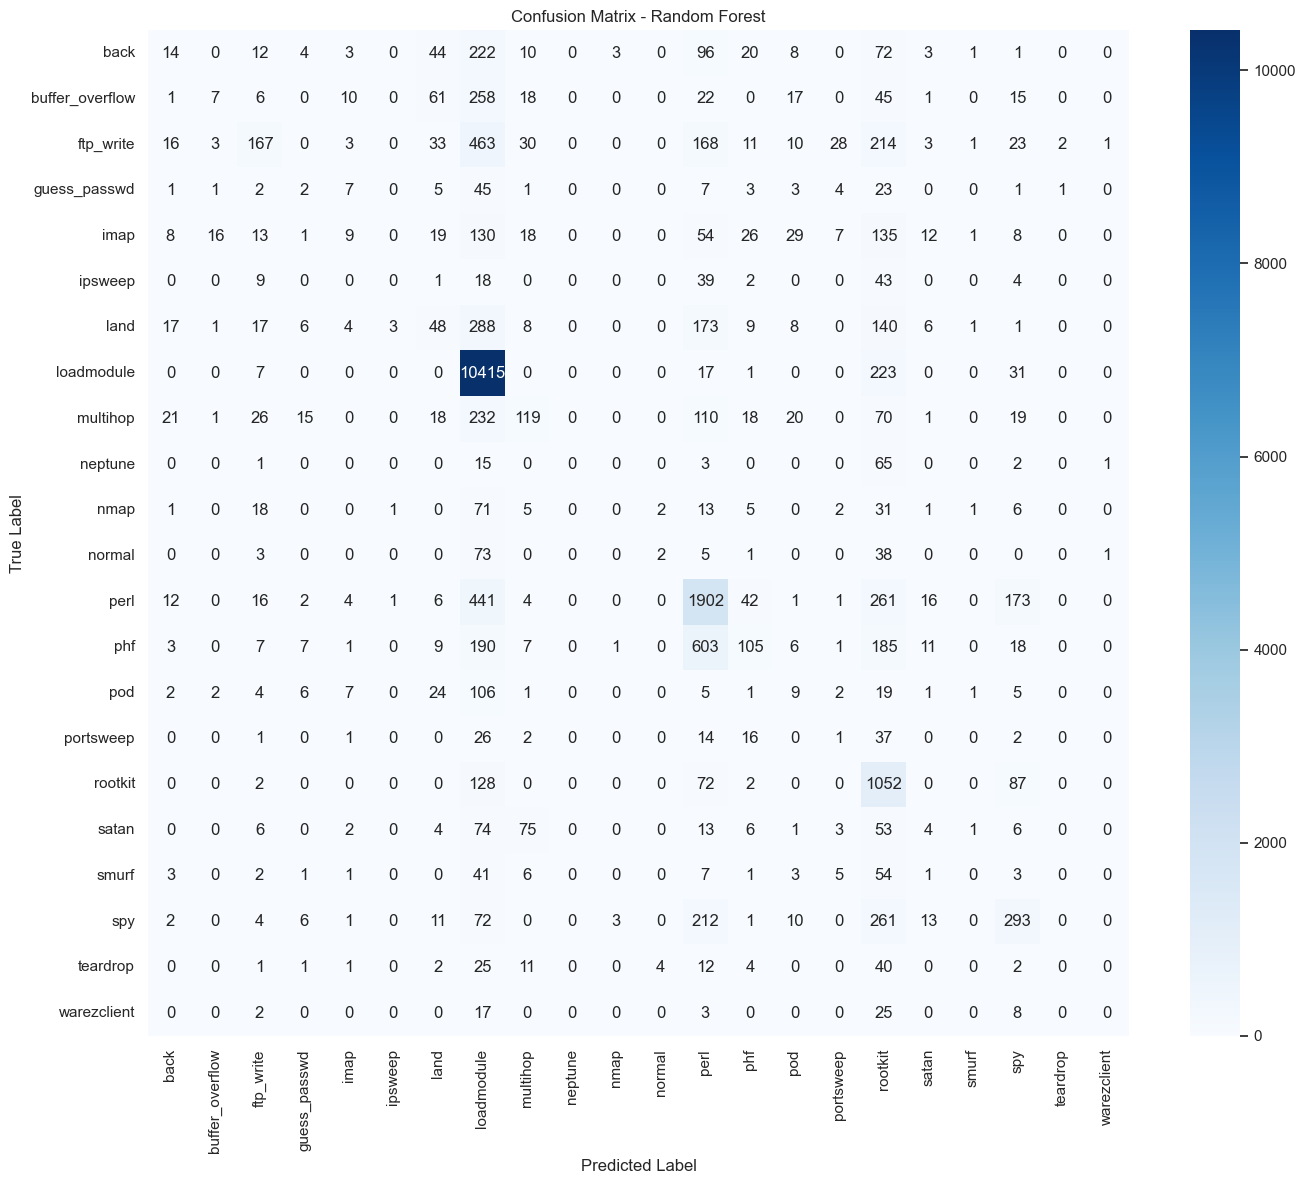

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

sns.set(style='whitegrid')

# Load NSL-KDD Dataset
column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label"
]

train_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTrain+.txt'  # Update your file path here
test_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTest+.txt'

train_df = pd.read_csv(train_file, names=column_names)
test_df = pd.read_csv(test_file, names=column_names)

# Map integers to attack names 
label_map = {
    0:'normal',1:'neptune',2:'warezclient',3:'ipsweep',4:'portsweep',5:'teardrop',
    6:'nmap',7:'satan',8:'smurf',9:'guess_passwd',10:'pod',11:'buffer_overflow',
    12:'imap',13:'back',14:'land',15:'ftp_write',16:'multihop',17:'phf',
    18:'perl',19:'spy',20:'rootkit',21:'loadmodule'
}

train_df['label'] = train_df['label'].map(label_map)
test_df['label'] = test_df['label'].map(label_map)

# Data Cleaning
train_df.drop_duplicates(inplace=True)
test_df.drop_duplicates(inplace=True)

# Visualize multi-class distribution
plt.figure(figsize=(14,8))
sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index, palette='Spectral')
plt.title('Train Multi-class Label Distribution')
plt.show()

# Prepare features and labels
X_train = train_df.drop(columns=['label'])
y_train = train_df['label']
X_test = test_df.drop(columns=['label'])
y_test = test_df['label']

categorical_features = ['protocol_type', 'service', 'flag']
numeric_features = [col for col in X_train.columns if col not in categorical_features]

# Visualize numeric features distribution
plt.figure(figsize=(15,4))
for i, col in enumerate(numeric_features[:3]):
    plt.subplot(1,3,i+1)
    sns.histplot(X_train[col], bins=50, kde=True, color='purple')
    plt.title(f'Distribution: {col}')
plt.tight_layout()
plt.show()

# Visualize a categorical feature frequency
plt.figure(figsize=(8,4))
sns.countplot(x='protocol_type', data=X_train, palette='pastel')
plt.title('Train Protocol Type Distribution')
plt.show()

# Convert numerics properly and fill NAs
for col in numeric_features:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

X_train[numeric_features] = X_train[numeric_features].fillna(0)
X_test[numeric_features] = X_test[numeric_features].fillna(0)

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Binarize labels for ROC (support multi-class ROC)
unique_classes = sorted(y_train.unique())
y_train_bin = label_binarize(y_train, classes=unique_classes)
y_test_bin = label_binarize(y_test, classes=unique_classes)

# Define Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=300,solver='saga'),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(),
}

train_acc = {}
test_acc = {}

plt.figure(figsize=(10,8))
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_processed, y_train)

    y_train_pred = model.predict(X_train_processed)
    y_test_pred = model.predict(X_test_processed)

    train_acc[name] = accuracy_score(y_train, y_train_pred)
    test_acc[name] = accuracy_score(y_test, y_test_pred)

    print(f"Train accuracy: {train_acc[name]:.4f}")
    print(f"Test accuracy: {test_acc[name]:.4f}")
    print(f"Classification Report (Test):\n{classification_report(y_test, y_test_pred, digits=4)}")

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_processed)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test_processed)
        if y_score.ndim == 1:
            y_score = np.vstack([1 - y_score, y_score]).T
    else:
        continue

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(len(unique_classes)):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Micro-average ROC curve
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    plt.plot(fpr["micro"], tpr["micro"], lw=2,
             label=f'{name} micro-average ROC curve (area = {roc_auc["micro"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curves (Micro-average)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Plot accuracy comparisons
labels = list(models.keys())
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12,7))
rects1 = ax.bar(x - width/2, [train_acc[l] for l in labels], width, label='Train Accuracy', color='orange')
rects2 = ax.bar(x + width/2, [test_acc[l] for l in labels], width, label='Test Accuracy', color='purple')

ax.set_ylabel('Accuracy')
ax.set_title('Model Training vs Testing Accuracy - Multi-class')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

# Confusion matrix for Random Forest (example)
best_model = models['Random Forest']
y_pred = best_model.predict(X_test_processed)

plt.figure(figsize=(14,12))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_classes, yticklabels=unique_classes)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


Using label column: Label


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26980\993809560.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[label_col], order=df[label_col].value_counts().index, palette='Spectral')


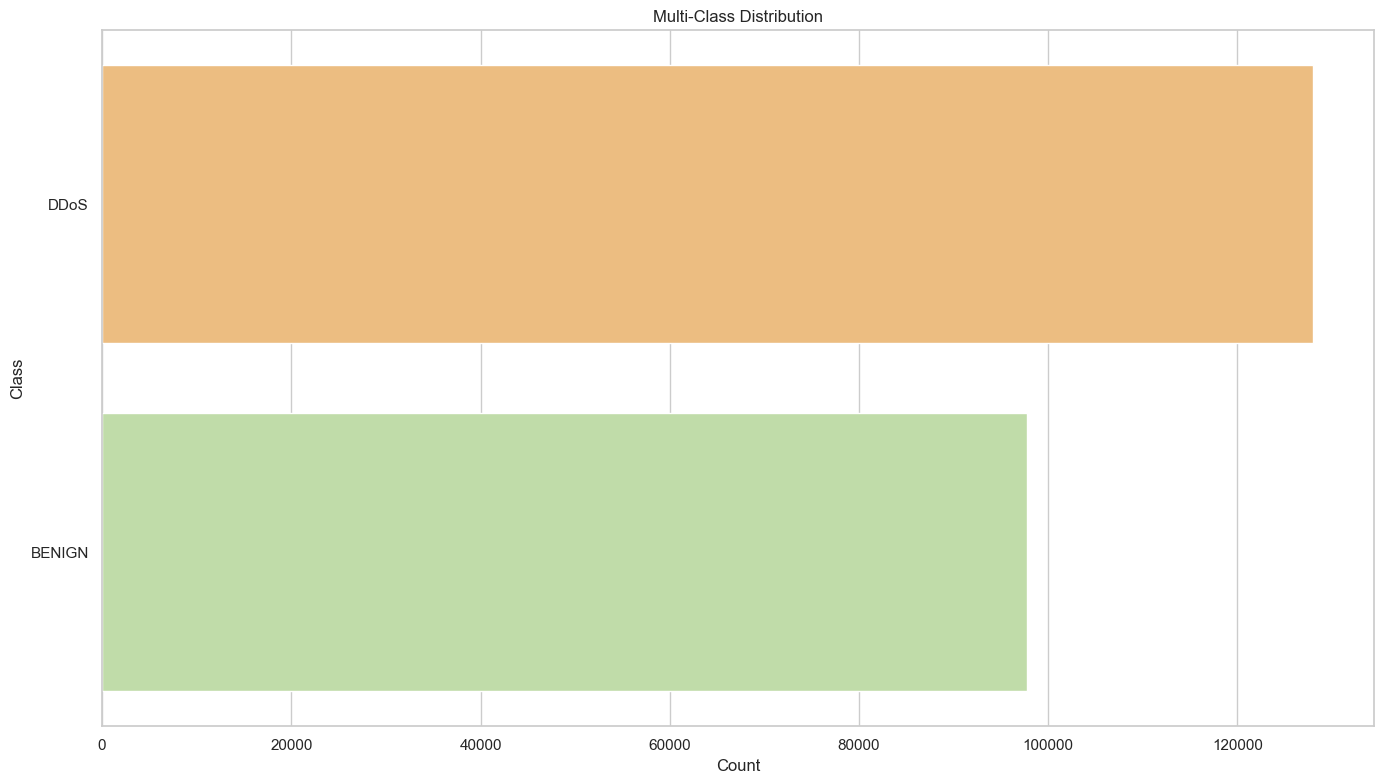

Missing values before dropping: 4
Missing values after dropping: 0
Duplicates before dropping: 2633
Duplicates after dropping: 0


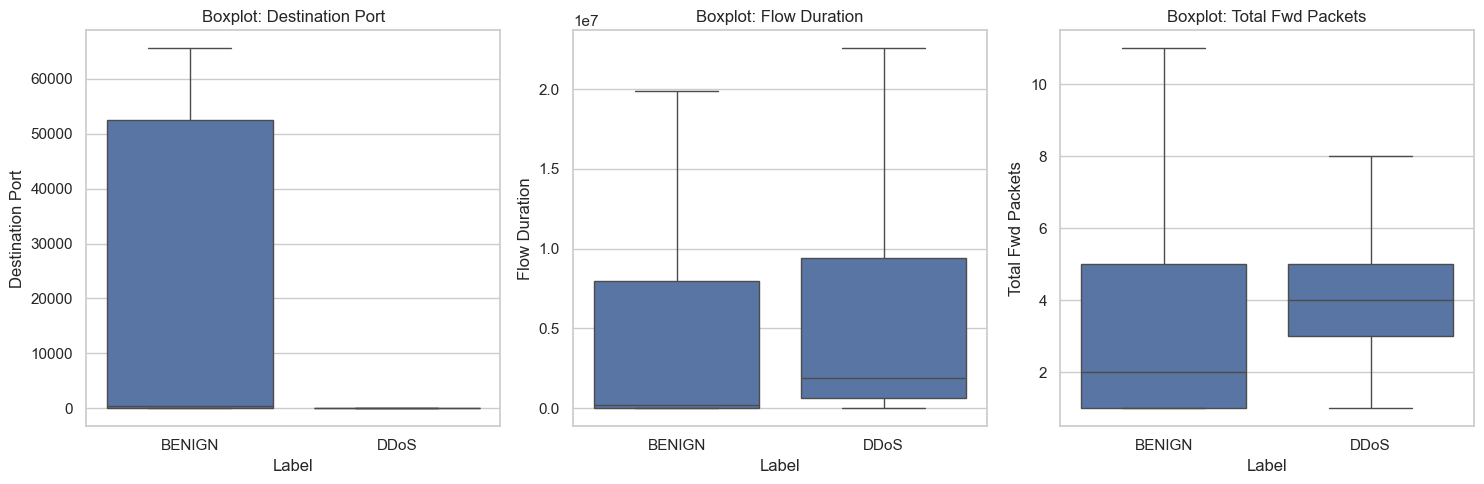

Training Logistic Regression...
Train accuracy: 0.9903
Test accuracy: 0.9900
Test Precision (macro): 0.9914
Test Recall (macro): 0.9883
Test F1-score (macro): 0.9897
Classification report for Logistic Regression:
              precision    recall  f1-score   support

      BENIGN     0.9996    0.9769    0.9881     28528
        DDoS     0.9831    0.9997    0.9914     38405

    accuracy                         0.9900     66933
   macro avg     0.9914    0.9883    0.9897     66933
weighted avg     0.9902    0.9900    0.9900     66933

Training Decision Tree...
Train accuracy: 1.0000
Test accuracy: 0.9998
Test Precision (macro): 0.9998
Test Recall (macro): 0.9998
Test F1-score (macro): 0.9998
Classification report for Decision Tree:
              precision    recall  f1-score   support

      BENIGN     0.9997    0.9999    0.9998     28528
        DDoS     0.9999    0.9998    0.9998     38405

    accuracy                         0.9998     66933
   macro avg     0.9998    0.9998    0.99

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26980\993809560.py:165: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


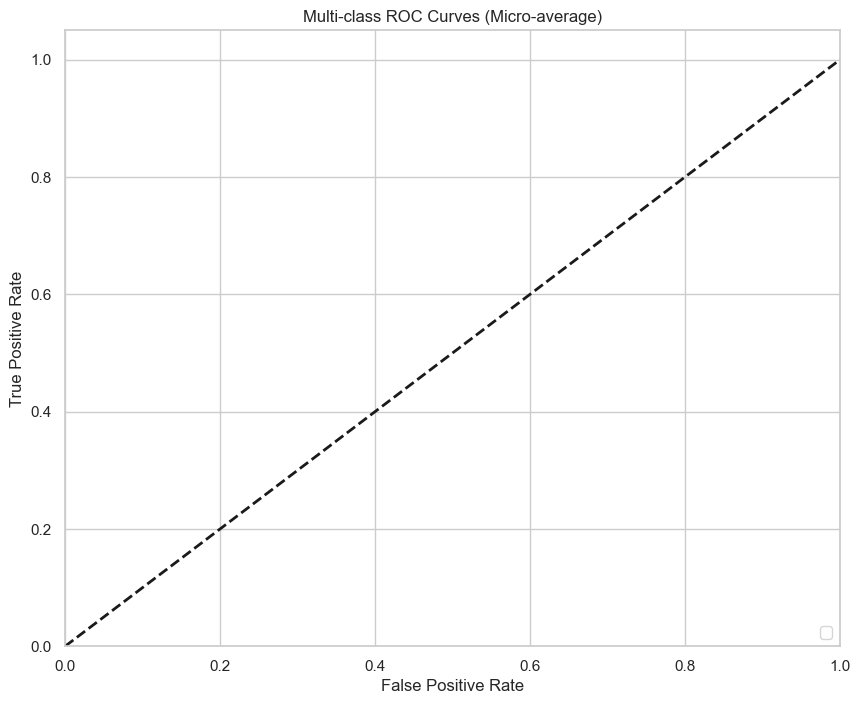

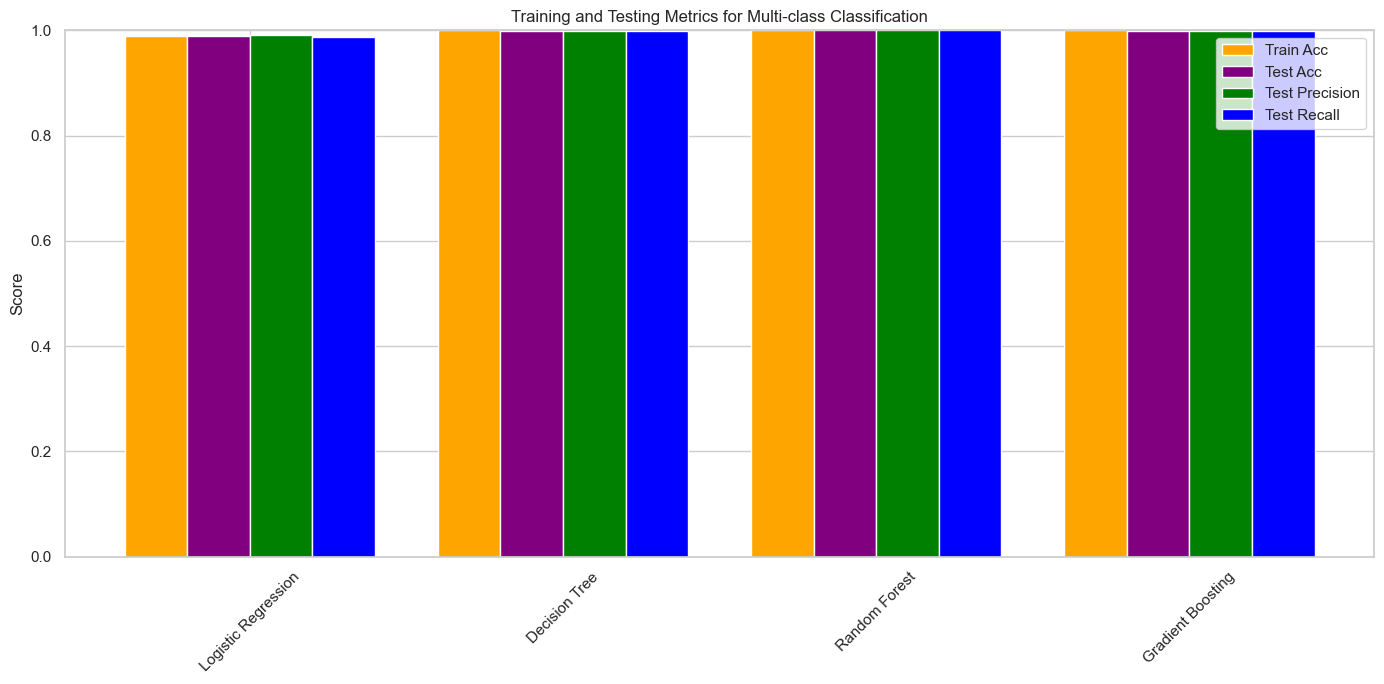

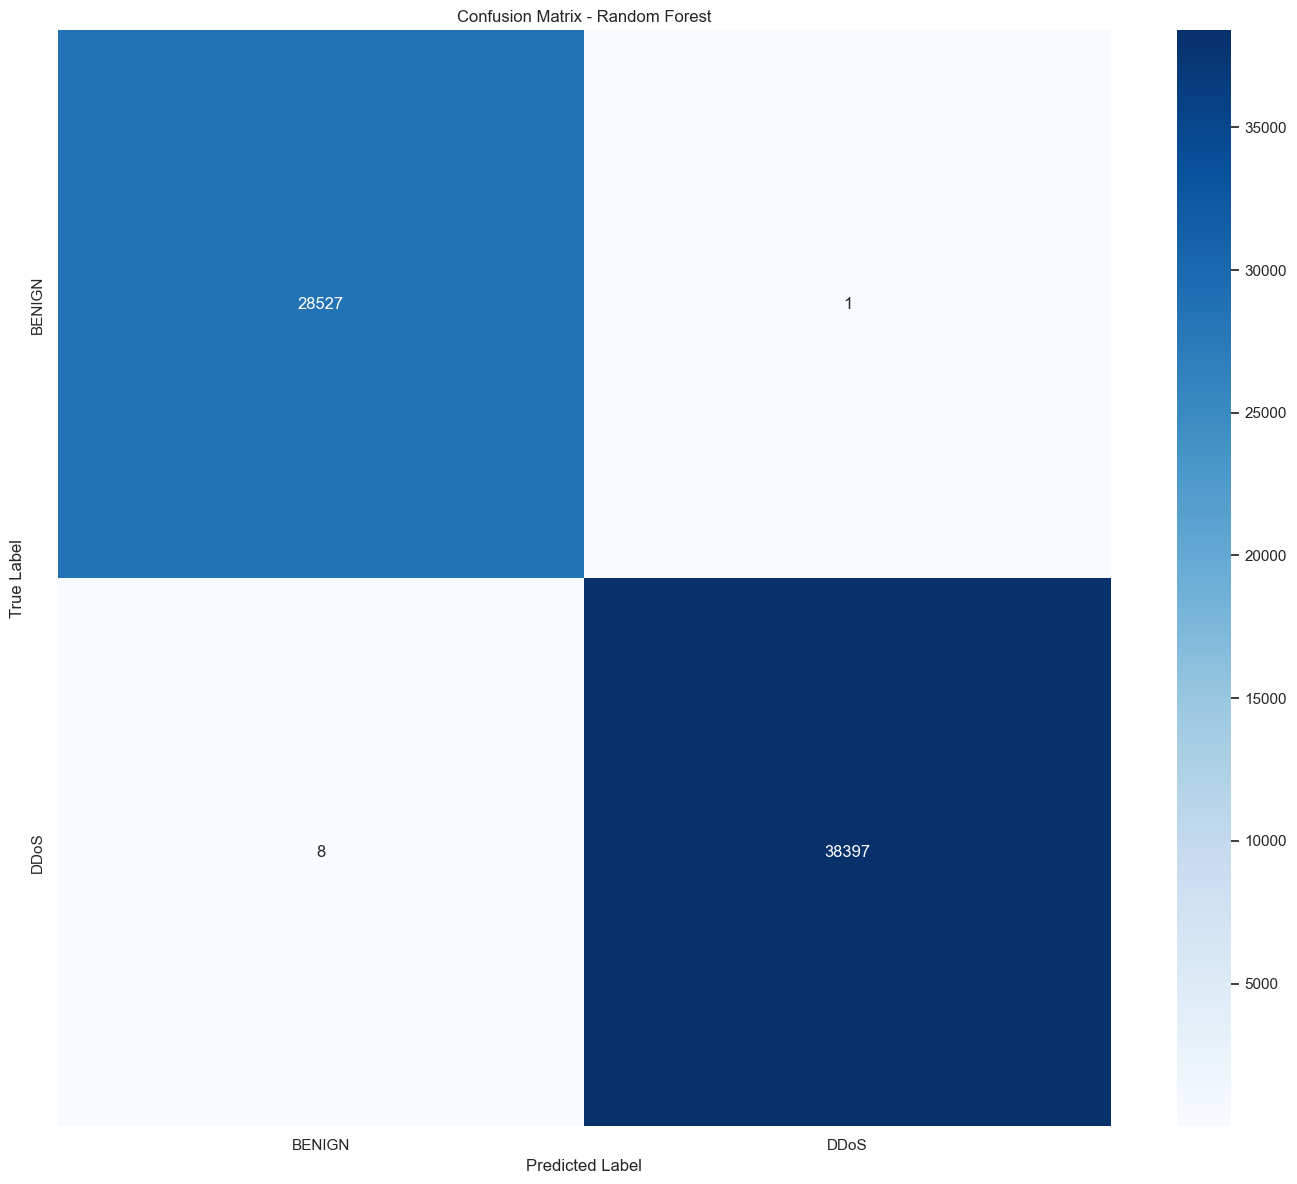

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             roc_curve, auc, precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

sns.set(style='whitegrid')

# Step 1: Load dataset
df = pd.read_csv(r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\CICIDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

# Auto-detect label column
df.columns = df.columns.str.strip()
label_candidates = ['Label', 'label', 'Flow Label', 'FlowLabel']
label_col = None
for col in label_candidates:
    if col in df.columns:
        label_col = col
        print(f"Using label column: {label_col}")
        break
if label_col is None:
    raise KeyError("Label column not found.")

# Step 2: Visualize class distribution
plt.figure(figsize=(14, 8))
sns.countplot(y=df[label_col], order=df[label_col].value_counts().index, palette='Spectral')
plt.title('Multi-Class Distribution')
plt.xlabel('Count')
plt.ylabel('Class')
plt.tight_layout()
plt.show()

# Step 3: Data cleaning
print(f"Missing values before dropping: {df.isnull().sum().sum()}")
df.dropna(inplace=True)
print(f"Missing values after dropping: {df.isnull().sum().sum()}")

print(f"Duplicates before dropping: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Duplicates after dropping: {df.duplicated().sum()}")

# Step 4: Prepare features and target
X = df.drop(columns=[label_col])
y = df[label_col]

# Step 5: Identify categorical & numeric features
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

# Step 6: Numeric features distribution
plt.figure(figsize=(15, 5))
for i, col in enumerate(numeric_features[:3]):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x=y, y=X[col], showfliers=False)
    plt.title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

# Step 7: Plot categorical distribution (if any)
if categorical_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=categorical_features[0], data=X, palette='pastel')
    plt.title(f'Distribution of {categorical_features[0]}')
    plt.tight_layout()
    plt.show()

# Step 8: Clean numeric data
X[numeric_features] = X[numeric_features].replace([np.inf, -np.inf], np.nan)
X[numeric_features] = X[numeric_features].fillna(0)
X[numeric_features] = X[numeric_features].clip(lower=-1e10, upper=1e10)

# Step 9: Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

X_processed = preprocessor.fit_transform(X)

# Step 10: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.3, stratify=y, random_state=42
)

# Step 11: Binarize labels for ROC
unique_classes = sorted(y.unique())
y_train_bin = label_binarize(y_train, classes=unique_classes)
y_test_bin = label_binarize(y_test, classes=unique_classes)

# Step 12: Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(),
}

train_acc, test_acc = dict(), dict()
test_precision, test_recall, test_f1 = dict(), dict(), dict()

plt.figure(figsize=(10, 8))

# Step 13: Train models, evaluate metrics, and plot ROC curves
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc[name] = accuracy_score(y_train, y_train_pred)
    test_acc[name] = accuracy_score(y_test, y_test_pred)

    # Macro-average precision, recall, and f1 scores
    test_precision[name] = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
    test_recall[name] = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
    test_f1[name] = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

    print(f"Train accuracy: {train_acc[name]:.4f}")
    print(f"Test accuracy: {test_acc[name]:.4f}")
    print(f"Test Precision (macro): {test_precision[name]:.4f}")
    print(f"Test Recall (macro): {test_recall[name]:.4f}")
    print(f"Test F1-score (macro): {test_f1[name]:.4f}")
    print(f"Classification report for {name}:\n{classification_report(y_test, y_test_pred, digits=4)}")

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    if y_score.ndim == 1:
        # convert shape (n_samples,) to (n_samples, 2)
        y_score = np.vstack([-y_score, y_score]).T
    else:
        continue

    for i in range(len(unique_classes)):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Calculate micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    plt.plot(
        fpr["micro"],
        tpr["micro"],
        lw=2,
        label=f"{name} micro-average ROC (area = {roc_auc['micro']:.3f})",
    )

plt.plot([0, 1], [0, 1], "k--", lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curves (Micro-average)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# Step 14: Plot accuracy, precision, recall, and f1 score comparisons
labels = list(models.keys())
x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 7))
rects1 = ax.bar(x - 1.5 * width, [train_acc[l] for l in labels], width, label="Train Acc", color="orange")
rects2 = ax.bar(x - 0.5 * width, [test_acc[l] for l in labels], width, label="Test Acc", color="purple")
rects3 = ax.bar(x + 0.5 * width, [test_precision[l] for l in labels], width, label="Test Precision", color="green")
rects4 = ax.bar(x + 1.5 * width, [test_recall[l] for l in labels], width, label="Test Recall", color="blue")

ax.set_ylabel("Score")
ax.set_title("Training and Testing Metrics for Multi-class Classification")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


# Step 15: Confusion matrix for best model (Random Forest)
best_model = models["Random Forest"]
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=unique_classes, yticklabels=unique_classes)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26980\1447972359.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[label_col], order=df[label_col].value_counts().index, palette='Spectral')


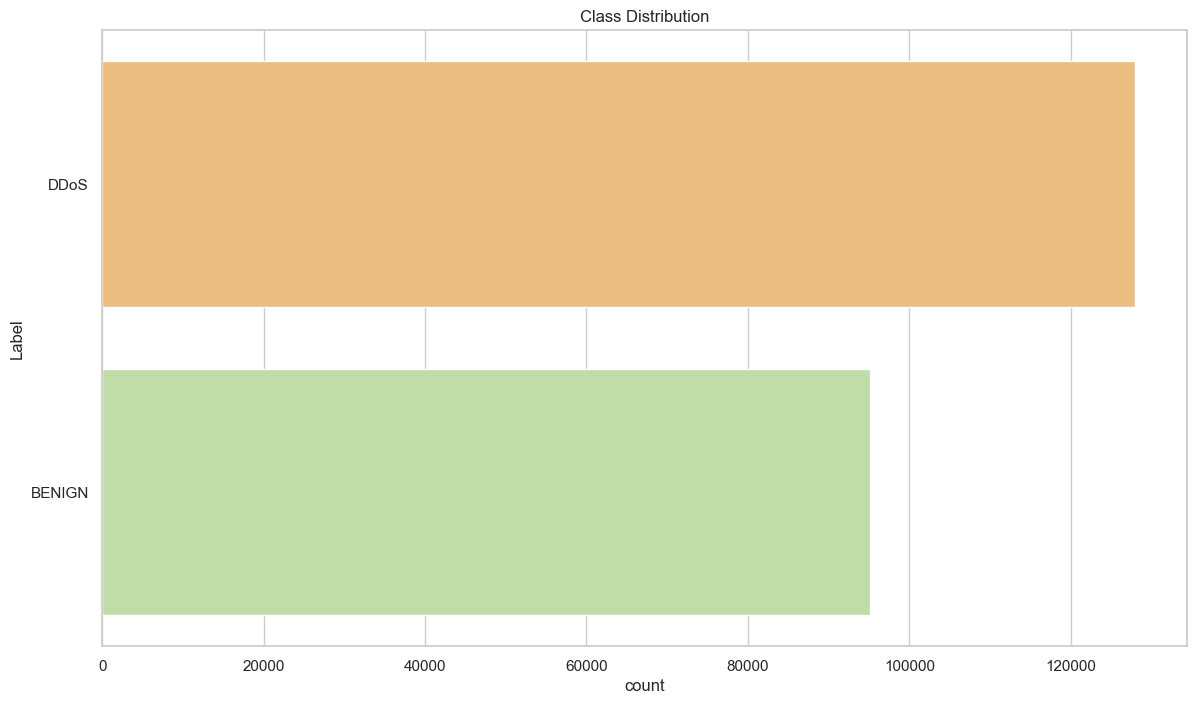

Training Logistic Regression
Train accuracy: 0.9903
Test accuracy: 0.9900
Precision (macro): 0.9914
Recall (macro): 0.9883
F1 (macro): 0.9897
              precision    recall  f1-score   support

      BENIGN       1.00      0.98      0.99     28528
        DDoS       0.98      1.00      0.99     38405

    accuracy                           0.99     66933
   macro avg       0.99      0.99      0.99     66933
weighted avg       0.99      0.99      0.99     66933

Training Decision Tree
Train accuracy: 1.0000
Test accuracy: 0.9998
Precision (macro): 0.9998
Recall (macro): 0.9998
F1 (macro): 0.9998
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     28528
        DDoS       1.00      1.00      1.00     38405

    accuracy                           1.00     66933
   macro avg       1.00      1.00      1.00     66933
weighted avg       1.00      1.00      1.00     66933

Training Random Forest
Train accuracy: 1.0000
Test accuracy: 0.9999


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26980\1447972359.py:132: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


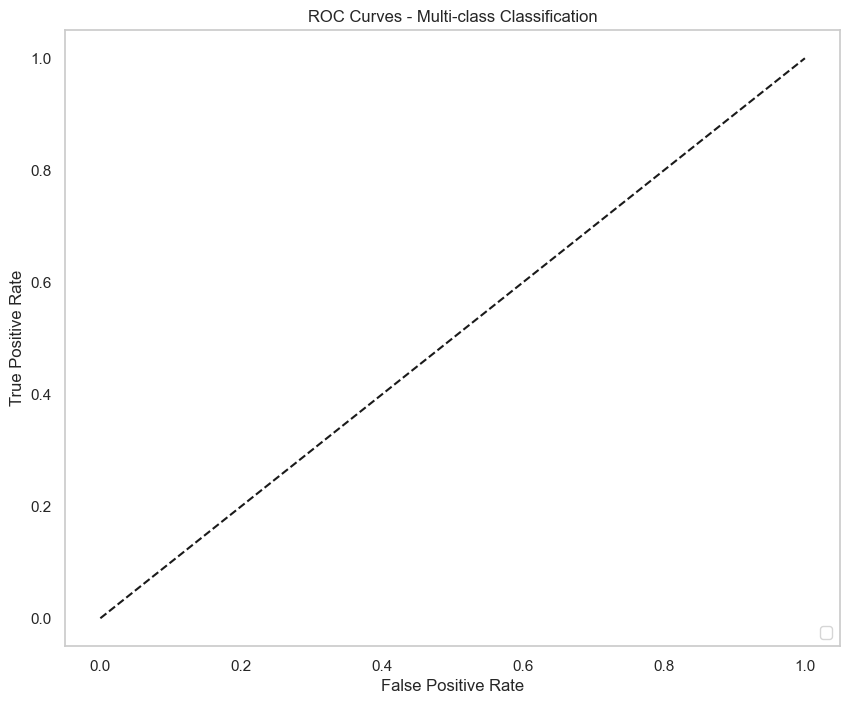

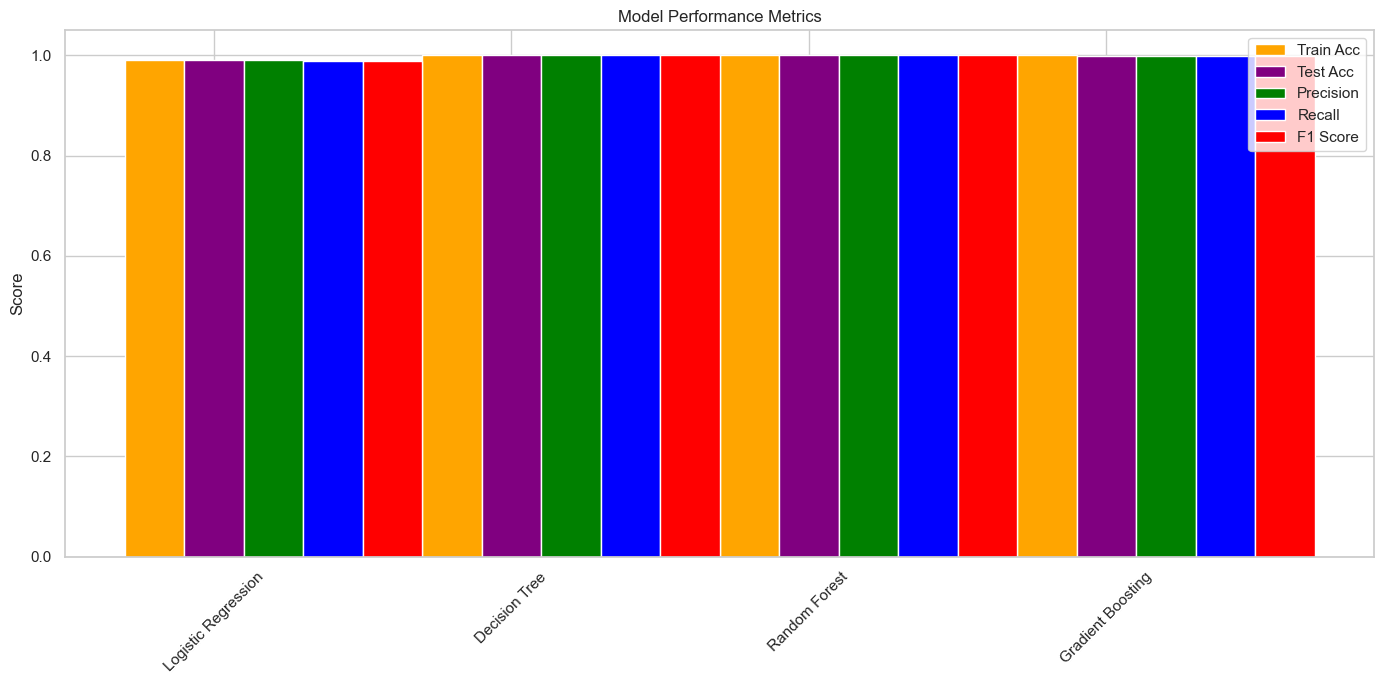

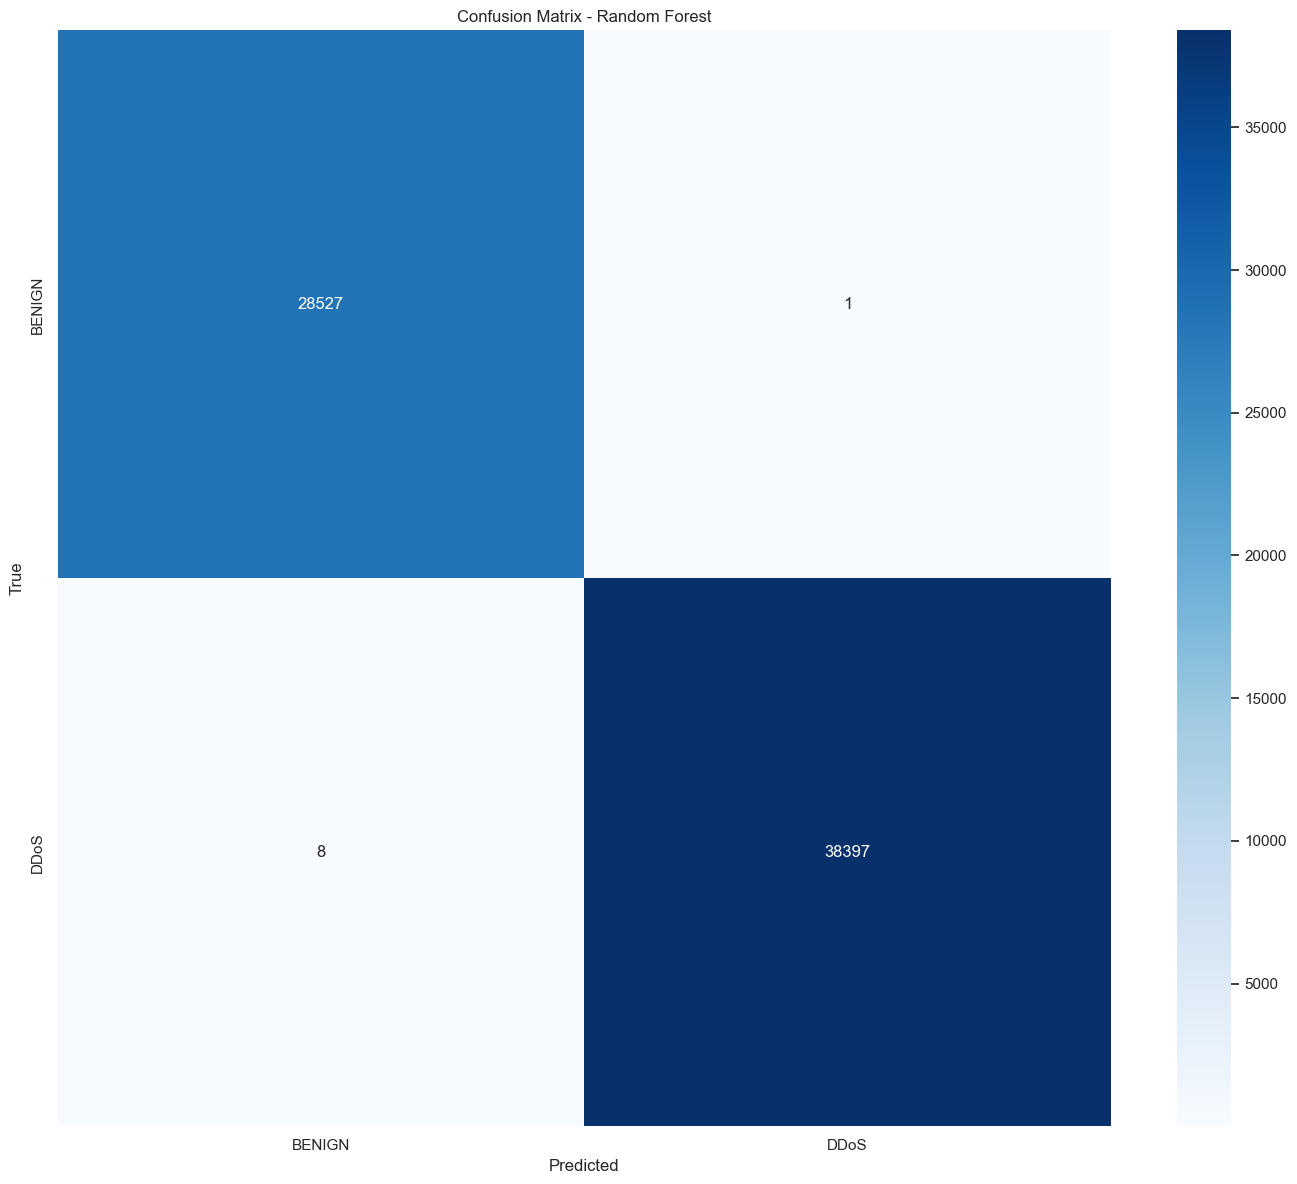

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

sns.set(style='whitegrid')

# Load data
df = pd.read_csv(r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\CICIDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')  
# Inspect columns and cleanup
print(df.columns)
df.columns = df.columns.str.strip()
print(df.columns)


# Detect label column
label_col_candidates = ['Label', 'label', 'Flow Label', 'FlowLabel']
label_col = None
for col in label_col_candidates:
    if col in df.columns:
        label_col = col
        print(f"Using label column: {label_col}")
        break
if not label_col:
    raise KeyError('Label column not found.')

# Clean data
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# Visualize
plt.figure(figsize=(14,8))
sns.countplot(y=df[label_col], order=df[label_col].value_counts().index, palette='Spectral')
plt.title('Class Distribution')
plt.show()

# Features, target
X = df.drop(columns=[label_col])
y = df[label_col]

# Feature types
cat_feats = X.select_dtypes(include='object').columns.tolist()
num_feats = X.select_dtypes(include=np.number).columns.tolist()

# Clean numeric features
X[num_feats] = X[num_feats].replace([np.inf, -np.inf], np.nan).fillna(0)

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats)
])

X_processed = preprocessor.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.3, stratify=y, random_state=42)

# Binarize labels for ROC
unique_classes = sorted(y.unique())
y_train_bin = label_binarize(y_train, classes=unique_classes)
y_test_bin = label_binarize(y_test, classes=unique_classes)

# Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(),
}

train_acc, test_acc = {}, {}
precision, recall, f1 = {}, {},{}

plt.figure(figsize=(10,8))

for name, model in models.items():
    print(f"Training {name}")
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_acc[name] = accuracy_score(y_train, y_train_pred)
    test_acc[name] = accuracy_score(y_test, y_test_pred)
    
    precision[name] = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
    recall[name] = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
    f1[name] = f1_score(y_test, y_test_pred, average='macro', zero_division=0)
    
    print(f"Train accuracy: {train_acc[name]:.4f}")
    print(f"Test accuracy: {test_acc[name]:.4f}")
    print(f"Precision (macro): {precision[name]:.4f}")
    print(f"Recall (macro): {recall[name]:.4f}")
    print(f"F1 (macro): {f1[name]:.4f}")
    print(classification_report(y_test, y_test_pred))
    
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    if y_score.ndim == 1:
        y_score = np.vstack([-y_score, y_score]).T
    else:
        continue
    
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(len(unique_classes)):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Micro-average ROC curve
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    plt.plot(fpr["micro"], tpr["micro"], label=f"{name} micro-average ROC (AUC={roc_auc['micro']:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Multi-class Classification")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Plot evaluation metrics
labels = list(models.keys())
x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(14,7))
ax.bar(x - width, [train_acc[l] for l in labels], width, label="Train Acc", color="orange")
ax.bar(x, [test_acc[l] for l in labels], width, label="Test Acc", color="purple")
ax.bar(x + width, [precision[l] for l in labels], width, label="Precision", color="green")
ax.bar(x + 2 * width, [recall[l] for l in labels], width, label="Recall", color="blue")
ax.bar(x + 3 * width, [f1[l] for l in labels], width, label="F1 Score", color="red")

ax.set_ylabel("Score")
ax.set_title("Model Performance Metrics")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

# Confusion matrix of best model (Random Forest)
best_model = models["Random Forest"]
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14,12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_classes, yticklabels=unique_classes)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

Binary Classification Final Results

Training Logistic Regression...

Training Decision Tree...

Training Random Forest...

Training Gradient Boosting...

Final Performance Metrics:
              Model  Sensitivity  Specificity  Precision  F1-Score   AUC Train Acc Val Acc Test Acc  Train Time (s)
Logistic Regression       1.0000       1.0000       0.99       1.0 0.739    99.96%  99.95%   99.45%            0.34
      Decision Tree       0.9999       0.9999       0.99       1.0 0.508   100.00%  99.96%   99.45%            1.19
      Random Forest       1.0000       1.0000       0.99       1.0 0.593   100.00%  99.96%   99.45%            6.31
  Gradient Boosting       0.9989       0.9989       0.99       1.0 0.512    99.94%  99.93%   99.36%           61.89


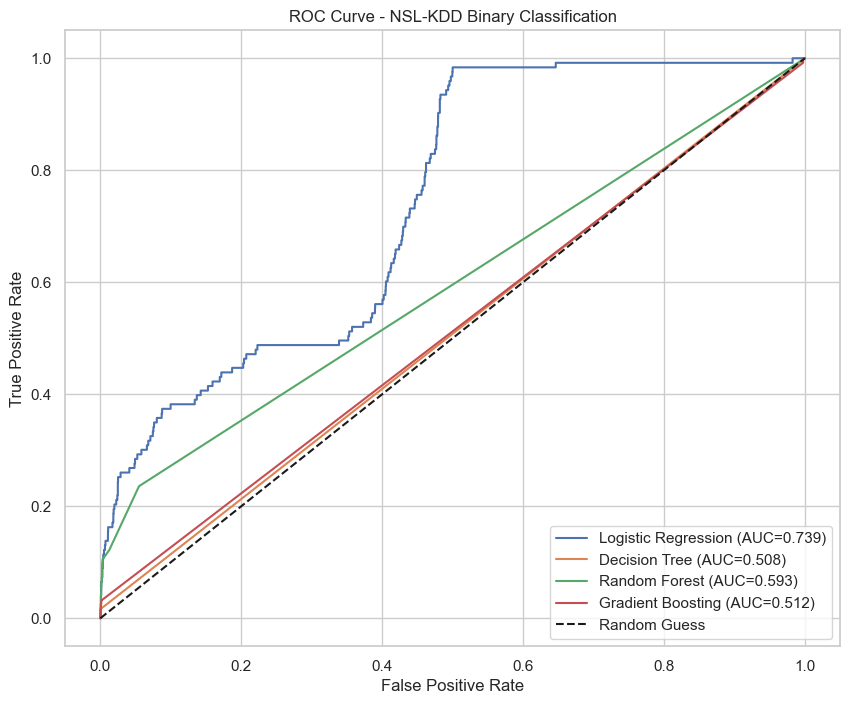

In [7]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split

sns.set(style='whitegrid')

# Load dataset
column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label"
]

train_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTrain+.txt'
test_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTest+.txt'

train_df = pd.read_csv(train_file, names=column_names)
test_df = pd.read_csv(test_file, names=column_names)

# Map numeric labels to attack types
label_map = {
    0:'normal', 1:'neptune', 2:'warezclient', 3:'ipsweep', 4:'portsweep', 5:'teardrop',
    6:'nmap', 7:'satan', 8:'smurf', 9:'guess_passwd', 10:'pod', 11:'buffer_overflow',
    12:'imap', 13:'back', 14:'land', 15:'ftp_write', 16:'multihop', 17:'phf',
    18:'perl', 19:'spy', 20:'rootkit', 21:'loadmodule'
}
train_df['label'] = train_df['label'].map(label_map)
test_df['label'] = test_df['label'].map(label_map)

# Drop duplicates
train_df.drop_duplicates(inplace=True)

# Binary label creation: normal vs attack
train_df['binary_label'] = train_df['label'].apply(lambda x: 'Normal' if x == 'normal' else 'Attack')
test_df['binary_label'] = test_df['label'].apply(lambda x: 'Normal' if x == 'normal' else 'Attack')

# Feature/target split
X_train_full = train_df.drop(['label', 'binary_label'], axis=1)
y_train_full = train_df['binary_label']

X_test = test_df.drop(['label', 'binary_label'], axis=1)
y_test = test_df['binary_label']

categorical_features = ['protocol_type', 'service', 'flag']
numeric_features = [col for col in X_train_full.columns if col not in categorical_features]

# Convert numeric columns and fill missing
for col in numeric_features:
    X_train_full[col] = pd.to_numeric(X_train_full[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

X_train_full[numeric_features] = X_train_full[numeric_features].fillna(0)
X_test[numeric_features] = X_test[numeric_features].fillna(0)

# Split train into train + validation for validation accuracy
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=42, stratify=y_train_full)

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Models for final evaluation
models = {
    'Logistic Regression': LogisticRegression(max_iter=300),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}

def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp)

lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)

results = []

print("Binary Classification Final Results")

for name, model in models.items():
    print(f"\nTraining {name}...")
    start_time = time.time()
    model.fit(X_train_processed, y_train)
    train_time = time.time() - start_time

    # Predictions
    train_preds = model.predict(X_train_processed)
    val_preds = model.predict(X_val_processed)
    test_preds = model.predict(X_test_processed)

    # Accuracies
    train_acc = accuracy_score(y_train, train_preds)
    val_acc = accuracy_score(y_val, val_preds)
    test_acc = accuracy_score(y_test, test_preds)

    # Metrics on test set
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, test_preds, average='binary', pos_label='Attack')
    spec = specificity_score(y_test, test_preds)

    # Sensitivity (Recall for Attack class)
    sensitivity = recall

    # AUC
    try:
        y_proba = model.predict_proba(X_test_processed)[:, 1]
    except AttributeError:
        y_proba = model.decision_function(X_test_processed)
        y_proba = (y_proba - y_proba.min())/(y_proba.max() - y_proba.min())  # Scale to [0,1]

    auc = roc_auc_score(y_test_bin, y_proba)

    # Store results
    results.append({
        'Model': name,
        'Sensitivity': round(sensitivity, 4),
        'Specificity': round(spec, 4),
        'Precision': round(precision, 2),
        'F1-Score': round(f1, 2),
        'AUC': round(auc, 3),
        'Train Acc': f"{train_acc*100:.2f}%",
        'Val Acc': f"{val_acc*100:.2f}%",
        'Test Acc': f"{test_acc*100:.2f}%",
        'Train Time (s)': round(train_time, 2)
    })

# Present final results table
final_results_df = pd.DataFrame(results)
print("\nFinal Performance Metrics:")
print(final_results_df.to_string(index=False))

# Optional: Plot ROC curves for all models
plt.figure(figsize=(10, 8))
for name, model in models.items():
    # Predict probabilities again for ROC plotting
    y_proba = model.predict_proba(X_test_processed)[:,1] if hasattr(model, "predict_proba") else None
    if y_proba is None:
        dec = model.decision_function(X_test_processed)
        y_proba = (dec - dec.min()) / (dec.max() - dec.min())
    fpr, tpr, _ = roc_curve(y_test_bin, y_proba)
    auc_val = roc_auc_score(y_test_bin, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('ROC Curve - NSL-KDD Binary Classification')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


=== Multi-class Classification Results ===

Training Logistic Regression...


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c

                 precision    recall  f1-score   support

           back     0.0000    0.0000    0.0000       519
buffer_overflow     0.1161    0.0781    0.0934       461
      ftp_write     0.4595    0.0723    0.1249      1176
   guess_passwd     0.0000    0.0000    0.0000       106
           imap     0.0000    0.0000    0.0000       486
        ipsweep     0.0000    0.0000    0.0000       116
           land     0.0000    0.0000    0.0000       736
     loadmodule     0.7477    0.9596    0.8405     10694
       multihop     0.1257    0.0352    0.0550       681
        neptune     0.0000    0.0000    0.0000        87
           nmap     0.0000    0.0000    0.0000       157
         normal     0.0000    0.0000    0.0000       123
           perl     0.4149    0.4685    0.4401      2967
            phf     0.0260    0.0017    0.0032      1168
            pod     0.2778    0.0256    0.0469       195
      portsweep     0.0000    0.0000    0.0000       101
        rootkit     0.2067    

c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c

                 precision    recall  f1-score   support

           back     0.0270    0.0039    0.0067       519
buffer_overflow     0.1562    0.0108    0.0203       461
      ftp_write     0.5016    0.1344    0.2119      1176
   guess_passwd     0.0455    0.0189    0.0267       106
           imap     0.1373    0.0144    0.0261       486
        ipsweep     0.0000    0.0000    0.0000       116
           land     0.1784    0.0448    0.0717       736
     loadmodule     0.8126    0.9739    0.8860     10694
       multihop     0.3108    0.1821    0.2296       681
        neptune     0.2500    0.0115    0.0220        87
           nmap     0.0000    0.0000    0.0000       157
         normal     0.3333    0.0163    0.0310       123
           perl     0.5451    0.6296    0.5843      2967
            phf     0.3235    0.0848    0.1343      1168
            pod     0.1719    0.0564    0.0849       195
      portsweep     0.0476    0.0099    0.0164       101
        rootkit     0.2666    

c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c

                 precision    recall  f1-score   support

           back     0.0391    0.0405    0.0398       519
buffer_overflow     0.1111    0.0022    0.0043       461
      ftp_write     0.3493    0.0680    0.1139      1176
   guess_passwd     0.0000    0.0000    0.0000       106
           imap     0.1429    0.0123    0.0227       486
        ipsweep     0.0000    0.0000    0.0000       116
           land     0.3182    0.0095    0.0185       736
     loadmodule     0.7545    0.9685    0.8482     10694
       multihop     0.2644    0.1145    0.1598       681
        neptune     0.0000    0.0000    0.0000        87
           nmap     0.0000    0.0000    0.0000       157
         normal     0.1176    0.0163    0.0286       123
           perl     0.4844    0.5177    0.5005      2967
            phf     0.2812    0.0771    0.1210      1168
            pod     0.0000    0.0000    0.0000       195
      portsweep     0.2000    0.0099    0.0189       101
        rootkit     0.2549    

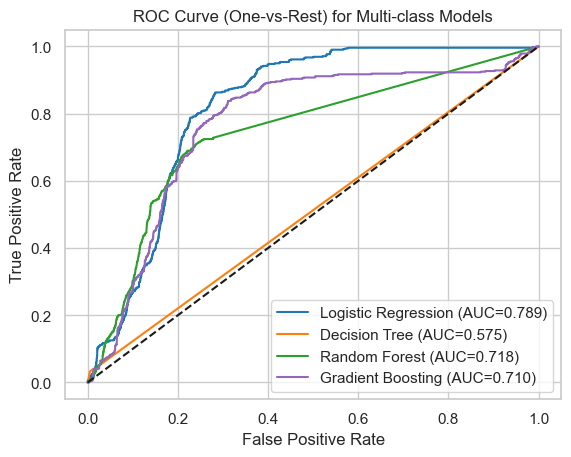

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26980\3505547064.py:167: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[res['Model'] for res in results], y=[res['Test Acc'] for res in results], palette=colors)


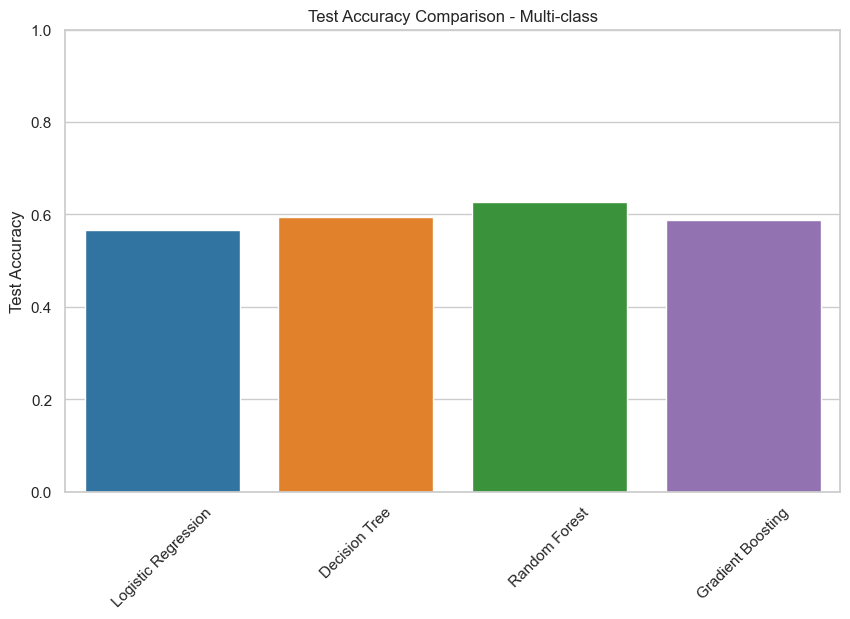


Summary of multi-class model performance:
                 Model  Train Acc  Test Acc  Macro Precision  Macro Recall  \
0  Logistic Regression   0.700035  0.566847         0.120196      0.108695   
1        Decision Tree   0.999559  0.594881         0.207317      0.148287   
2        Random Forest   0.999559  0.626065         0.213905      0.152410   
3    Gradient Boosting   0.774459  0.586852         0.168299      0.120832   

   Macro F1  Macro Specificity  AUC Macro (OvR)  Train Time (s)  
0  0.092476           0.972906         0.788554       18.503081  
1  0.142341           0.979326         0.575292      133.402866  
2  0.143726           0.977667         0.717897     1063.206199  
3  0.109427           0.974131         0.710464    16095.597285  


In [8]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelBinarizer, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier

sns.set(style='whitegrid')

# Load dataset
column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label"
]

train_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTrain+.txt'
test_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTest+.txt'

train_df = pd.read_csv(train_file, names=column_names)
test_df = pd.read_csv(test_file, names=column_names)

# Map numerical to attack types (multi-class labels)
label_map = {
    0:'normal', 1:'neptune', 2:'warezclient', 3:'ipsweep', 4:'portsweep', 5:'teardrop',
    6:'nmap', 7:'satan', 8:'smurf', 9:'guess_passwd', 10:'pod', 11:'buffer_overflow',
    12:'imap', 13:'back', 14:'land', 15:'ftp_write', 16:'multihop', 17:'phf',
    18:'perl', 19:'spy', 20:'rootkit', 21:'loadmodule'
}
train_df['label'] = train_df['label'].map(label_map)
test_df['label'] = test_df['label'].map(label_map)

# Drop duplicates
train_df.drop_duplicates(inplace=True)

# Feature and target split
X_train = train_df.drop(['label'], axis=1)
y_train = train_df['label']

X_test = test_df.drop(['label'], axis=1)
y_test = test_df['label']

categorical_features = ['protocol_type', 'service', 'flag']
numeric_features = [c for c in X_train.columns if c not in categorical_features]

# Convert numeric columns and handle missing values
for col in numeric_features:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

X_train[numeric_features] = X_train[numeric_features].fillna(0)
X_test[numeric_features] = X_test[numeric_features].fillna(0)

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Encode string labels to integers
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

# Binarize for multi-class ROC
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test_enc)  # shape (n_samples, n_classes)

models = {
    'Logistic Regression': LogisticRegression(max_iter=300),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']

def specificity_per_class(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    specificities = []
    for i in range(len(labels)):
        tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
        fp = cm[:,i].sum() - cm[i,i]
        specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
        specificities.append(specificity)
    return np.mean(specificities)

# Store results
results = []

print("=== Multi-class Classification Results ===")
for (name, model), color in zip(models.items(), colors):
    print(f"\nTraining {name}...")
    start_time = time.time()
    
    # Wrap model with OneVsRest for ROC/AUC support
    ovr_model = OneVsRestClassifier(model)
    ovr_model.fit(X_train_processed, y_train_enc)
    
    train_time = time.time() - start_time
    
    train_preds_enc = ovr_model.predict(X_train_processed)
    test_preds_enc = ovr_model.predict(X_test_processed)
    
    train_acc = accuracy_score(y_train_enc, train_preds_enc)
    test_acc = accuracy_score(y_test_enc, test_preds_enc)
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_test_enc, test_preds_enc, average='macro')
    spec = specificity_per_class(y_test_enc, test_preds_enc, labels=range(len(label_encoder.classes_)))
    
    # Probabilities for ROC AUC (use predict_proba or decision_function)
    try:
        y_proba = ovr_model.predict_proba(X_test_processed)
    except AttributeError:
        dec = ovr_model.decision_function(X_test_processed)
        # Scale decision values to [0, 1] per class
        y_proba = (dec - dec.min(axis=0)) / (dec.max(axis=0) - dec.min(axis=0))
    
    auc_macro = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')
    
    # ROC Curve plotting - take one class (e.g. first) for quick visualization
    fpr, tpr, _ = roc_curve(y_test_bin[:, 0], y_proba[:, 0])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_macro:.3f})', color=color)
    
    print(classification_report(y_test_enc, test_preds_enc, target_names=label_encoder.classes_, digits=4))
    
    results.append({
        'Model': name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Macro Precision': precision,
        'Macro Recall': recall,
        'Macro F1': f1,
        'Macro Specificity': spec,
        'AUC Macro (OvR)': auc_macro,
        'Train Time (s)': train_time
    })

plt.plot([0,1],[0,1],'k--')
plt.title('ROC Curve (One-vs-Rest) for Multi-class Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Accuracy Bar Plot
plt.figure(figsize=(10,6))
sns.barplot(x=[res['Model'] for res in results], y=[res['Test Acc'] for res in results], palette=colors)
plt.ylabel('Test Accuracy')
plt.ylim(0,1)
plt.title('Test Accuracy Comparison - Multi-class')
plt.xticks(rotation=45)
plt.show()

# Print summary table
summary_df = pd.DataFrame(results)
print("\nSummary of multi-class model performance:")
print(summary_df)


Using label column: Label


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26980\3349237371.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['BinaryLabel'], palette=["#2ecc71", "#e74c3c"])


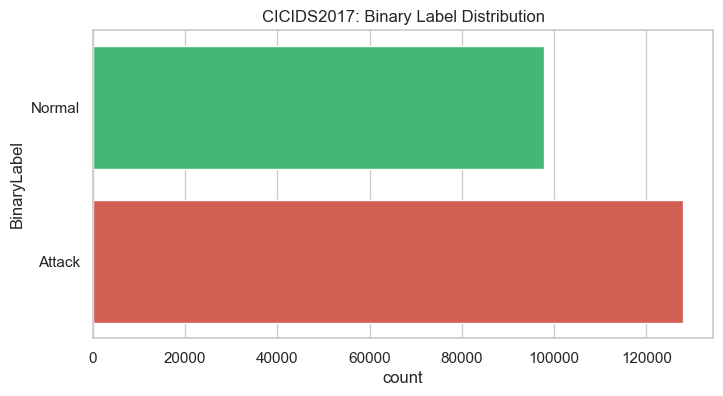

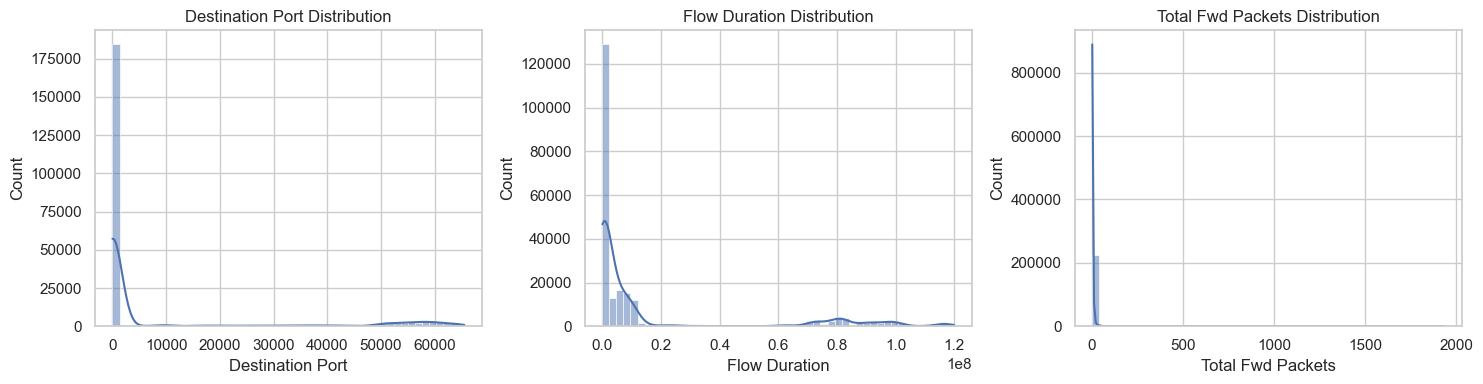

=== CICIDS2017 Binary Classification Results ===

Training Logistic Regression...
              precision    recall  f1-score   support

      Attack     0.9810    0.9996    0.9903     38408
      Normal     0.9995    0.9747    0.9869     29316

    accuracy                         0.9888     67724
   macro avg     0.9903    0.9872    0.9886     67724
weighted avg     0.9890    0.9888    0.9888     67724

Specificity: 0.9996, Training time: 13.24s, AUC: 0.9997

Training Decision Tree...
              precision    recall  f1-score   support

      Attack     0.9998    0.9998    0.9998     38408
      Normal     0.9997    0.9997    0.9997     29316

    accuracy                         0.9997     67724
   macro avg     0.9997    0.9997    0.9997     67724
weighted avg     0.9997    0.9997    0.9997     67724

Specificity: 0.9998, Training time: 3.95s, AUC: 0.9997

Training Random Forest...
              precision    recall  f1-score   support

      Attack     0.9999    0.9998    0.9999 

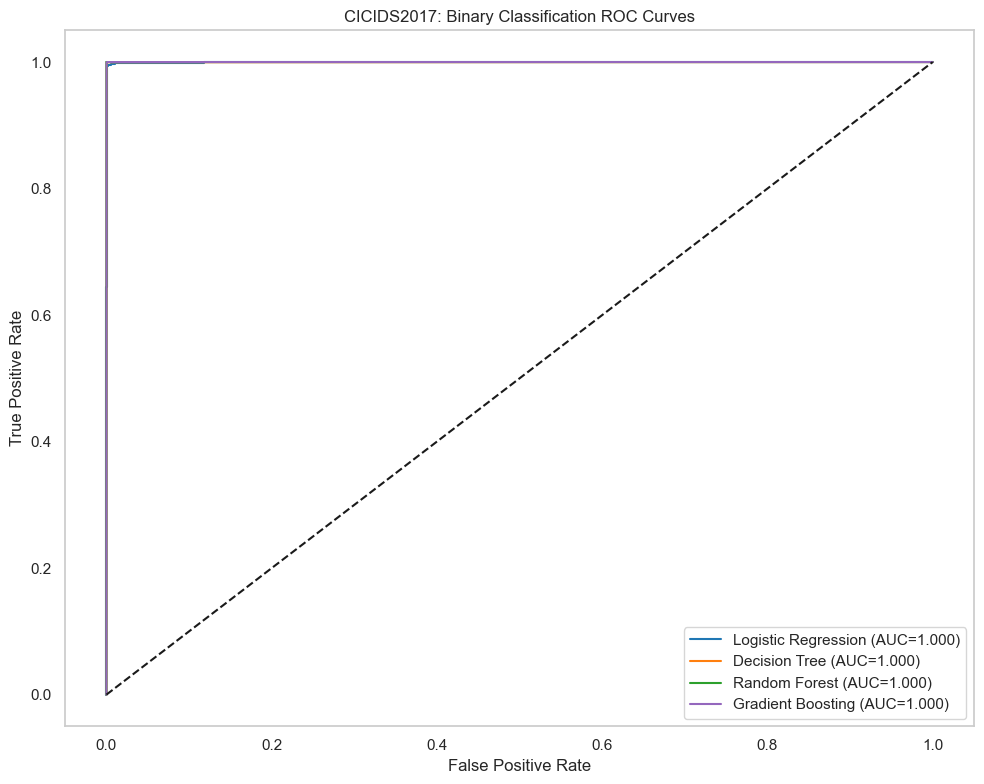


Summary Table:
                  Model  Train Acc  Test Acc  Precision    Recall        F1  \
0  Logistic Regression   0.988793  0.988837   0.999510  0.974690  0.986944   
1        Decision Tree   1.000000  0.999734   0.999693  0.999693  0.999693   
2        Random Forest   1.000000  0.999838   0.999727  0.999898  0.999812   
3    Gradient Boosting   0.999842  0.999734   0.999625  0.999761  0.999693   

   Specificity       AUC     Time(s)  
0     0.999635  0.999677   13.239944  
1     0.999766  0.999729    3.950470  
2     0.999792  1.000000   38.619892  
3     0.999714  0.999994  272.588721  


<function matplotlib.pyplot.figure(num: 'int | str | Figure | SubFigure | None' = None, figsize: 'ArrayLike | None' = None, dpi: 'float | None' = None, *, facecolor: 'ColorType | None' = None, edgecolor: 'ColorType | None' = None, frameon: 'bool' = True, FigureClass: 'type[Figure]' = <class 'matplotlib.figure.Figure'>, clear: 'bool' = False, **kwargs) -> 'Figure'>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, roc_curve,
                             auc, precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

sns.set(style='whitegrid')

# Step 1: Load Data
df = pd.read_csv(r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\CICIDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
df.columns = df.columns.str.strip()

# Detect label column
label_col_candidates = ['Label', 'label', 'Flow Label', 'FlowLabel']
label_col = None
for col in label_col_candidates:
    if col in df.columns:
        label_col = col
        print(f"Using label column: {label_col}")
        break
if label_col is None:
    raise KeyError("Label column not found.")

# Step 2: Map to binary labels
df['BinaryLabel'] = df[label_col].apply(lambda x: 'Normal' if str(x).upper() == 'BENIGN' else 'Attack')

# Visualize binary label distribution
plt.figure(figsize=(8,4))
sns.countplot(y=df['BinaryLabel'], palette=["#2ecc71", "#e74c3c"])
plt.title('CICIDS2017: Binary Label Distribution')
plt.show()

X = df.drop(columns=[label_col, 'BinaryLabel'])
y = df['BinaryLabel']

cat_feats = X.select_dtypes(include='object').columns.tolist()
num_feats = X.select_dtypes(include=[np.number]).columns.tolist()

# Visualize numeric distributions for first 3 numeric features
plt.figure(figsize=(15,4))
for i, col in enumerate(num_feats[:3]):
    plt.subplot(1,3,i+1)
    sns.histplot(X[col], bins=50, kde=True)
    plt.title(f"{col} Distribution")
plt.tight_layout()
plt.show()

# Clean numerics
X[num_feats] = X[num_feats].replace([np.inf, -np.inf], np.nan).fillna(0)

# Step 3: Preprocessing
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats)
])
X_processed = preprocessor.fit_transform(X)

# Encode binary labels
label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)  # Normal=0, Attack=1

# Step 4: Train-test split stratified
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_enc, test_size=0.3, random_state=42, stratify=y_enc)

# Step 5: Models setup
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, solver='saga'),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']

summary = []
plt.figure(figsize=(10,8))

print("=== CICIDS2017 Binary Classification Results ===")
for name, model in models.items():
    print(f"\nTraining {name}...")
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, zero_division=0)
    recall = recall_score(y_test, y_test_pred, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, zero_division=0)

    # Calculate specificity
    cm = confusion_matrix(y_test, y_test_pred)
    TN, FP, FN, TP = cm.ravel()
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    # ROC, AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})", color=colors.pop(0))

    print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_, digits=4))
    print(f"Specificity: {specificity:.4f}, Training time: {train_time:.2f}s, AUC: {roc_auc:.4f}")

    summary.append({
        'Model': name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Specificity': specificity,
        'AUC': roc_auc,
        'Time(s)': train_time
    })

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('CICIDS2017: Binary Classification ROC Curves')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Summary table
summary_df = pd.DataFrame(summary)
print("\nSummary Table:\n", summary_df)

# Accuracy and F1 bar plot
plt.figure


Using label column: Label


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26980\2899896791.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=y, palette='tab20')


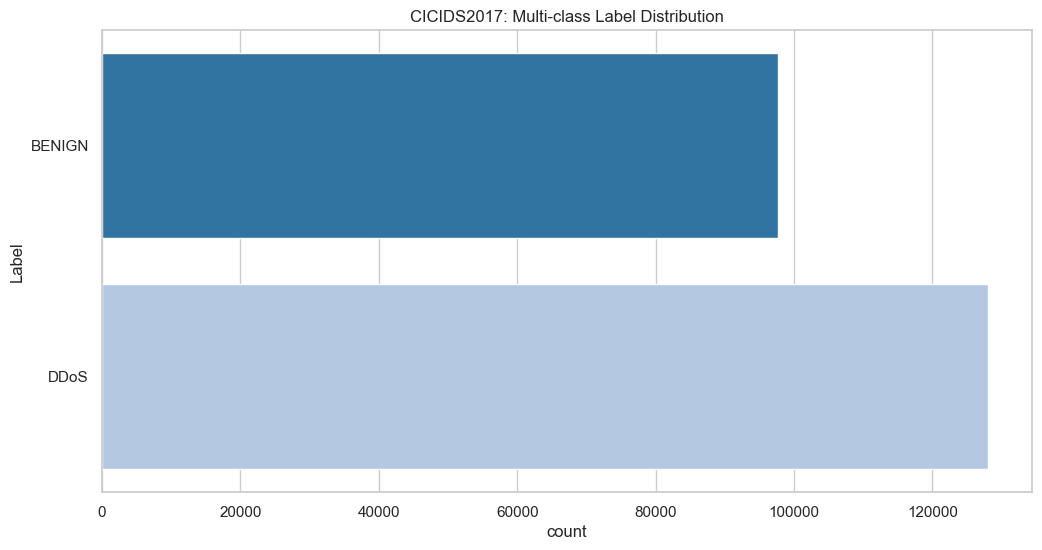

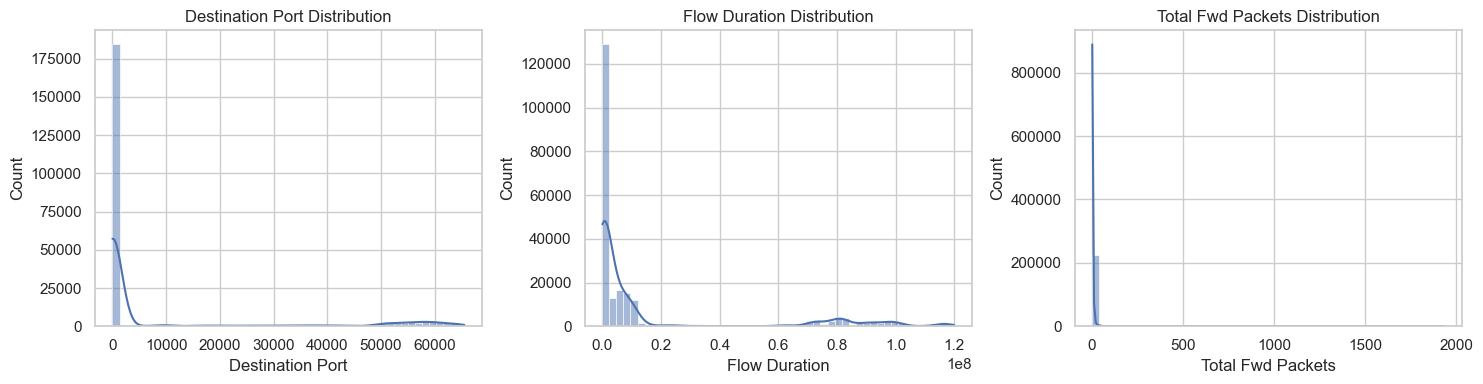

=== CICIDS2017 Multi-class Classification Results ===

Training Logistic Regression...
              precision    recall  f1-score   support

      BENIGN     0.9995    0.9749    0.9871     29316
        DDoS     0.9812    0.9996    0.9903     38408

    accuracy                         0.9889     67724
   macro avg     0.9904    0.9873    0.9887     67724
weighted avg     0.9891    0.9889    0.9889     67724


Training Decision Tree...
              precision    recall  f1-score   support

      BENIGN     0.9998    0.9998    0.9998     29316
        DDoS     0.9998    0.9998    0.9998     38408

    accuracy                         0.9998     67724
   macro avg     0.9998    0.9998    0.9998     67724
weighted avg     0.9998    0.9998    0.9998     67724


Training Random Forest...
              precision    recall  f1-score   support

      BENIGN     0.9999    1.0000    0.9999     29316
        DDoS     1.0000    0.9999    1.0000     38408

    accuracy                         1.00

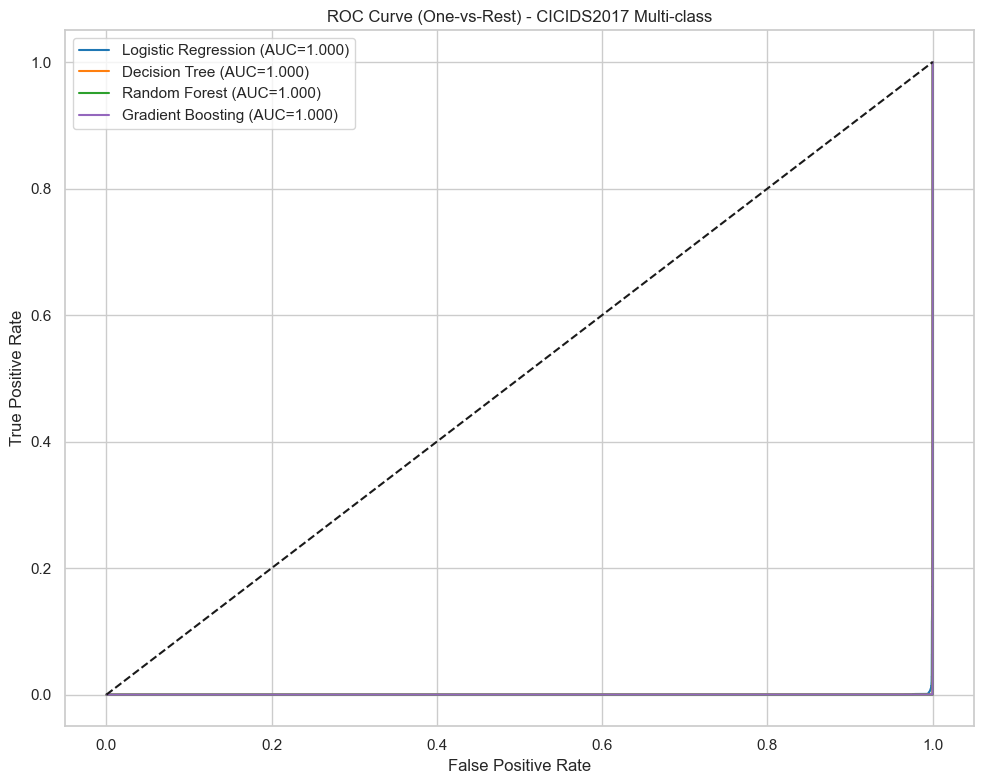

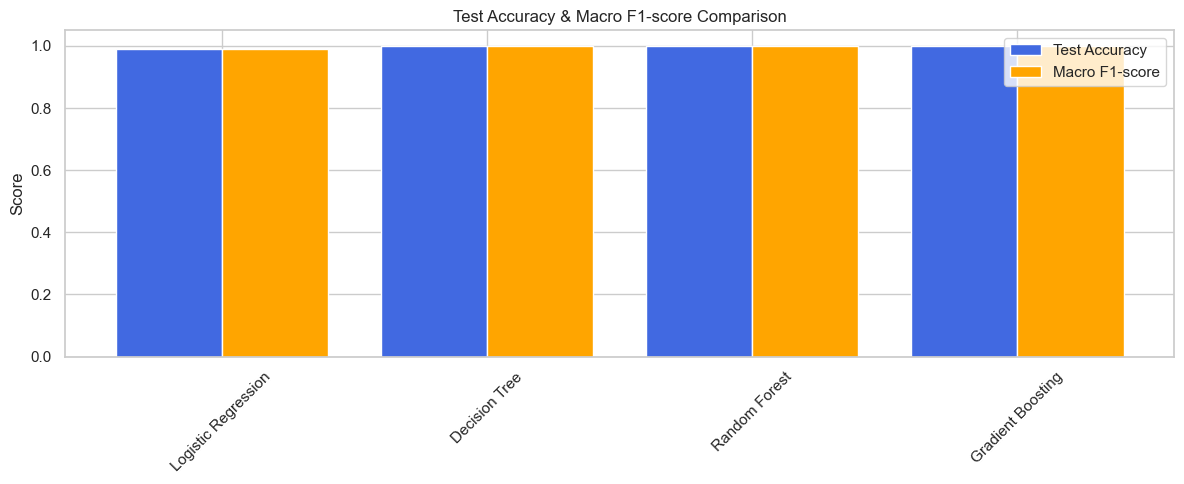

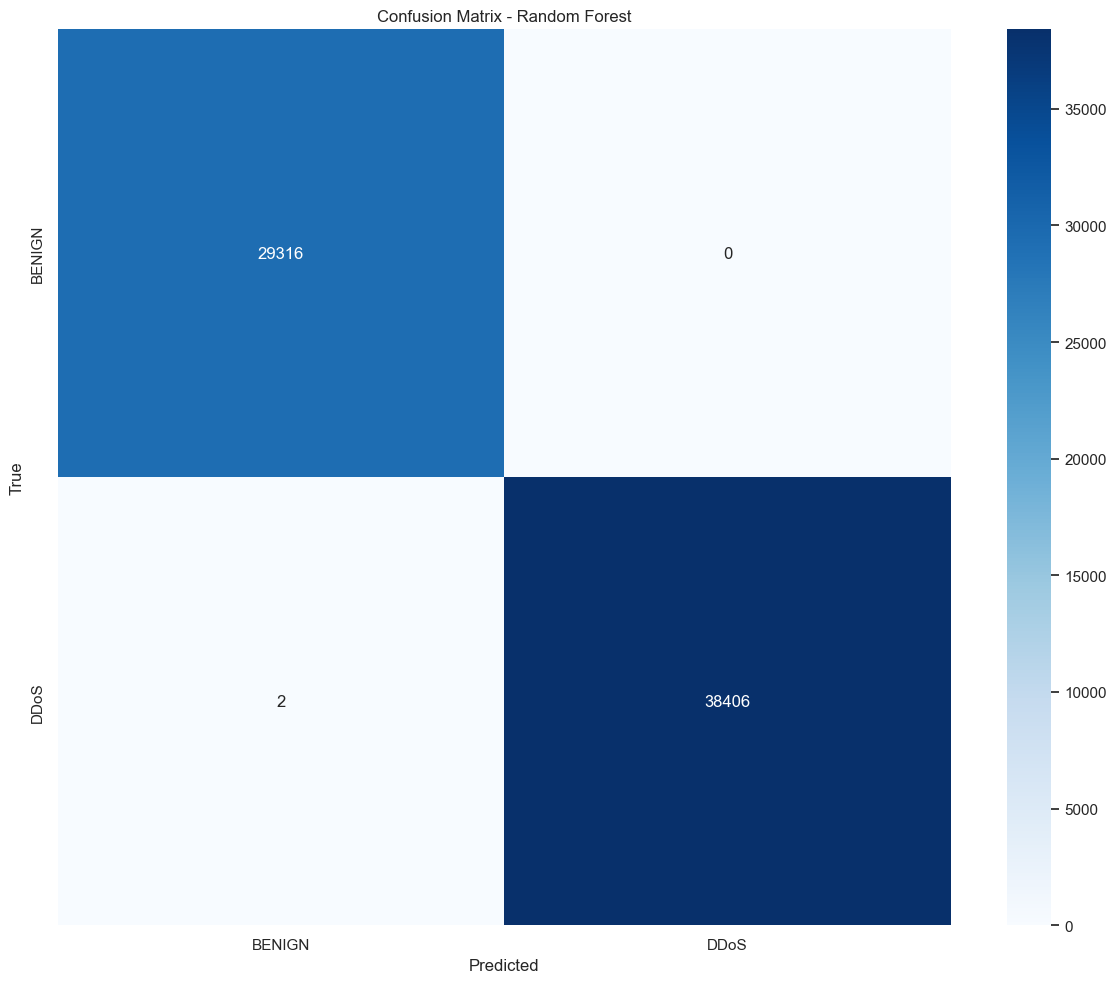

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, LabelBinarizer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, roc_curve,
                             roc_auc_score, precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.multiclass import OneVsRestClassifier

sns.set(style='whitegrid')

# Step 1: Load Data
df = pd.read_csv(r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\CICIDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
df.columns = df.columns.str.strip()

# Confirm actual label column name here
label_col_candidates = ['Label', 'label', 'Flow Label', 'FlowLabel']
label_col = None
for col in label_col_candidates:
    if col in df.columns:
        label_col = col
        print(f"Using label column: {label_col}")
        break
if label_col is None:
    raise KeyError("Label column not found.")

# Step 2: Encode multi-class labels
y = df[label_col]

# Optional: explore label distribution
plt.figure(figsize=(12,6))
sns.countplot(y=y, palette='tab20')
plt.title('CICIDS2017: Multi-class Label Distribution')
plt.show()

X = df.drop(columns=[label_col])

# Detect categorical and numeric features (adjust if needed)
cat_feats = X.select_dtypes(include='object').columns.tolist()
num_feats = X.select_dtypes(include=[np.number]).columns.tolist()

# Visualize example numeric features
plt.figure(figsize=(15,4))
for i, col in enumerate(num_feats[:3]):
    plt.subplot(1,3,i+1)
    sns.histplot(X[col], bins=50, kde=True)
    plt.title(f"{col} Distribution")
plt.tight_layout()
plt.show()

# Clean numerics
X[num_feats] = X[num_feats].replace([np.inf, -np.inf], np.nan).fillna(0)

# Step 3: Preprocessing pipeline (scale numeric, encode categorical if any)
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats)
])
X_processed = preprocessor.fit_transform(X)

# Encode labels as integers
label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)

# Step 4: Train/test split stratified
X_train, X_test, y_train, y_test, y_train_enc, y_test_enc = train_test_split(
    X_processed, y, y_enc, test_size=0.3, random_state=42, stratify=y_enc)

# Binarize train and test labels separately for ROC AUC
lb = LabelBinarizer()
y_train_bin = lb.fit_transform(y_train_enc)
y_test_bin = lb.transform(y_test_enc)

# Step 5: Models setup
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, solver='saga'),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']

results = []
plt.figure(figsize=(10,8))

print("=== CICIDS2017 Multi-class Classification Results ===")
for name, model in models.items():
    print(f"\nTraining {name}...")
    start_time = time.time()

    ovr_model = OneVsRestClassifier(model)
    ovr_model.fit(X_train, y_train_enc)
    train_time = time.time() - start_time

    y_train_pred = ovr_model.predict(X_train)
    y_test_pred = ovr_model.predict(X_test)

    train_acc = accuracy_score(y_train_enc, y_train_pred)
    test_acc = accuracy_score(y_test_enc, y_test_pred)

    precision = precision_score(y_test_enc, y_test_pred, average='macro', zero_division=0)
    recall = recall_score(y_test_enc, y_test_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test_enc, y_test_pred, average='macro', zero_division=0)

    # Specificity calculation averaged per class
    cm = confusion_matrix(y_test_enc, y_test_pred)
    specificities = []
    for i in range(len(cm)):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        spec = tn / (tn + fp) if (tn + fp) != 0 else 0
        specificities.append(spec)
    macro_specificity = np.mean(specificities)

    try:
        y_score = ovr_model.predict_proba(X_test)
    except AttributeError:
        dec = ovr_model.decision_function(X_test)
        y_score = (dec - dec.min(axis=0)) / (dec.max(axis=0) - dec.min(axis=0) + 1e-10)

    # Fix for binary vs multiclass ROC AUC
    if y_test_bin.shape[1] == 1:  # binary classification case
        auc_macro = roc_auc_score(y_test_bin.ravel(), y_score[:, 1])
    else:
        auc_macro = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')

    # ROC curve for first class for visualization
    fpr, tpr, _ = roc_curve(y_test_bin[:, 0], y_score[:, 0])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_macro:.3f})', color=colors.pop(0))

    print(classification_report(y_test_enc, y_test_pred, target_names=label_encoder.classes_, digits=4))

    results.append({
        'Model': name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Specificity': macro_specificity,
        'AUC': auc_macro,
        'Time (s)': train_time
    })

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve (One-vs-Rest) - CICIDS2017 Multi-class')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

# Step 6: Accuracy and F1 bar plot
summary_df = pd.DataFrame(results)
plt.figure(figsize=(12, 5))
x = np.arange(len(summary_df))
plt.bar(x - 0.2, summary_df['Test Acc'], width=0.4, label='Test Accuracy', color='royalblue')
plt.bar(x + 0.2, summary_df['F1'], width=0.4, label='Macro F1-score', color='orange')
plt.xticks(x, summary_df['Model'], rotation=45)
plt.ylabel('Score')
plt.title('Test Accuracy & Macro F1-score Comparison')
plt.legend()
plt.tight_layout()
plt.show()

# Step 7: Confusion matrix for best model by test accuracy
best_index = summary_df['Test Acc'].idxmax()
best_model_name = summary_df.loc[best_index, 'Model']
best_model = OneVsRestClassifier(models[best_model_name])
best_model.fit(X_train, y_train_enc)
best_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test_enc, best_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()


Using label column: Label


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26980\915620833.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['BinaryLabel'], palette=["#2ecc71", "#e74c3c"])


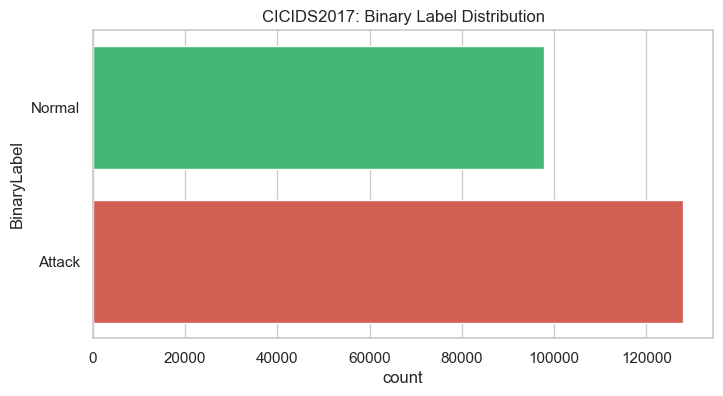

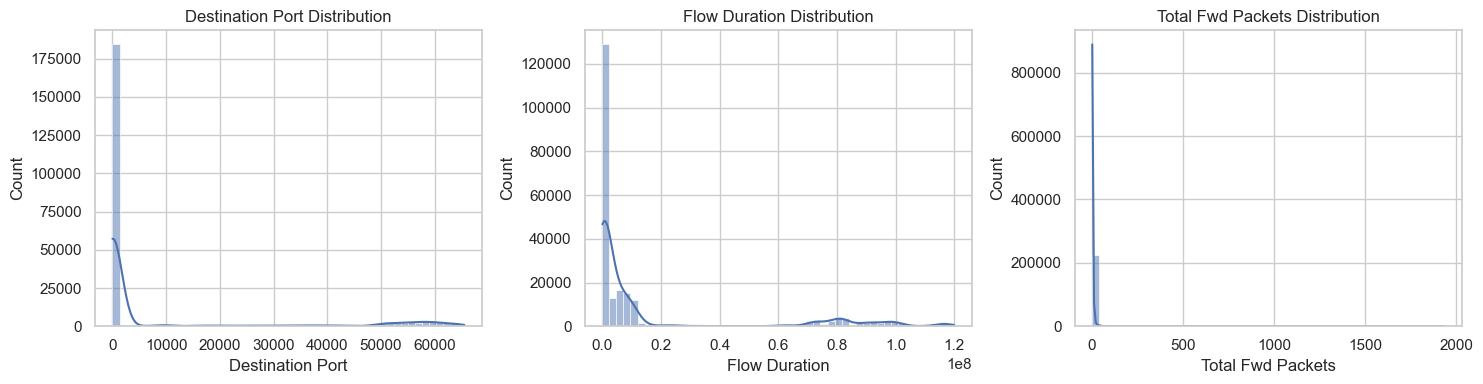

=== CICIDS2017 Binary Classification Results ===

Training Logistic Regression...
              precision    recall  f1-score   support

      Attack     0.9810    0.9996    0.9903     38408
      Normal     0.9995    0.9747    0.9869     29316

    accuracy                         0.9888     67724
   macro avg     0.9903    0.9872    0.9886     67724
weighted avg     0.9890    0.9888    0.9888     67724

Specificity: 0.9996, Training time: 14.11s, AUC: 0.9997

Training Decision Tree...
              precision    recall  f1-score   support

      Attack     0.9998    0.9998    0.9998     38408
      Normal     0.9997    0.9997    0.9997     29316

    accuracy                         0.9997     67724
   macro avg     0.9997    0.9997    0.9997     67724
weighted avg     0.9997    0.9997    0.9997     67724

Specificity: 0.9998, Training time: 3.04s, AUC: 0.9997

Training Random Forest...
              precision    recall  f1-score   support

      Attack     0.9999    0.9998    0.9999 

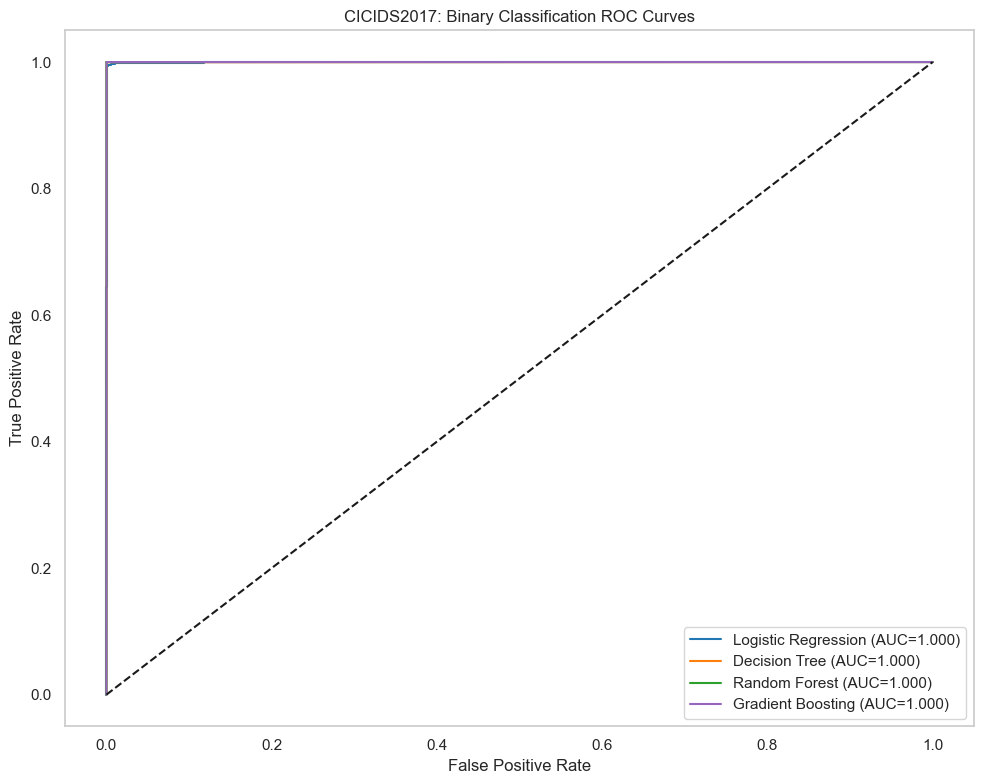


Summary Table:
                  Model  Train Acc  Test Acc  Precision    Recall        F1  \
0  Logistic Regression   0.988793  0.988837   0.999510  0.974690  0.986944   
1        Decision Tree   1.000000  0.999749   0.999693  0.999727  0.999710   
2        Random Forest   1.000000  0.999838   0.999693  0.999932  0.999812   
3    Gradient Boosting   0.999842  0.999734   0.999625  0.999761  0.999693   

   Specificity       AUC       Time(s)  
0     0.999635  0.999677     14.107642  
1     0.999766  0.999746      3.041701  
2     0.999766  1.000000     54.789401  
3     0.999714  0.999994  44429.219730  


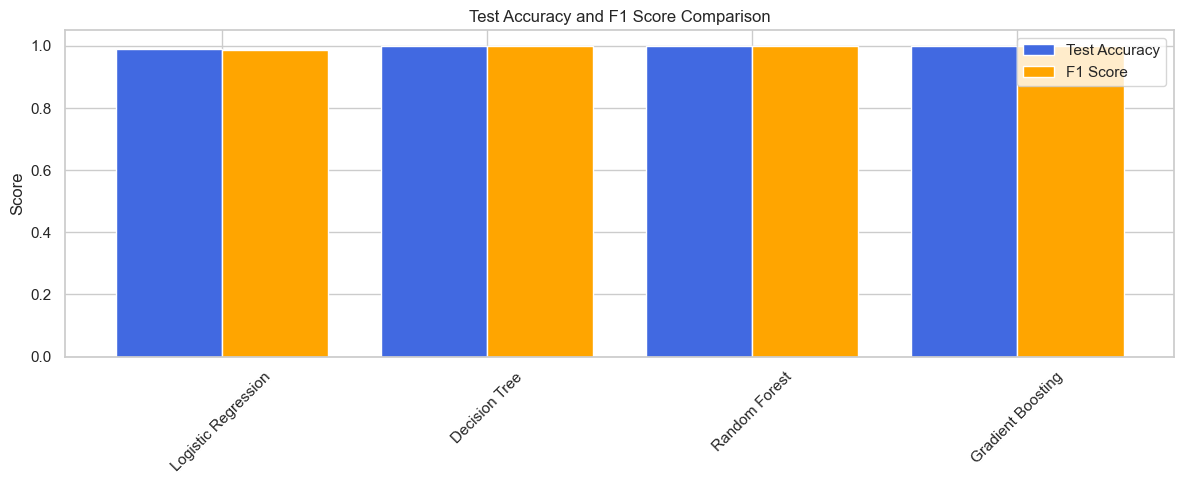

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, roc_curve,
                             auc, precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


sns.set(style='whitegrid')

# Step 1: Load Data
df = pd.read_csv(r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\CICIDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
df.columns = df.columns.str.strip()

# Detect label column
label_col_candidates = ['Label', 'label', 'Flow Label', 'FlowLabel']
label_col = None
for col in label_col_candidates:
    if col in df.columns:
        label_col = col
        print(f"Using label column: {label_col}")
        break
if label_col is None:
    raise KeyError("Label column not found.")

# Step 2: Map to binary labels
df['BinaryLabel'] = df[label_col].apply(lambda x: 'Normal' if str(x).upper() == 'BENIGN' else 'Attack')

# Visualize binary label distribution
plt.figure(figsize=(8,4))
sns.countplot(y=df['BinaryLabel'], palette=["#2ecc71", "#e74c3c"])
plt.title('CICIDS2017: Binary Label Distribution')
plt.show()

X = df.drop(columns=[label_col, 'BinaryLabel'])
y = df['BinaryLabel']

cat_feats = X.select_dtypes(include='object').columns.tolist()
num_feats = X.select_dtypes(include=[np.number]).columns.tolist()

# Visualize numeric distributions for first 3 numeric features
plt.figure(figsize=(15,4))
for i, col in enumerate(num_feats[:3]):
    plt.subplot(1,3,i+1)
    sns.histplot(X[col], bins=50, kde=True)
    plt.title(f"{col} Distribution")
plt.tight_layout()
plt.show()

# Clean numerics
X[num_feats] = X[num_feats].replace([np.inf, -np.inf], np.nan).fillna(0)

# Step 3: Preprocessing
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats)
])
X_processed = preprocessor.fit_transform(X)

# Encode binary labels
label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)  # Normal=0, Attack=1

# Step 4: Train-test split stratified
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_enc, test_size=0.3, random_state=42, stratify=y_enc)

# Step 5: Models setup
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, solver='saga'),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']
summary = []
plt.figure(figsize=(10,8))

print("=== CICIDS2017 Binary Classification Results ===")
for name, model in models.items():
    print(f"\nTraining {name}...")
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, zero_division=0)
    recall = recall_score(y_test, y_test_pred, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, zero_division=0)

    # Calculate specificity
    cm = confusion_matrix(y_test, y_test_pred)
    TN, FP, FN, TP = cm.ravel()
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    # ROC, AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})", color=colors.pop(0))

    print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_, digits=4))
    print(f"Specificity: {specificity:.4f}, Training time: {train_time:.2f}s, AUC: {roc_auc:.4f}")

    summary.append({
        'Model': name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Specificity': specificity,
        'AUC': roc_auc,
        'Time(s)': train_time
    })

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('CICIDS2017: Binary Classification ROC Curves')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Summary table
summary_df = pd.DataFrame(summary)
print("\nSummary Table:\n", summary_df)

# Accuracy and F1 bar plot
plt.figure(figsize=(12, 5))
x = np.arange(len(summary_df))
plt.bar(x - 0.2, summary_df['Test Acc'], width=0.4, label='Test Accuracy', color='royalblue')
plt.bar(x + 0.2, summary_df['F1'], width=0.4, label='F1 Score', color='orange')
plt.xticks(x, summary_df['Model'], rotation=45)
plt.ylabel('Score')
plt.title('Test Accuracy and F1 Score Comparison')
plt.legend()
plt.tight_layout()
plt.show()


Using label column: Label


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26980\2215625030.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['BinaryLabel'], palette=["#2ecc71", "#e74c3c"])


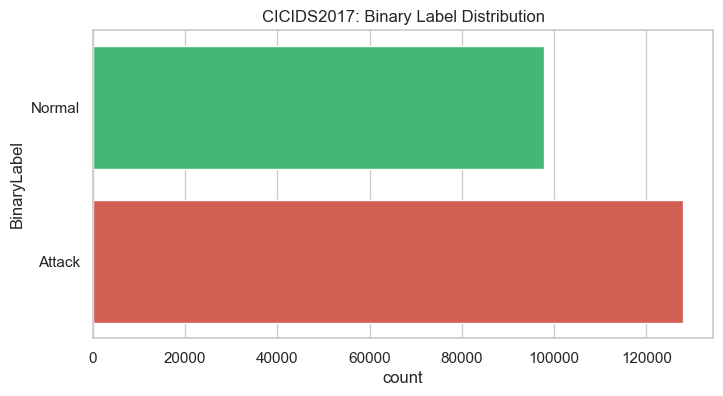

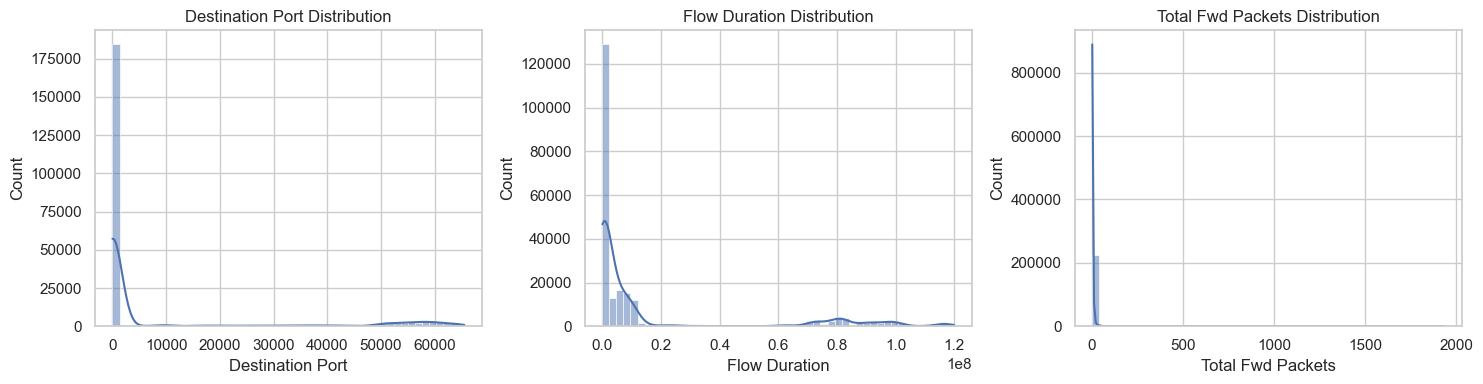

=== CICIDS2017 Binary Classification Results ===

Training Logistic Regression...
              precision    recall  f1-score   support

      Attack     0.9810    0.9996    0.9903     38408
      Normal     0.9995    0.9747    0.9869     29316

    accuracy                         0.9888     67724
   macro avg     0.9903    0.9872    0.9886     67724
weighted avg     0.9890    0.9888    0.9888     67724

Specificity: 0.9996, Training time: 10.20s, AUC: 0.9997

Training Decision Tree...
              precision    recall  f1-score   support

      Attack     0.9997    0.9998    0.9998     38408
      Normal     0.9997    0.9997    0.9997     29316

    accuracy                         0.9997     67724
   macro avg     0.9997    0.9997    0.9997     67724
weighted avg     0.9997    0.9997    0.9997     67724

Specificity: 0.9998, Training time: 3.20s, AUC: 0.9997

Training Random Forest...
              precision    recall  f1-score   support

      Attack     1.0000    0.9998    0.9999 

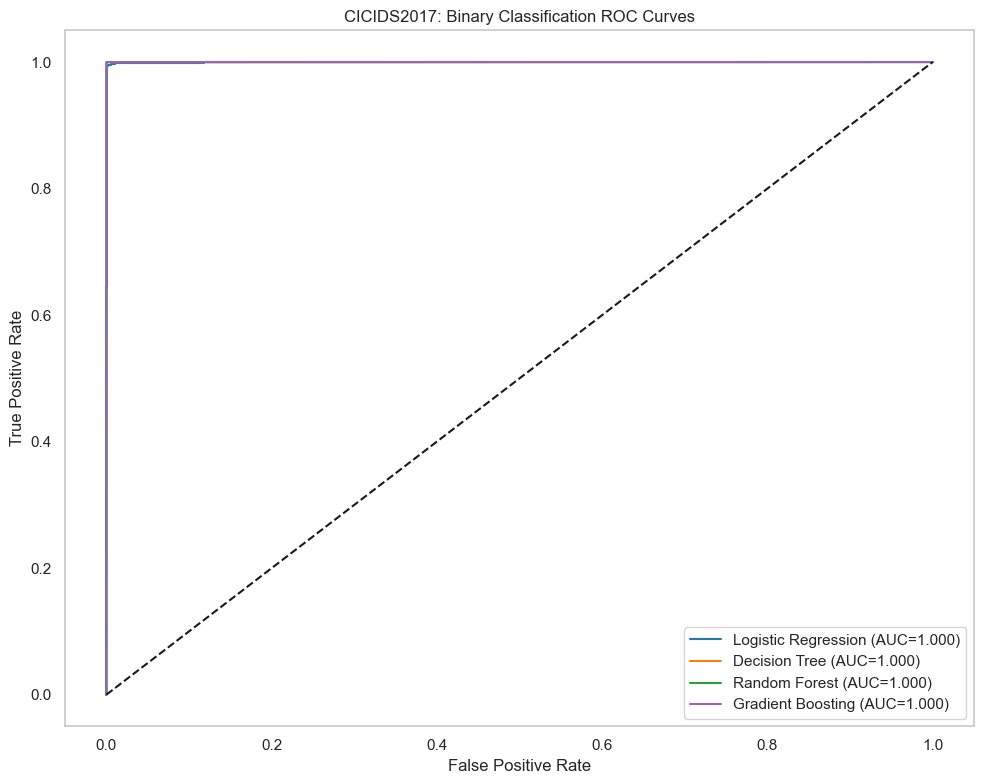


Summary Table:
                  Model  Train Acc  Test Acc  Precision    Recall        F1  \
0  Logistic Regression   0.988793  0.988837   0.999510  0.974690  0.986944   
1        Decision Tree   1.000000  0.999719   0.999693  0.999659  0.999676   
2        Random Forest   1.000000  0.999882   0.999727  1.000000  0.999864   
3    Gradient Boosting   0.999842  0.999734   0.999625  0.999761  0.999693   

   Specificity       AUC     Time(s)  
0     0.999635  0.999677   10.195880  
1     0.999766  0.999712    3.202761  
2     0.999792  1.000000   32.245206  
3     0.999714  0.999994  192.886969  


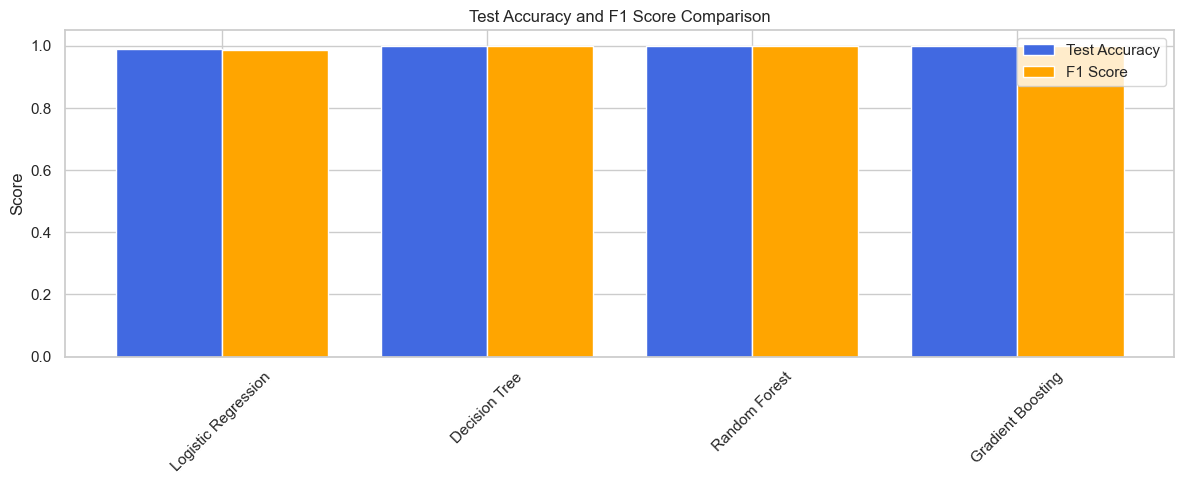

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, roc_curve,
                             auc, precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


sns.set(style='whitegrid')

# Step 1: Load Data
df = pd.read_csv(r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\CICIDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
df.columns = df.columns.str.strip()

# Detect label column
label_col_candidates = ['Label', 'label', 'Flow Label', 'FlowLabel']
label_col = None
for col in label_col_candidates:
    if col in df.columns:
        label_col = col
        print(f"Using label column: {label_col}")
        break
if label_col is None:
    raise KeyError("Label column not found.")

# Step 2: Map to binary labels
df['BinaryLabel'] = df[label_col].apply(lambda x: 'Normal' if str(x).upper() == 'BENIGN' else 'Attack')

# Visualize binary label distribution
plt.figure(figsize=(8,4))
sns.countplot(y=df['BinaryLabel'], palette=["#2ecc71", "#e74c3c"])
plt.title('CICIDS2017: Binary Label Distribution')
plt.show()

X = df.drop(columns=[label_col, 'BinaryLabel'])
y = df['BinaryLabel']

cat_feats = X.select_dtypes(include='object').columns.tolist()
num_feats = X.select_dtypes(include=[np.number]).columns.tolist()

# Visualize numeric distributions for the first 3 numeric features
plt.figure(figsize=(15,4))
for i, col in enumerate(num_feats[:3]):
    plt.subplot(1,3,i+1)
    sns.histplot(X[col], bins=50, kde=True)
    plt.title(f"{col} Distribution")
plt.tight_layout()
plt.show()

# Clean numerics
X[num_feats] = X[num_feats].replace([np.inf, -np.inf], np.nan).fillna(0)

# Step 3: Preprocessing
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats)
])
X_processed = preprocessor.fit_transform(X)

# Encode binary labels
label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)  # Normal=0, Attack=1

# Step 4: Train-test split stratified
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_enc, test_size=0.3, random_state=42, stratify=y_enc)

# Step 5: Models setup
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, solver='saga'),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']
summary = []
plt.figure(figsize=(10,8))

print("=== CICIDS2017 Binary Classification Results ===")
for name, model in models.items():
    print(f"\nTraining {name}...")
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, zero_division=0)
    recall = recall_score(y_test, y_test_pred, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, zero_division=0)

    # Calculate specificity
    cm = confusion_matrix(y_test, y_test_pred)
    TN, FP, FN, TP = cm.ravel()
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    # ROC, AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})", color=colors.pop(0))

    print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_, digits=4))
    print(f"Specificity: {specificity:.4f}, Training time: {train_time:.2f}s, AUC: {roc_auc:.4f}")

    summary.append({
        'Model': name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Specificity': specificity,
        'AUC': roc_auc,
        'Time(s)': train_time
    })

# Draw diagonal line for random chance
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('CICIDS2017: Binary Classification ROC Curves')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Summary table
summary_df = pd.DataFrame(summary)
print("\nSummary Table:\n", summary_df)

# Accuracy and F1 bar plot
plt.figure(figsize=(12, 5))
x = np.arange(len(summary_df))
plt.bar(x - 0.2, summary_df['Test Acc'], width=0.4, label='Test Accuracy', color='royalblue')
plt.bar(x + 0.2, summary_df['F1'], width=0.4, label='F1 Score', color='orange')
plt.xticks(x, summary_df['Model'], rotation=45)
plt.ylabel('Score')
plt.title('Test Accuracy and F1 Score Comparison')
plt.legend()
plt.tight_layout()
plt.show()


Using label column: Label


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26980\758962479.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['BinaryLabel'], palette=["#2ecc71", "#e74c3c"])


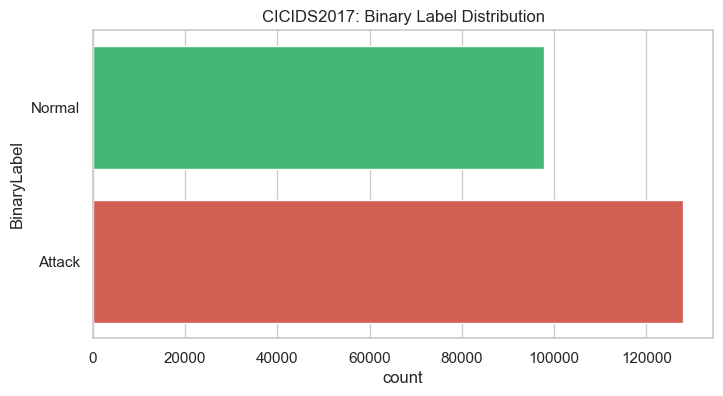

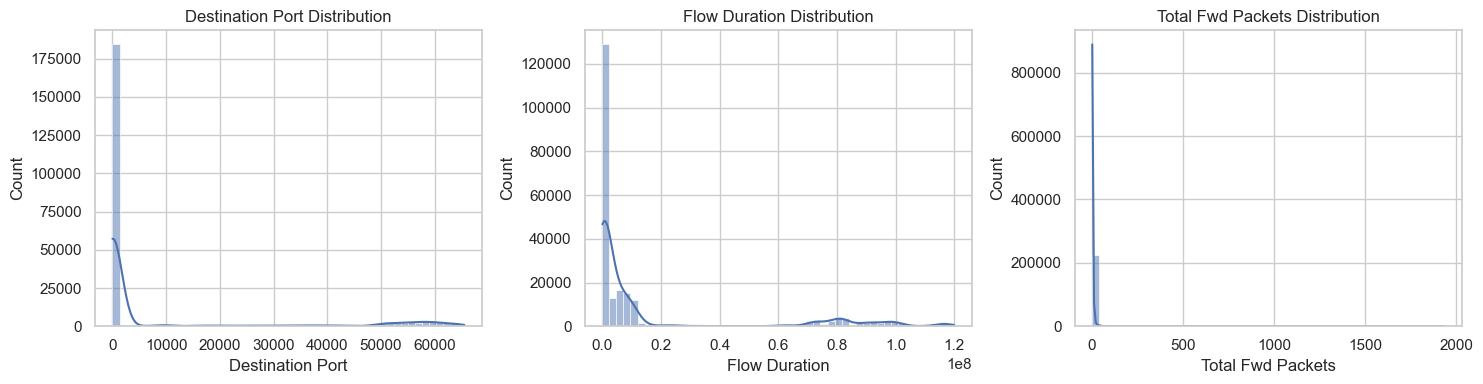

=== CICIDS2017 Binary Classification Results ===

Training Logistic Regression...
              precision    recall  f1-score   support

      Attack     0.9810    0.9996    0.9903     38408
      Normal     0.9995    0.9747    0.9869     29316

    accuracy                         0.9888     67724
   macro avg     0.9903    0.9872    0.9886     67724
weighted avg     0.9890    0.9888    0.9888     67724

Specificity: 0.9996, Training time: 10.52s, AUC: 0.9997

Training Decision Tree...
              precision    recall  f1-score   support

      Attack     0.9998    0.9998    0.9998     38408
      Normal     0.9997    0.9998    0.9997     29316

    accuracy                         0.9998     67724
   macro avg     0.9998    0.9998    0.9998     67724
weighted avg     0.9998    0.9998    0.9998     67724

Specificity: 0.9998, Training time: 1.58s, AUC: 0.9998

Training Random Forest...
              precision    recall  f1-score   support

      Attack     1.0000    0.9998    0.9999 

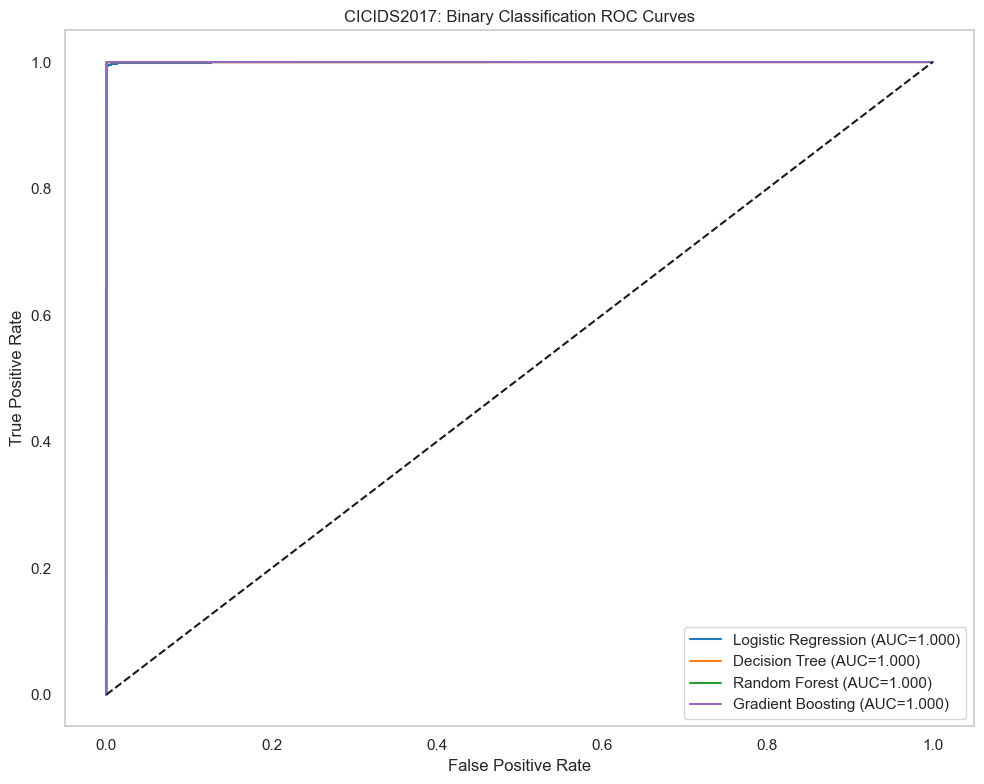


Summary Table:
                  Model  Train Acc  Test Acc  Precision    Recall        F1  \
0  Logistic Regression   0.988824  0.988837   0.999510  0.974690  0.986944   
1        Decision Tree   1.000000  0.999779   0.999727  0.999761  0.999744   
2        Random Forest   1.000000  0.999882   0.999761  0.999966  0.999864   
3    Gradient Boosting   0.999842  0.999734   0.999625  0.999761  0.999693   

   Specificity       AUC     Time(s)  
0     0.999635  0.999668   10.522829  
1     0.999792  0.999776    1.584930  
2     0.999818  1.000000   21.846236  
3     0.999714  0.999994  135.908618  


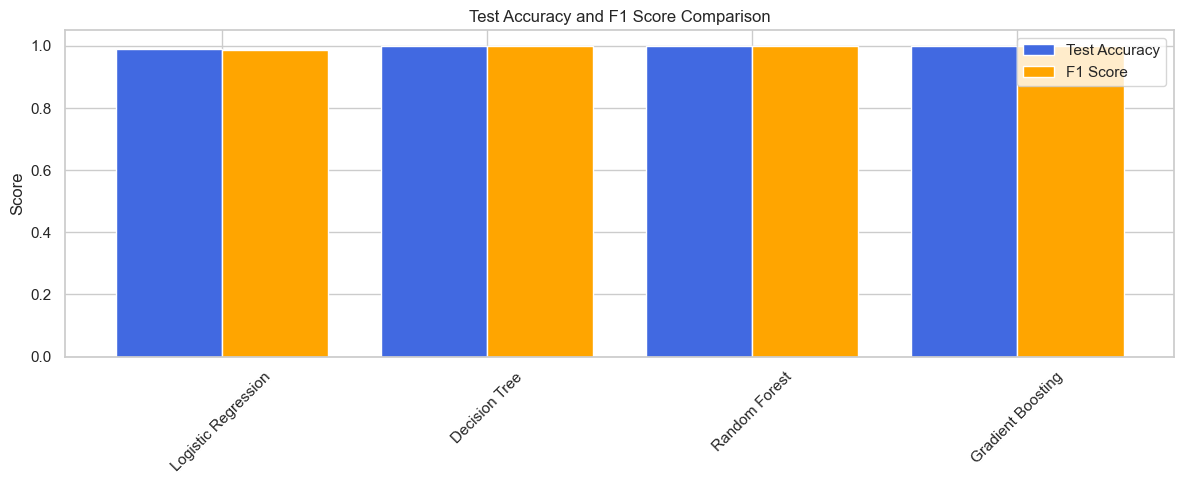

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, roc_curve,
                             auc, precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# For reproducibility
RANDOM_SEED = 42

sns.set(style='whitegrid')

# Step 1: Load Data
df = pd.read_csv(r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\CICIDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
df.columns = df.columns.str.strip()

# Detect label column
label_col_candidates = ['Label', 'label', 'Flow Label', 'FlowLabel']
label_col = None
for col in label_col_candidates:
    if col in df.columns:
        label_col = col
        print(f"Using label column: {label_col}")
        break
if label_col is None:
    raise KeyError("Label column not found.")

# Step 2: Map to binary labels
df['BinaryLabel'] = df[label_col].apply(lambda x: 'Normal' if str(x).upper() == 'BENIGN' else 'Attack')

# Visualize binary label distribution
plt.figure(figsize=(8,4))
sns.countplot(y=df['BinaryLabel'], palette=["#2ecc71", "#e74c3c"])
plt.title('CICIDS2017: Binary Label Distribution')
plt.show()

X = df.drop(columns=[label_col, 'BinaryLabel'])
y = df['BinaryLabel']

cat_feats = X.select_dtypes(include='object').columns.tolist()
num_feats = X.select_dtypes(include=[np.number]).columns.tolist()

# Visualize numeric distributions for first 3 numeric features
plt.figure(figsize=(15,4))
for i, col in enumerate(num_feats[:3]):
    plt.subplot(1,3,i+1)
    sns.histplot(X[col], bins=50, kde=True)
    plt.title(f"{col} Distribution")
plt.tight_layout()
plt.show()

# Clean numerics
X[num_feats] = X[num_feats].replace([np.inf, -np.inf], np.nan).fillna(0)

# === CRITICAL: Split data before fitting preprocessor to avoid leakage ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_SEED, stratify=y
)

# Step 3: Preprocessing only fit on TRAINING data!
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_feats)
])
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Encode binary labels AFTER splitting (no leakage)
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

# Step 4: Models setup
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, solver='saga', random_state=RANDOM_SEED),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_SEED),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_SEED)
}

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']
summary = []
plt.figure(figsize=(10,8))

print("=== CICIDS2017 Binary Classification Results ===")
for name, model in models.items():
    print(f"\nTraining {name}...")
    start_time = time.time()
    model.fit(X_train_processed, y_train_enc)
    train_time = time.time() - start_time

    y_train_pred = model.predict(X_train_processed)
    y_test_pred = model.predict(X_test_processed)

    train_acc = accuracy_score(y_train_enc, y_train_pred)
    test_acc = accuracy_score(y_test_enc, y_test_pred)
    precision = precision_score(y_test_enc, y_test_pred, zero_division=0)
    recall = recall_score(y_test_enc, y_test_pred, zero_division=0)
    f1 = f1_score(y_test_enc, y_test_pred, zero_division=0)

    # Calculate specificity
    cm = confusion_matrix(y_test_enc, y_test_pred)
    if cm.shape == (2,2):
        TN, FP, FN, TP = cm.ravel()
        specificity = TN / (TN + FP) if (TN + FP) != 0 else 0
    else:
        specificity = 0  # Fallback

    # ROC, AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_processed)[:, 1]
    else:
        y_score = model.decision_function(X_test_processed)
    fpr, tpr, _ = roc_curve(y_test_enc, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})", color=colors.pop(0))

    print(classification_report(y_test_enc, y_test_pred, target_names=label_encoder.classes_, digits=4))
    print(f"Specificity: {specificity:.4f}, Training time: {train_time:.2f}s, AUC: {roc_auc:.4f}")

    summary.append({
        'Model': name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Specificity': specificity,
        'AUC': roc_auc,
        'Time(s)': train_time
    })

# Draw diagonal line for random chance
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('CICIDS2017: Binary Classification ROC Curves')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig('roc_curve_plot.png', dpi=300)
plt.show()

# Summary table
summary_df = pd.DataFrame(summary)
print("\nSummary Table:\n", summary_df)

# Accuracy and F1 bar plot
plt.figure(figsize=(12, 5))
x = np.arange(len(summary_df))
plt.bar(x - 0.2, summary_df['Test Acc'], width=0.4, label='Test Accuracy', color='royalblue')
plt.bar(x + 0.2, summary_df['F1'], width=0.4, label='F1 Score', color='orange')
plt.xticks(x, summary_df['Model'], rotation=45)
plt.ylabel('Score')
plt.title('Test Accuracy and F1 Score Comparison')
plt.legend()
plt.tight_layout()
plt.show()


Using label column: Label


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26980\821208469.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['BinaryLabel'], palette=["#2ecc71", "#e74c3c"])


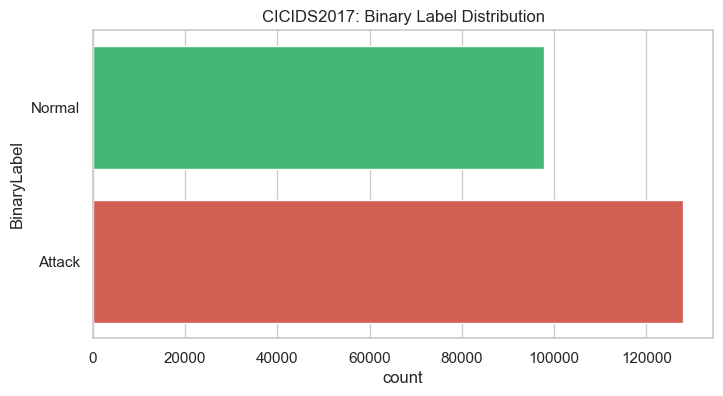

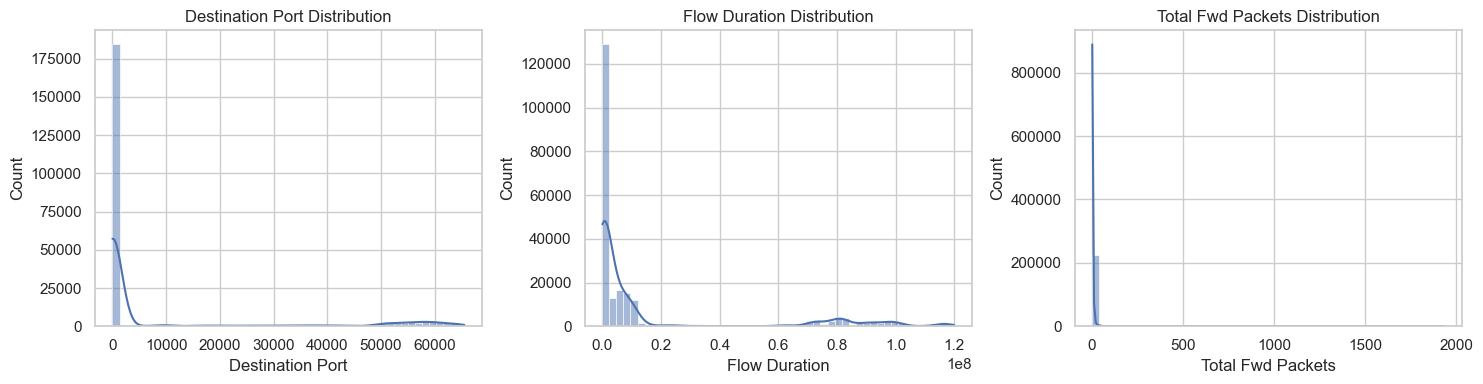

=== CICIDS2017 Binary Classification Results ===

Training Logistic Regression...
              precision    recall  f1-score   support

      Attack     0.9810    0.9996    0.9903     38408
      Normal     0.9995    0.9747    0.9869     29316

    accuracy                         0.9888     67724
   macro avg     0.9903    0.9872    0.9886     67724
weighted avg     0.9890    0.9888    0.9888     67724

Specificity: 0.9996, Training time: 9.91s, AUC: 1.0000

Training Decision Tree...
              precision    recall  f1-score   support

      Attack     0.9999    0.9997    0.9998     38408
      Normal     0.9997    0.9999    0.9998     29316

    accuracy                         0.9998     67724
   macro avg     0.9998    0.9998    0.9998     67724
weighted avg     0.9998    0.9998    0.9998     67724

Specificity: 0.9997, Training time: 2.48s, AUC: 1.0000

Training Random Forest...
              precision    recall  f1-score   support

      Attack     1.0000    0.9998    0.9999  

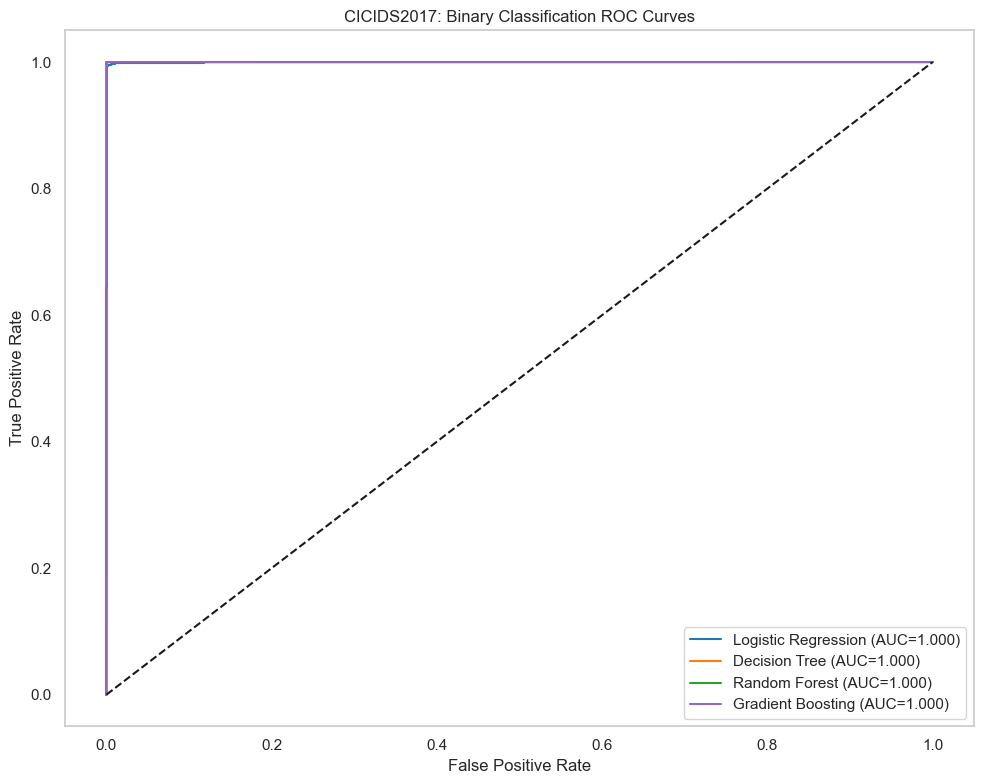


Summary Table:
                  Model  Train Acc  Test Acc  Precision    Recall        F1  \
0  Logistic Regression   0.988793  0.988837   0.999510  0.974690  0.986944   
1        Decision Tree   1.000000  0.999808   0.999659  0.999898  0.999778   
2        Random Forest   1.000000  0.999867   0.999727  0.999966  0.999847   
3    Gradient Boosting   0.999842  0.999734   0.999625  0.999761  0.999693   

   Specificity       AUC     Time(s)  
0     0.999635  0.999994    9.909980  
1     0.999740  0.999994    2.482891  
2     0.999792  0.999994   31.010820  
3     0.999714  0.999994  179.789922  


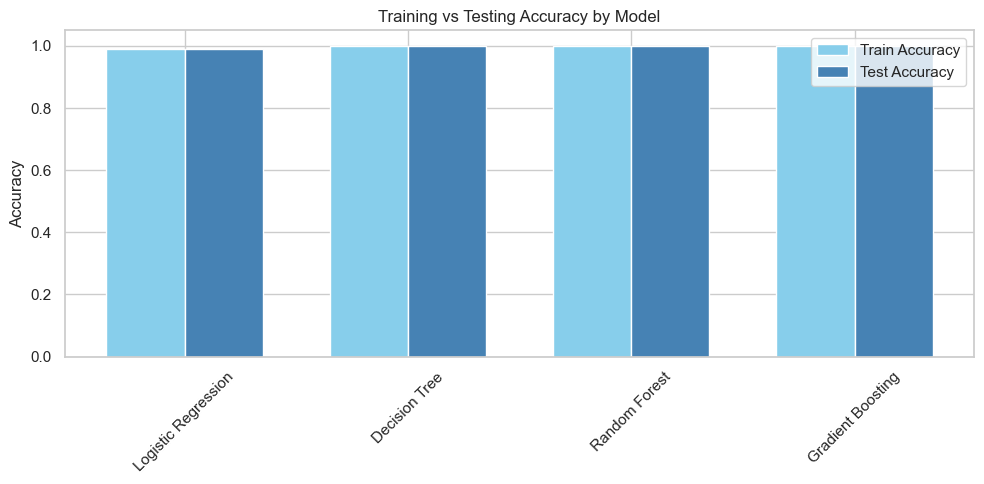

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, roc_curve,
                             auc, precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

sns.set(style='whitegrid')

# Step 1: Load Data
df = pd.read_csv(r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\CICIDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
df.columns = df.columns.str.strip()

# Detect label column
label_col_candidates = ['Label', 'label', 'Flow Label', 'FlowLabel']
label_col = None
for col in label_col_candidates:
    if col in df.columns:
        label_col = col
        print(f"Using label column: {label_col}")
        break
if label_col is None:
    raise KeyError("Label column not found.")

# Step 2: Map to binary labels
df['BinaryLabel'] = df[label_col].apply(lambda x: 'Normal' if str(x).upper() == 'BENIGN' else 'Attack')

# Visualize binary label distribution
plt.figure(figsize=(8,4))
sns.countplot(y=df['BinaryLabel'], palette=["#2ecc71", "#e74c3c"])
plt.title('CICIDS2017: Binary Label Distribution')
plt.show()

X = df.drop(columns=[label_col, 'BinaryLabel'])
y = df['BinaryLabel']

cat_feats = X.select_dtypes(include='object').columns.tolist()
num_feats = X.select_dtypes(include=[np.number]).columns.tolist()

# Visualize numeric distributions for first 3 numeric features
plt.figure(figsize=(15,4))
for i, col in enumerate(num_feats[:3]):
    plt.subplot(1,3,i+1)
    sns.histplot(X[col], bins=50, kde=True)
    plt.title(f"{col} Distribution")
plt.tight_layout()
plt.show()

# Clean numerics
X[num_feats] = X[num_feats].replace([np.inf, -np.inf], np.nan).fillna(0)

# Step 3: Preprocessing
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats)
])
X_processed = preprocessor.fit_transform(X)

# Encode binary labels
label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)  # Normal=0, Attack=1

# Step 4: Train-test split stratified
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_enc, test_size=0.3, random_state=42, stratify=y_enc)

# Step 5: Models setup
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, solver='saga'),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']

summary = []
train_acc_list = []
test_acc_list = []
plt.figure(figsize=(10,8))

print("=== CICIDS2017 Binary Classification Results ===")
for name, model in models.items():
    print(f"\nTraining {name}...")
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, zero_division=0)
    recall = recall_score(y_test, y_test_pred, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, zero_division=0)

    # Calculate specificity
    cm = confusion_matrix(y_test, y_test_pred)
    TN, FP, FN, TP = cm.ravel()
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    # ROC, AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})", color=colors.pop(0))

    print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_, digits=4))
    print(f"Specificity: {specificity:.4f}, Training time: {train_time:.2f}s, AUC: {roc_auc:.4f}")

    summary.append({
        'Model': name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Specificity': specificity,
        'AUC': roc_auc,
        'Time(s)': train_time
    })
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('CICIDS2017: Binary Classification ROC Curves')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Summary table
summary_df = pd.DataFrame(summary)
print("\nSummary Table:\n", summary_df)

# Accuracy bar plot (training and testing in one graph)
plt.figure(figsize=(10,5))
x = np.arange(len(models))
bar_width = 0.35
plt.bar(x - bar_width/2, train_acc_list, width=bar_width, label='Train Accuracy', color='skyblue')
plt.bar(x + bar_width/2, test_acc_list, width=bar_width, label='Test Accuracy', color='steelblue')
plt.xticks(x, summary_df['Model'], rotation=45)
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy by Model')
plt.legend()
plt.tight_layout()
plt.show()


Using label column: Label


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26980\4245172861.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=y, palette='tab20')


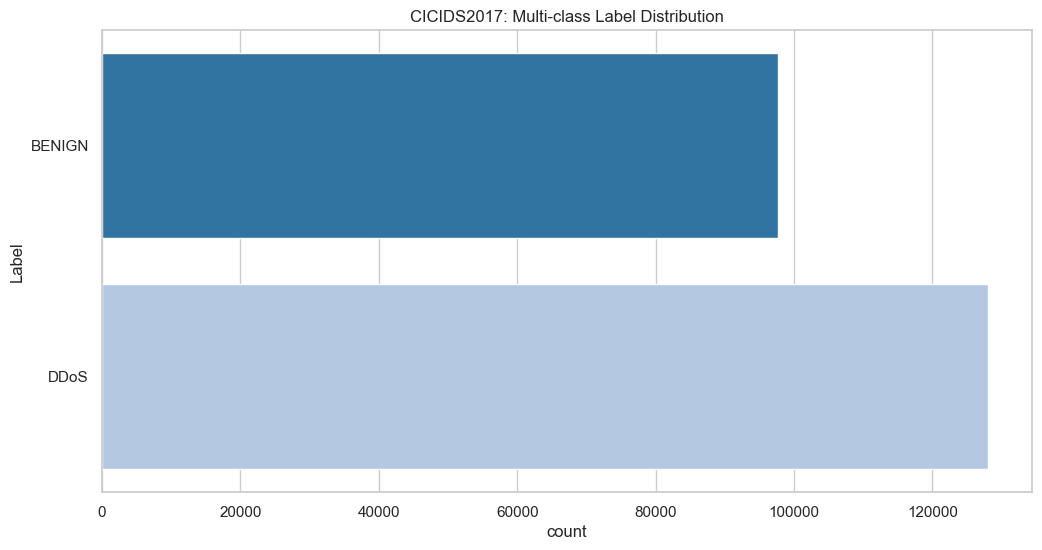

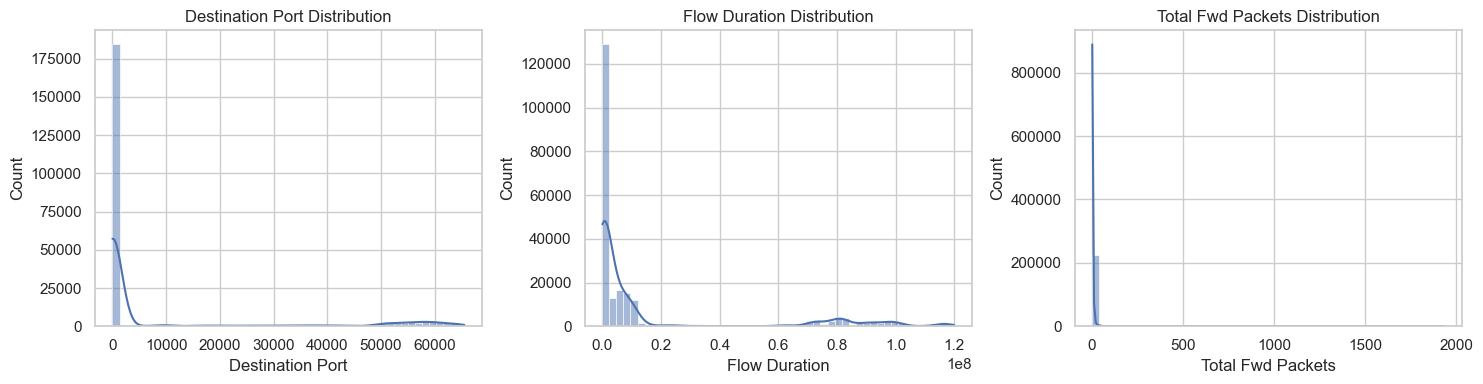

=== CICIDS2017 Multi-class Classification Results ===

Training Logistic Regression...
              precision    recall  f1-score   support

      BENIGN     0.9995    0.9749    0.9871     29316
        DDoS     0.9812    0.9996    0.9903     38408

    accuracy                         0.9889     67724
   macro avg     0.9904    0.9873    0.9887     67724
weighted avg     0.9891    0.9889    0.9889     67724


Training Decision Tree...
              precision    recall  f1-score   support

      BENIGN     0.9998    0.9999    0.9998     29316
        DDoS     0.9999    0.9998    0.9999     38408

    accuracy                         0.9999     67724
   macro avg     0.9998    0.9999    0.9998     67724
weighted avg     0.9999    0.9999    0.9999     67724


Training Random Forest...
              precision    recall  f1-score   support

      BENIGN     0.9999    1.0000    0.9999     29316
        DDoS     1.0000    0.9999    1.0000     38408

    accuracy                         1.00

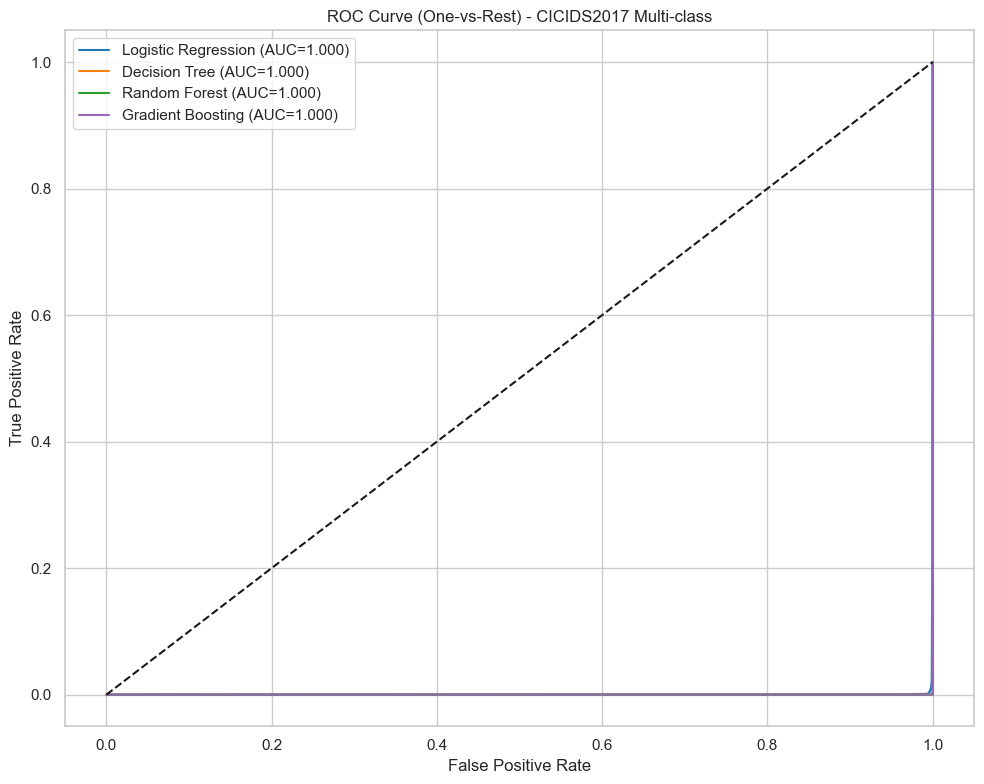

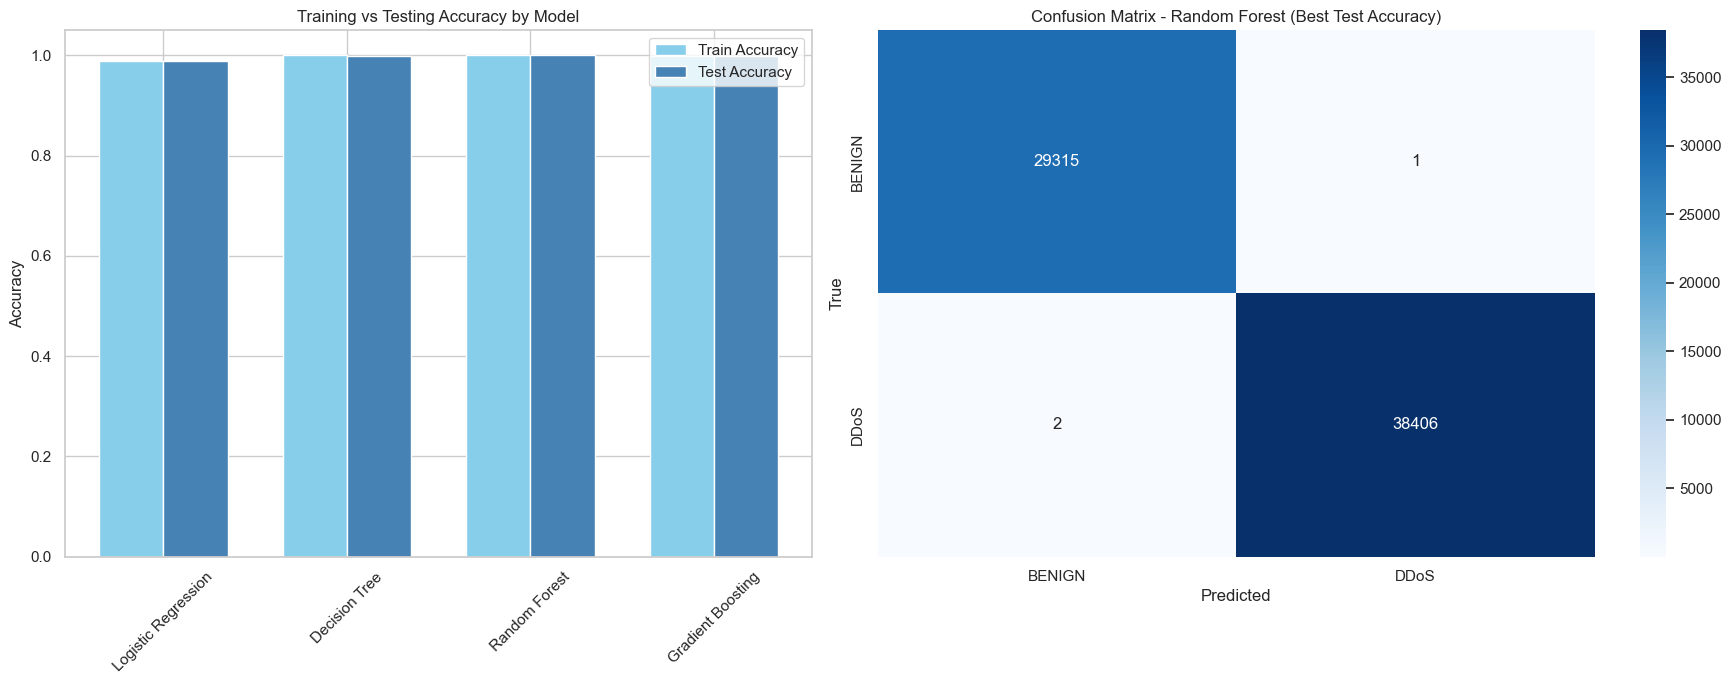

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, LabelBinarizer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, roc_curve,
                             roc_auc_score, precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.multiclass import OneVsRestClassifier

sns.set(style='whitegrid')

# Step 1: Load Data
df = pd.read_csv(r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\CICIDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
df.columns = df.columns.str.strip()

# Confirm actual label column name here
label_col_candidates = ['Label', 'label', 'Flow Label', 'FlowLabel']
label_col = None
for col in label_col_candidates:
    if col in df.columns:
        label_col = col
        print(f"Using label column: {label_col}")
        break
if label_col is None:
    raise KeyError("Label column not found.")

# Step 2: Encode multi-class labels
y = df[label_col]

# Optional: explore label distribution
plt.figure(figsize=(12,6))
sns.countplot(y=y, palette='tab20')
plt.title('CICIDS2017: Multi-class Label Distribution')
plt.show()

X = df.drop(columns=[label_col])

# Detect categorical and numeric features (adjust if needed)
cat_feats = X.select_dtypes(include='object').columns.tolist()
num_feats = X.select_dtypes(include=[np.number]).columns.tolist()

# Visualize example numeric features
plt.figure(figsize=(15,4))
for i, col in enumerate(num_feats[:3]):
    plt.subplot(1,3,i+1)
    sns.histplot(X[col], bins=50, kde=True)
    plt.title(f"{col} Distribution")
plt.tight_layout()
plt.show()

# Clean numerics
X[num_feats] = X[num_feats].replace([np.inf, -np.inf], np.nan).fillna(0)

# Step 3: Preprocessing pipeline (scale numeric, encode categorical if any)
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats)
])
X_processed = preprocessor.fit_transform(X)

# Encode labels as integers
label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)

# Step 4: Train/test split stratified
X_train, X_test, y_train, y_test, y_train_enc, y_test_enc = train_test_split(
    X_processed, y, y_enc, test_size=0.3, random_state=42, stratify=y_enc)

# Binarize train and test labels separately for ROC AUC
lb = LabelBinarizer()
y_train_bin = lb.fit_transform(y_train_enc)
y_test_bin = lb.transform(y_test_enc)

# Step 5: Models setup
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, solver='saga'),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']

results = []
train_acc_list = []
test_acc_list = []
plt.figure(figsize=(10,8))

print("=== CICIDS2017 Multi-class Classification Results ===")
for name, model in models.items():
    print(f"\nTraining {name}...")

    start_time = time.time()
    ovr_model = OneVsRestClassifier(model)
    ovr_model.fit(X_train, y_train_enc)
    train_time = time.time() - start_time

    y_train_pred = ovr_model.predict(X_train)
    y_test_pred = ovr_model.predict(X_test)

    train_acc = accuracy_score(y_train_enc, y_train_pred)
    test_acc = accuracy_score(y_test_enc, y_test_pred)

    precision = precision_score(y_test_enc, y_test_pred, average='macro', zero_division=0)
    recall = recall_score(y_test_enc, y_test_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test_enc, y_test_pred, average='macro', zero_division=0)

    # Specificity calculation averaged per class
    cm = confusion_matrix(y_test_enc, y_test_pred)
    specificities = []
    for i in range(len(cm)):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        spec = tn / (tn + fp) if (tn + fp) != 0 else 0
        specificities.append(spec)
    macro_specificity = np.mean(specificities)

    try:
        y_score = ovr_model.predict_proba(X_test)
    except AttributeError:
        dec = ovr_model.decision_function(X_test)
        y_score = (dec - dec.min(axis=0)) / (dec.max(axis=0) - dec.min(axis=0) + 1e-10)

    # Fix for binary vs multiclass ROC AUC
    if y_test_bin.shape[1] == 1:  # binary classification case
        auc_macro = roc_auc_score(y_test_bin.ravel(), y_score[:, 1])
    else:
        auc_macro = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')

    # ROC curve for first class for visualization
    fpr, tpr, _ = roc_curve(y_test_bin[:, 0], y_score[:, 0])

    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_macro:.3f})', color=colors.pop(0))

    print(classification_report(y_test_enc, y_test_pred, target_names=label_encoder.classes_, digits=4))

    results.append({
        'Model': name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Specificity': macro_specificity,
        'AUC': auc_macro,
        'Time (s)': train_time,
        'ConfusionMatrix': cm,
        'Predictions': y_test_pred
    })

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve (One-vs-Rest) - CICIDS2017 Multi-class')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(results)

# Combined plot: Training & Testing Accuracy + Confusion Matrix of best model
best_index = summary_df['Test Acc'].idxmax()
best_model_info = summary_df.iloc[best_index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [1, 1.2]})

# Bar plot of accuracies
x = np.arange(len(summary_df))
bar_width = 0.35
ax1.bar(x - bar_width/2, summary_df['Train Acc'], width=bar_width, label='Train Accuracy', color='skyblue')
ax1.bar(x + bar_width/2, summary_df['Test Acc'], width=bar_width, label='Test Accuracy', color='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels(summary_df['Model'], rotation=45)
ax1.set_ylabel('Accuracy')
ax1.set_title('Training vs Testing Accuracy by Model')
ax1.legend()
ax1.grid(True, axis='y')

# Confusion matrix heatmap
sns.heatmap(best_model_info['ConfusionMatrix'], annot=True, fmt='d', ax=ax2,
            cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')
ax2.set_title(f'Confusion Matrix - {best_model_info["Model"]} (Best Test Accuracy)')

plt.tight_layout()
plt.show()


Using label column: Label


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26980\4245172861.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=y, palette='tab20')


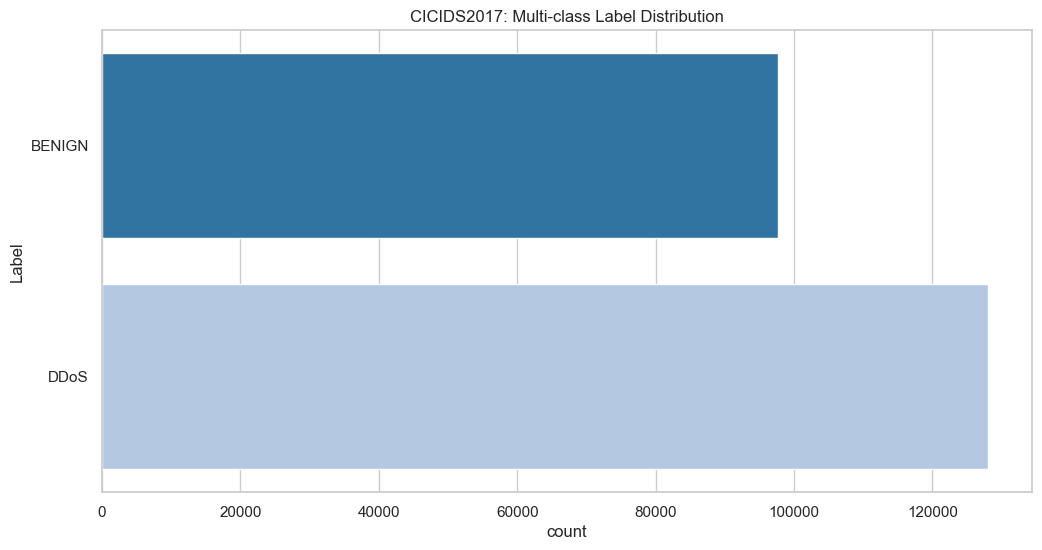

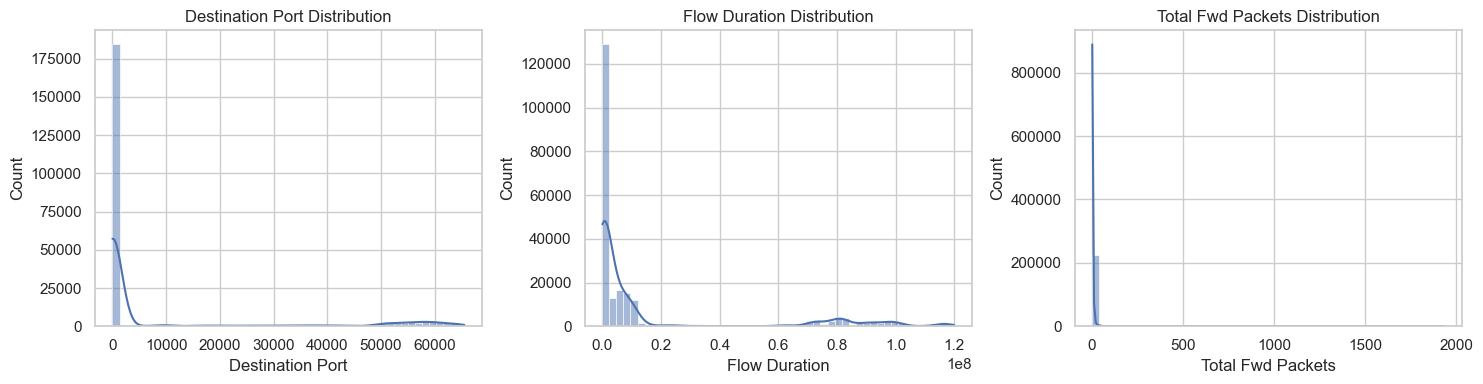

=== CICIDS2017 Multi-class Classification Results ===

Training Logistic Regression...
              precision    recall  f1-score   support

      BENIGN     0.9995    0.9749    0.9871     29316
        DDoS     0.9812    0.9996    0.9903     38408

    accuracy                         0.9889     67724
   macro avg     0.9904    0.9873    0.9887     67724
weighted avg     0.9891    0.9889    0.9889     67724


Training Decision Tree...
              precision    recall  f1-score   support

      BENIGN     0.9999    0.9999    0.9999     29316
        DDoS     0.9999    0.9999    0.9999     38408

    accuracy                         0.9999     67724
   macro avg     0.9999    0.9999    0.9999     67724
weighted avg     0.9999    0.9999    0.9999     67724


Training Random Forest...
              precision    recall  f1-score   support

      BENIGN     0.9999    1.0000    0.9999     29316
        DDoS     1.0000    0.9999    0.9999     38408

    accuracy                         0.99

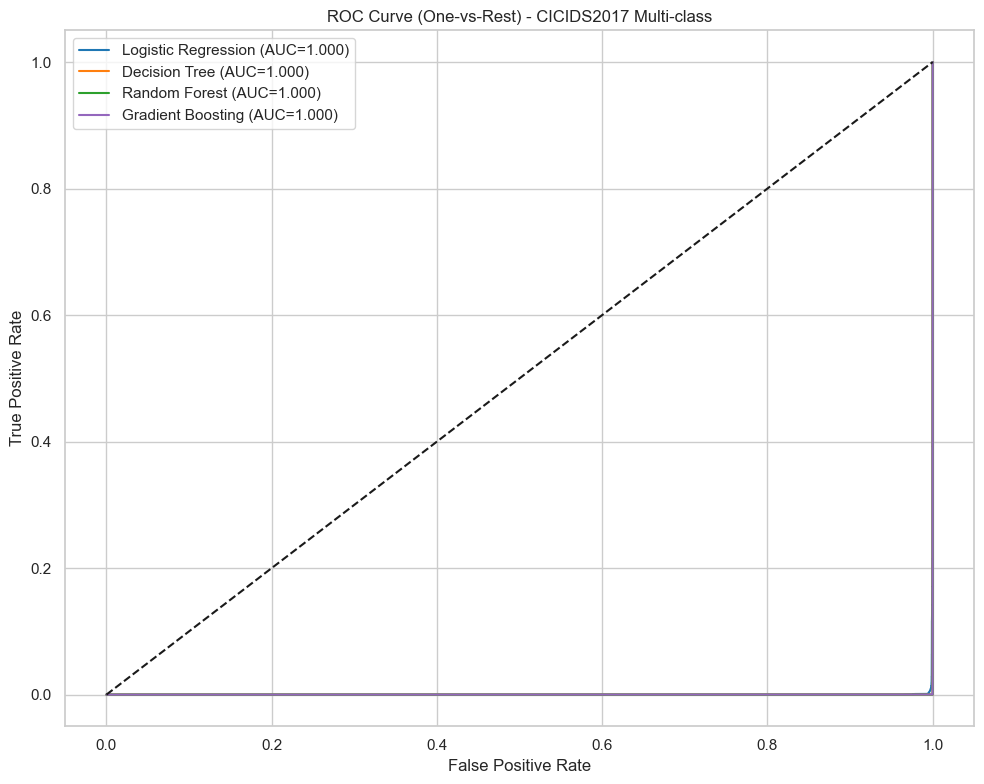

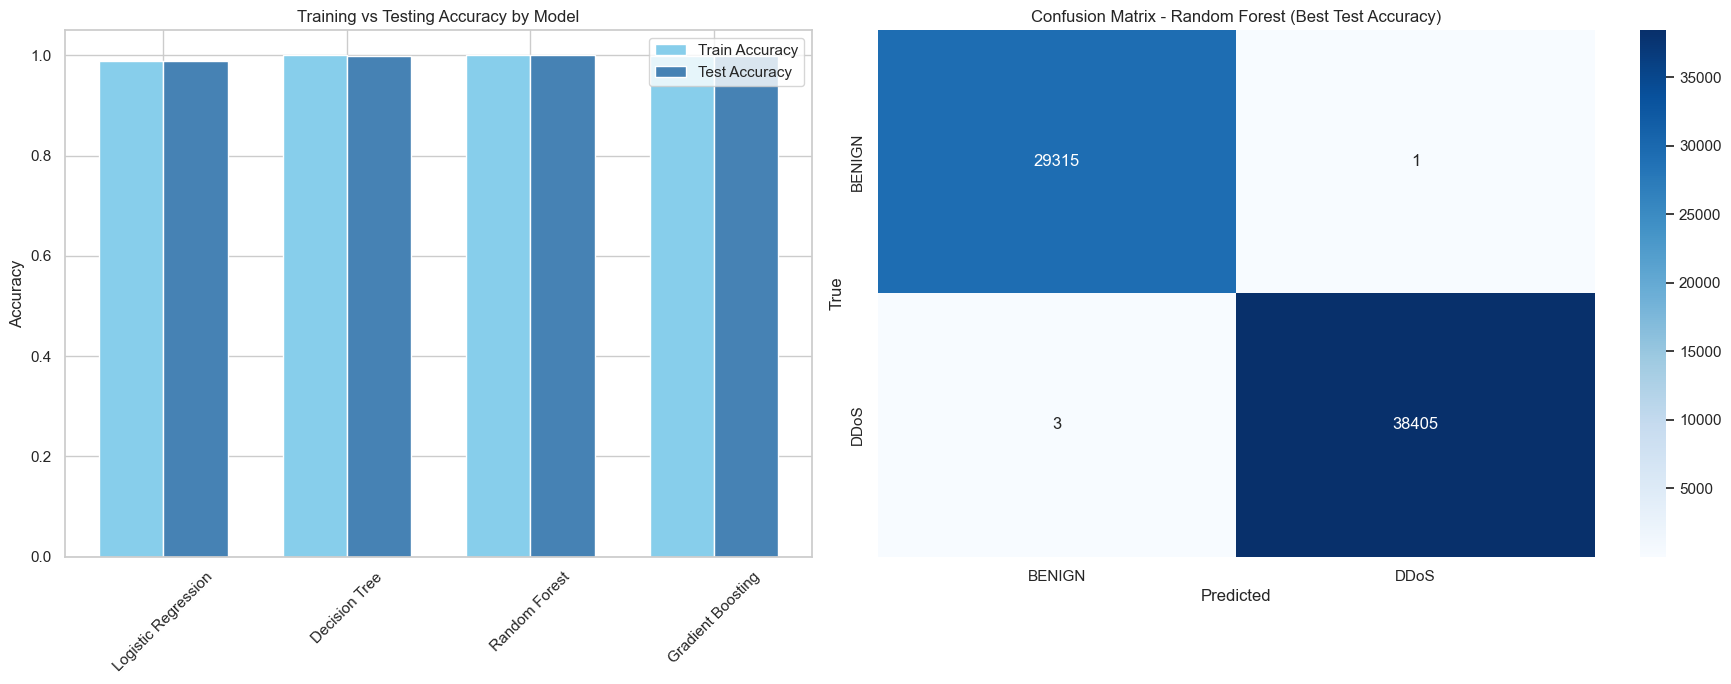

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, LabelBinarizer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, roc_curve,
                             roc_auc_score, precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.multiclass import OneVsRestClassifier

sns.set(style='whitegrid')

# Step 1: Load Data
df = pd.read_csv(r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\CICIDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
df.columns = df.columns.str.strip()

# Confirm actual label column name here
label_col_candidates = ['Label', 'label', 'Flow Label', 'FlowLabel']
label_col = None
for col in label_col_candidates:
    if col in df.columns:
        label_col = col
        print(f"Using label column: {label_col}")
        break
if label_col is None:
    raise KeyError("Label column not found.")

# Step 2: Encode multi-class labels
y = df[label_col]

# Optional: explore label distribution
plt.figure(figsize=(12,6))
sns.countplot(y=y, palette='tab20')
plt.title('CICIDS2017: Multi-class Label Distribution')
plt.show()

X = df.drop(columns=[label_col])

# Detect categorical and numeric features (adjust if needed)
cat_feats = X.select_dtypes(include='object').columns.tolist()
num_feats = X.select_dtypes(include=[np.number]).columns.tolist()

# Visualize example numeric features
plt.figure(figsize=(15,4))
for i, col in enumerate(num_feats[:3]):
    plt.subplot(1,3,i+1)
    sns.histplot(X[col], bins=50, kde=True)
    plt.title(f"{col} Distribution")
plt.tight_layout()
plt.show()

# Clean numerics
X[num_feats] = X[num_feats].replace([np.inf, -np.inf], np.nan).fillna(0)

# Step 3: Preprocessing pipeline (scale numeric, encode categorical if any)
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats)
])
X_processed = preprocessor.fit_transform(X)

# Encode labels as integers
label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)

# Step 4: Train/test split stratified
X_train, X_test, y_train, y_test, y_train_enc, y_test_enc = train_test_split(
    X_processed, y, y_enc, test_size=0.3, random_state=42, stratify=y_enc)

# Binarize train and test labels separately for ROC AUC
lb = LabelBinarizer()
y_train_bin = lb.fit_transform(y_train_enc)
y_test_bin = lb.transform(y_test_enc)

# Step 5: Models setup
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, solver='saga'),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']

results = []
train_acc_list = []
test_acc_list = []
plt.figure(figsize=(10,8))

print("=== CICIDS2017 Multi-class Classification Results ===")
for name, model in models.items():
    print(f"\nTraining {name}...")

    start_time = time.time()
    ovr_model = OneVsRestClassifier(model)
    ovr_model.fit(X_train, y_train_enc)
    train_time = time.time() - start_time

    y_train_pred = ovr_model.predict(X_train)
    y_test_pred = ovr_model.predict(X_test)

    train_acc = accuracy_score(y_train_enc, y_train_pred)
    test_acc = accuracy_score(y_test_enc, y_test_pred)

    precision = precision_score(y_test_enc, y_test_pred, average='macro', zero_division=0)
    recall = recall_score(y_test_enc, y_test_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test_enc, y_test_pred, average='macro', zero_division=0)

    # Specificity calculation averaged per class
    cm = confusion_matrix(y_test_enc, y_test_pred)
    specificities = []
    for i in range(len(cm)):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        spec = tn / (tn + fp) if (tn + fp) != 0 else 0
        specificities.append(spec)
    macro_specificity = np.mean(specificities)

    try:
        y_score = ovr_model.predict_proba(X_test)
    except AttributeError:
        dec = ovr_model.decision_function(X_test)
        y_score = (dec - dec.min(axis=0)) / (dec.max(axis=0) - dec.min(axis=0) + 1e-10)

    # Fix for binary vs multiclass ROC AUC
    if y_test_bin.shape[1] == 1:  # binary classification case
        auc_macro = roc_auc_score(y_test_bin.ravel(), y_score[:, 1])
    else:
        auc_macro = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')

    # ROC curve for first class for visualization
    fpr, tpr, _ = roc_curve(y_test_bin[:, 0], y_score[:, 0])

    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_macro:.3f})', color=colors.pop(0))

    print(classification_report(y_test_enc, y_test_pred, target_names=label_encoder.classes_, digits=4))

    results.append({
        'Model': name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Specificity': macro_specificity,
        'AUC': auc_macro,
        'Time (s)': train_time,
        'ConfusionMatrix': cm,
        'Predictions': y_test_pred
    })

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve (One-vs-Rest) - CICIDS2017 Multi-class')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(results)

# Combined plot: Training & Testing Accuracy + Confusion Matrix of best model
best_index = summary_df['Test Acc'].idxmax()
best_model_info = summary_df.iloc[best_index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [1, 1.2]})

# Bar plot of accuracies
x = np.arange(len(summary_df))
bar_width = 0.35
ax1.bar(x - bar_width/2, summary_df['Train Acc'], width=bar_width, label='Train Accuracy', color='skyblue')
ax1.bar(x + bar_width/2, summary_df['Test Acc'], width=bar_width, label='Test Accuracy', color='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels(summary_df['Model'], rotation=45)
ax1.set_ylabel('Accuracy')
ax1.set_title('Training vs Testing Accuracy by Model')
ax1.legend()
ax1.grid(True, axis='y')

# Confusion matrix heatmap
sns.heatmap(best_model_info['ConfusionMatrix'], annot=True, fmt='d', ax=ax2,
            cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')
ax2.set_title(f'Confusion Matrix - {best_model_info["Model"]} (Best Test Accuracy)')

plt.tight_layout()
plt.show()


Using label column: Label


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26980\91381558.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=y, palette='tab20')


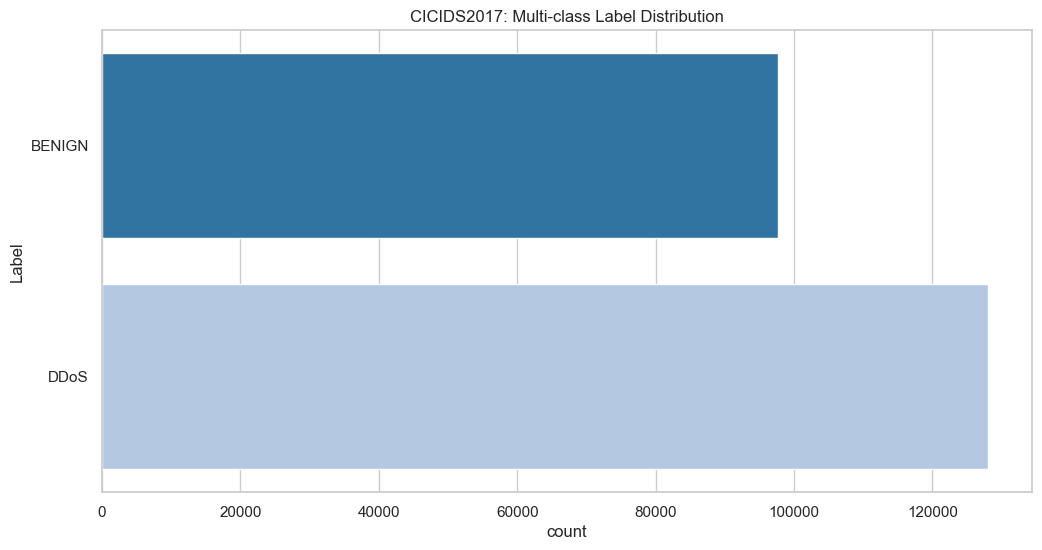

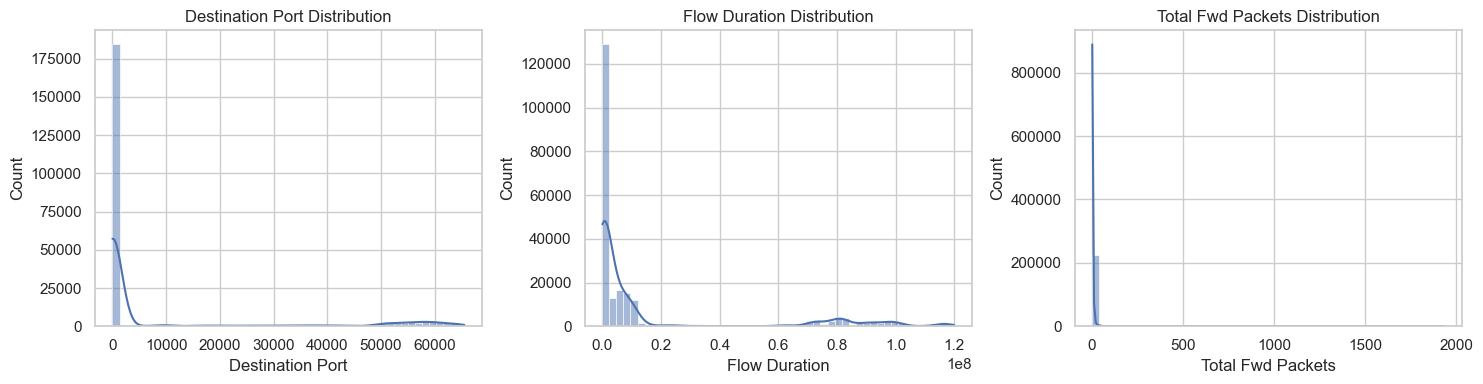

=== CICIDS2017 Multi-class Classification Results ===

Training Logistic Regression...
              precision    recall  f1-score   support

      BENIGN     0.9995    0.9749    0.9871     29316
        DDoS     0.9812    0.9996    0.9903     38408

    accuracy                         0.9889     67724
   macro avg     0.9904    0.9873    0.9887     67724
weighted avg     0.9891    0.9889    0.9889     67724


Training Decision Tree...
              precision    recall  f1-score   support

      BENIGN     0.9999    0.9999    0.9999     29316
        DDoS     0.9999    0.9999    0.9999     38408

    accuracy                         0.9999     67724
   macro avg     0.9999    0.9999    0.9999     67724
weighted avg     0.9999    0.9999    0.9999     67724


Training Random Forest...
              precision    recall  f1-score   support

      BENIGN     1.0000    1.0000    1.0000     29316
        DDoS     1.0000    1.0000    1.0000     38408

    accuracy                         1.00

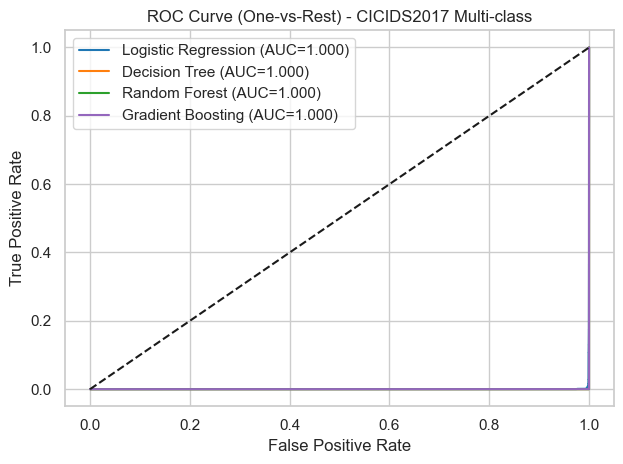

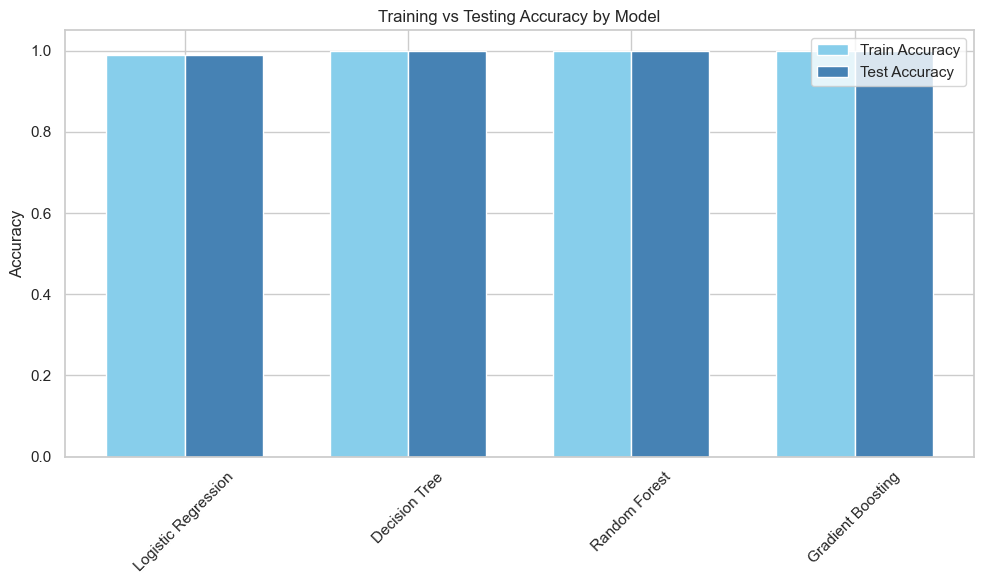

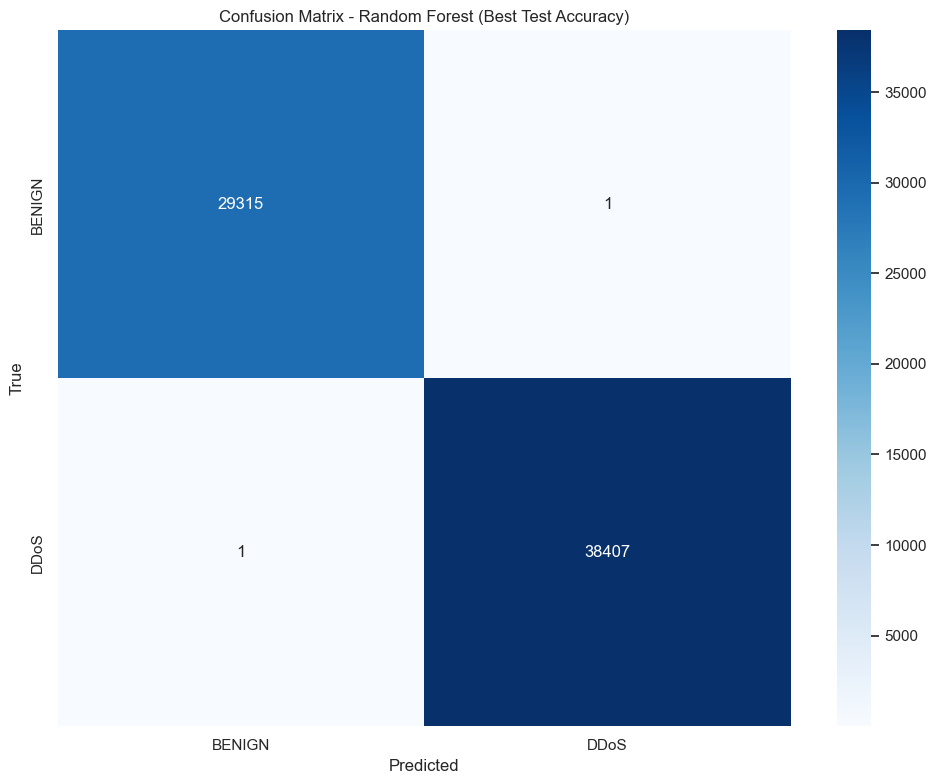

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, LabelBinarizer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, roc_curve,
                             roc_auc_score, precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.multiclass import OneVsRestClassifier

sns.set(style='whitegrid')

# Step 1: Load Data
df = pd.read_csv(r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\CICIDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
df.columns = df.columns.str.strip()

# Confirm actual label column name here
label_col_candidates = ['Label', 'label', 'Flow Label', 'FlowLabel']
label_col = None
for col in label_col_candidates:
    if col in df.columns:
        label_col = col
        print(f"Using label column: {label_col}")
        break
if label_col is None:
    raise KeyError("Label column not found.")

# Step 2: Encode multi-class labels
y = df[label_col]

# Optional: explore label distribution
plt.figure(figsize=(12,6))
sns.countplot(y=y, palette='tab20')
plt.title('CICIDS2017: Multi-class Label Distribution')
plt.show()

X = df.drop(columns=[label_col])

# Detect categorical and numeric features (adjust if needed)
cat_feats = X.select_dtypes(include='object').columns.tolist()
num_feats = X.select_dtypes(include=[np.number]).columns.tolist()

# Visualize example numeric features
plt.figure(figsize=(15,4))
for i, col in enumerate(num_feats[:3]):
    plt.subplot(1,3,i+1)
    sns.histplot(X[col], bins=50, kde=True)
    plt.title(f"{col} Distribution")
plt.tight_layout()
plt.show()

# Clean numerics
X[num_feats] = X[num_feats].replace([np.inf, -np.inf], np.nan).fillna(0)

# Step 3: Preprocessing pipeline (scale numeric, encode categorical if any)
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats)
])
X_processed = preprocessor.fit_transform(X)

# Encode labels as integers
label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)

# Step 4: Train/test split stratified
X_train, X_test, y_train, y_test, y_train_enc, y_test_enc = train_test_split(
    X_processed, y, y_enc, test_size=0.3, random_state=42, stratify=y_enc)

# Binarize train and test labels separately for ROC AUC
lb = LabelBinarizer()
y_train_bin = lb.fit_transform(y_train_enc)
y_test_bin = lb.transform(y_test_enc)

# Step 5: Models setup
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, solver='saga'),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']

results = []
train_acc_list = []
test_acc_list = []

print("=== CICIDS2017 Multi-class Classification Results ===")
for name, model in models.items():
    print(f"\nTraining {name}...")
    start_time = time.time()
    ovr_model = OneVsRestClassifier(model)
    ovr_model.fit(X_train, y_train_enc)
    train_time = time.time() - start_time

    y_train_pred = ovr_model.predict(X_train)
    y_test_pred = ovr_model.predict(X_test)

    train_acc = accuracy_score(y_train_enc, y_train_pred)
    test_acc = accuracy_score(y_test_enc, y_test_pred)

    precision = precision_score(y_test_enc, y_test_pred, average='macro', zero_division=0)
    recall = recall_score(y_test_enc, y_test_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test_enc, y_test_pred, average='macro', zero_division=0)

    # Specificity calculation averaged per class
    cm = confusion_matrix(y_test_enc, y_test_pred)
    specificities = []
    for i in range(len(cm)):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        spec = tn / (tn + fp) if (tn + fp) != 0 else 0
        specificities.append(spec)
    macro_specificity = np.mean(specificities)

    try:
        y_score = ovr_model.predict_proba(X_test)
    except AttributeError:
        dec = ovr_model.decision_function(X_test)
        y_score = (dec - dec.min(axis=0)) / (dec.max(axis=0) - dec.min(axis=0) + 1e-10)

    # Fix for binary vs multiclass ROC AUC
    if y_test_bin.shape[1] == 1:  # binary classification case
        auc_macro = roc_auc_score(y_test_bin.ravel(), y_score[:, 1])
    else:
        auc_macro = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')

    # ROC curve for first class for visualization
    fpr, tpr, _ = roc_curve(y_test_bin[:, 0], y_score[:, 0])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_macro:.3f})', color=colors.pop(0))

    print(classification_report(y_test_enc, y_test_pred, target_names=label_encoder.classes_, digits=4))

    results.append({
        'Model': name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Specificity': macro_specificity,
        'AUC': auc_macro,
        'Time (s)': train_time,
        'ConfusionMatrix': cm,
        'Predictions': y_test_pred
    })

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve (One-vs-Rest) - CICIDS2017 Multi-class')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(results)

# Plot training and testing accuracy in one graph
plt.figure(figsize=(10, 6))
x = np.arange(len(summary_df))
bar_width = 0.35
plt.bar(x - bar_width/2, summary_df['Train Acc'], width=bar_width, label='Train Accuracy', color='skyblue')
plt.bar(x + bar_width/2, summary_df['Test Acc'], width=bar_width, label='Test Accuracy', color='steelblue')
plt.xticks(x, summary_df['Model'], rotation=45)
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy by Model')
plt.legend()
plt.tight_layout()
plt.show()

# Plot confusion matrix for the best model (by test accuracy) in a separate figure
best_index = summary_df['Test Acc'].idxmax()
best_model_info = summary_df.iloc[best_index]

plt.figure(figsize=(10, 8))
sns.heatmap(best_model_info['ConfusionMatrix'], annot=True, fmt='d',
            cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_model_info["Model"]} (Best Test Accuracy)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()


Using label column: Label


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26980\1169213960.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y, order=order, palette="Set3")


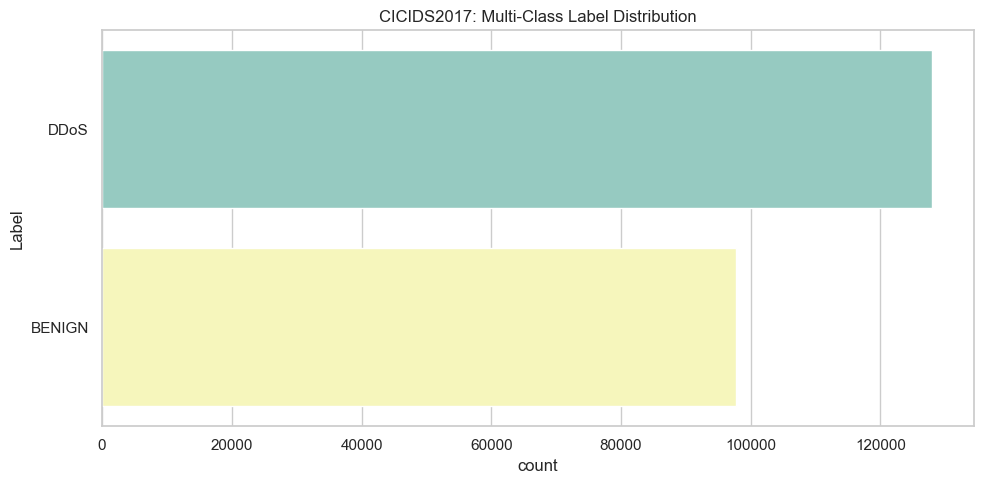

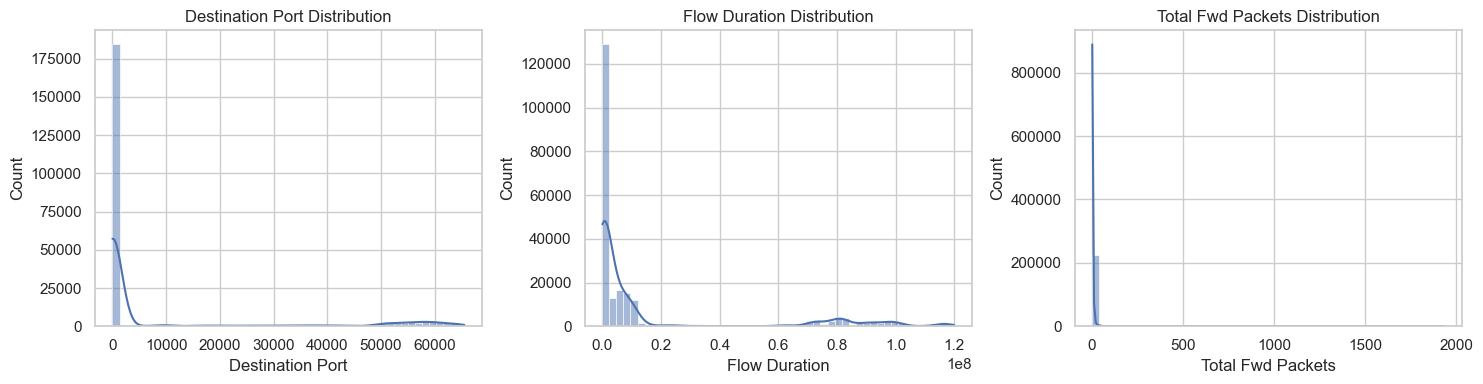


Training Logistic Regression...


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

      BENIGN      1.000     0.975     0.987     29316
        DDoS      0.981     1.000     0.990     38408

    accuracy                          0.989     67724
   macro avg      0.990     0.987     0.989     67724
weighted avg      0.989     0.989     0.989     67724



<Figure size 1000x800 with 0 Axes>

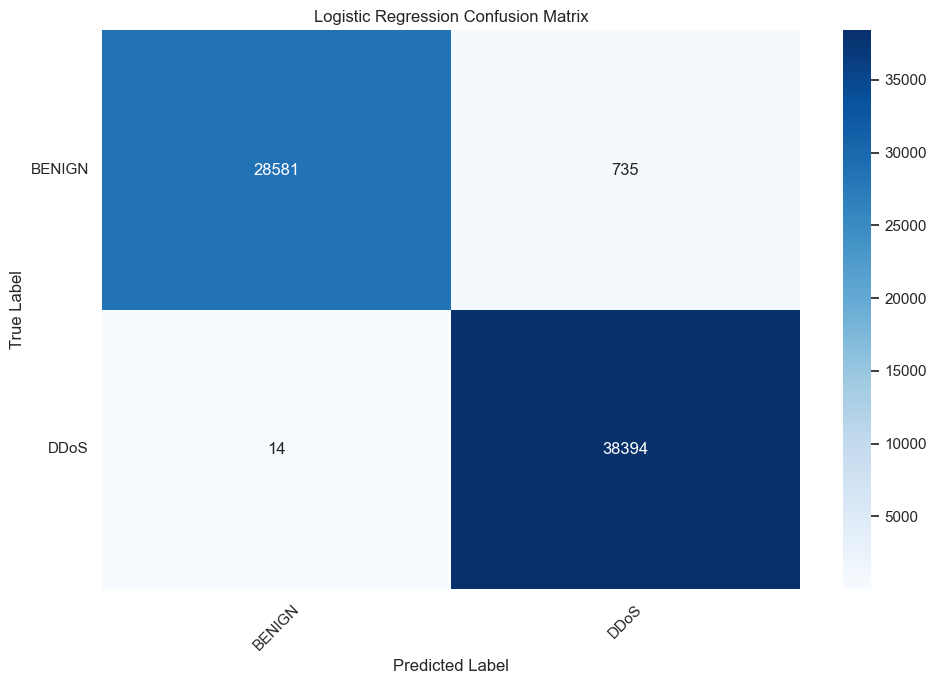


Training Decision Tree...
              precision    recall  f1-score   support

      BENIGN      1.000     1.000     1.000     29316
        DDoS      1.000     1.000     1.000     38408

    accuracy                          1.000     67724
   macro avg      1.000     1.000     1.000     67724
weighted avg      1.000     1.000     1.000     67724



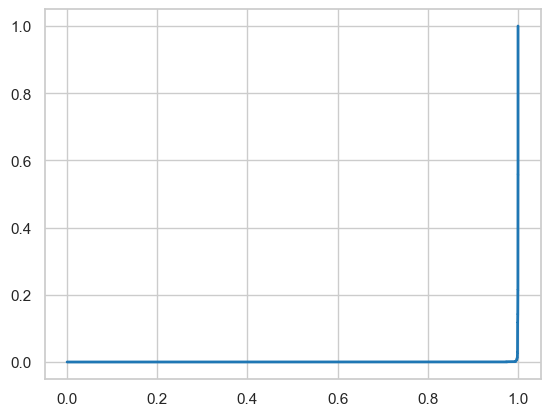

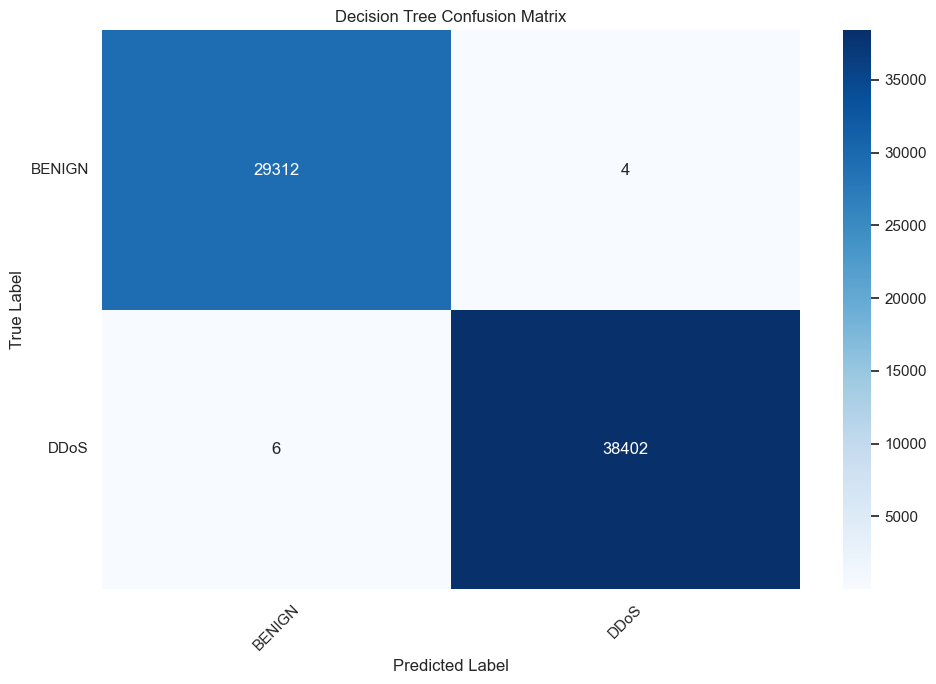


Training Random Forest...
              precision    recall  f1-score   support

      BENIGN      1.000     1.000     1.000     29316
        DDoS      1.000     1.000     1.000     38408

    accuracy                          1.000     67724
   macro avg      1.000     1.000     1.000     67724
weighted avg      1.000     1.000     1.000     67724



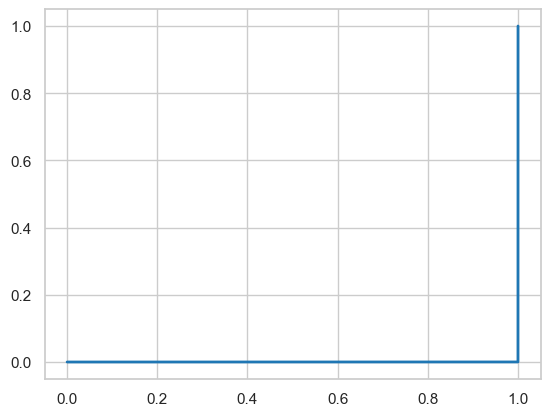

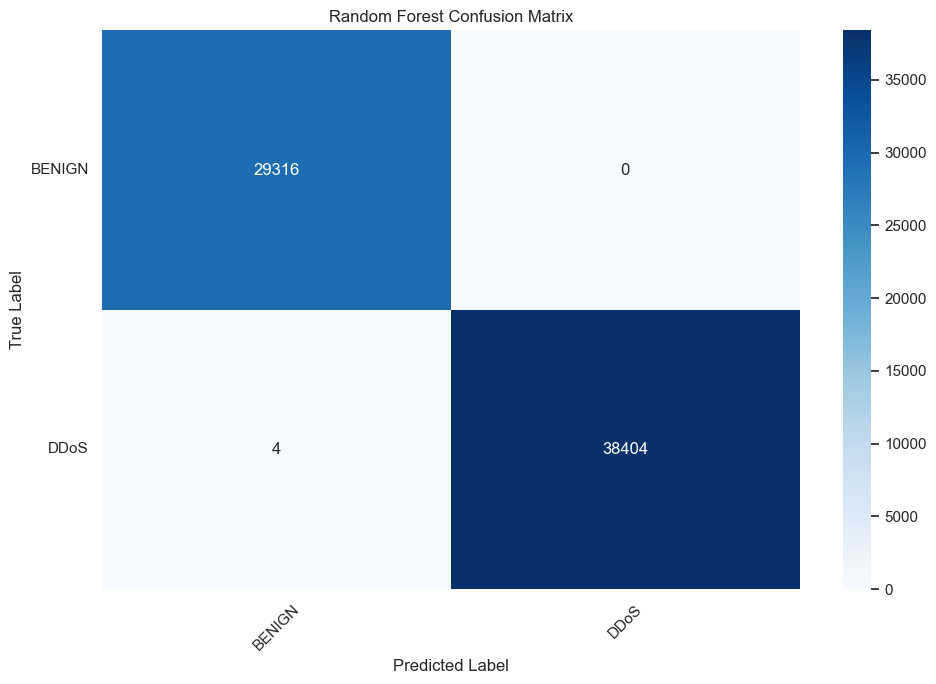


Training Gradient Boosting...
              precision    recall  f1-score   support

      BENIGN      1.000     1.000     1.000     29316
        DDoS      1.000     1.000     1.000     38408

    accuracy                          1.000     67724
   macro avg      1.000     1.000     1.000     67724
weighted avg      1.000     1.000     1.000     67724



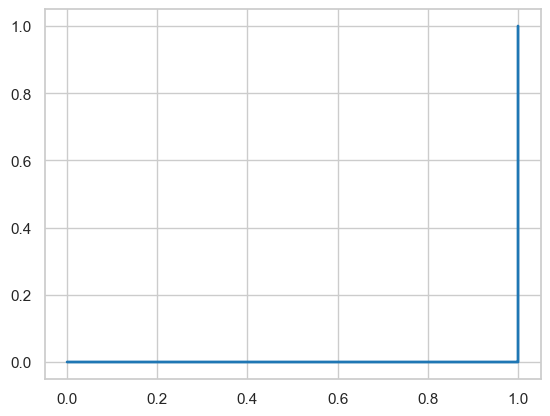

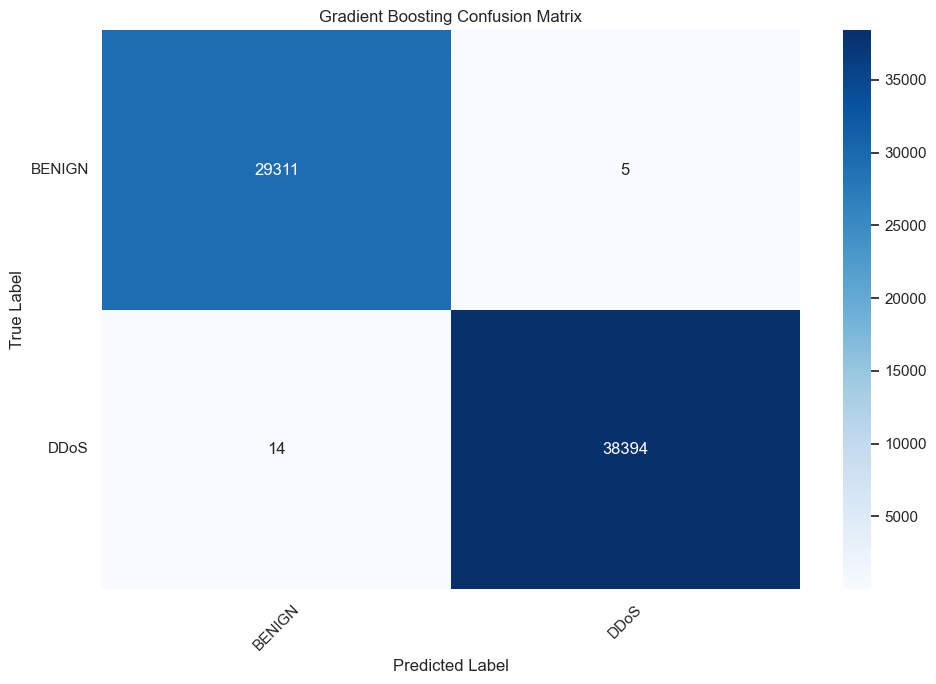

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26980\1169213960.py:153: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right', fontsize='small')


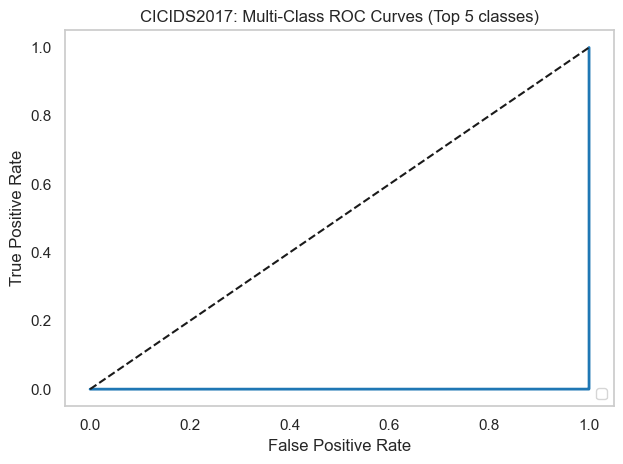


Summary Table:
                  Model  Train Acc  Test Acc  Precision    Recall        F1  \
0  Logistic Regression   0.988812  0.988940   0.990363  0.987282  0.988703   
1        Decision Tree   1.000000  0.999852   0.999846  0.999854  0.999850   
2        Random Forest   1.000000  0.999941   0.999932  0.999948  0.999940   
3    Gradient Boosting   0.999854  0.999719   0.999696  0.999732  0.999714   

            AUC     Time(s)  
0  3.358991e-04   16.118724  
1  1.463309e-04    4.085323  
2  9.192083e-08   50.239221  
3  5.959312e-07  323.532021  


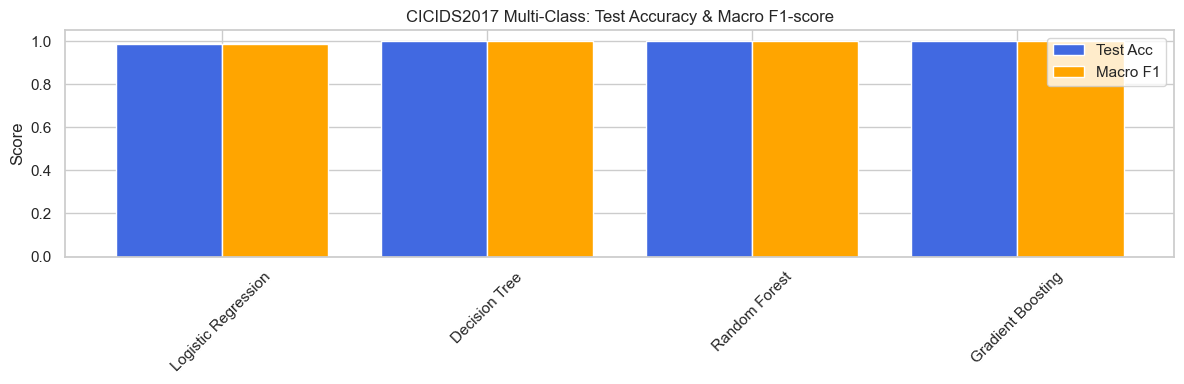

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

sns.set(style='whitegrid')

# Step 1: Load Data
df = pd.read_csv(r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\CICIDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
df.columns = df.columns.str.strip()  # Clean column names

# Step 2: Prepare Multi-Class Label
label_col_candidates = ['Label', 'label', 'Flow Label', 'FlowLabel']
label_col = None
for col in label_col_candidates:
    if col in df.columns:
        label_col = col
        print(f"Using label column: {label_col}")
        break
if label_col is None:
    raise KeyError("Label column not found.")

y = df[label_col]

# Visualize Multi-Class Distribution
plt.figure(figsize=(10,5))
order = y.value_counts().index
sns.countplot(y, order=order, palette="Set3")
plt.title('CICIDS2017: Multi-Class Label Distribution')
plt.tight_layout()
plt.show()

# Step 3: Feature Preparation
X = df.drop(columns=[label_col])
cat_feats = X.select_dtypes(include='object').columns.tolist()
num_feats = X.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(15,4))
for i, col in enumerate(num_feats[:3]):
    plt.subplot(1,3,i+1)
    sns.histplot(X[col], bins=50, kde=True)
    plt.title(f"{col} Distribution")
plt.tight_layout()
plt.show()
if cat_feats:
    plt.figure(figsize=(8,4))
    sns.countplot(x=cat_feats[0], data=X, palette="pastel")
    plt.title(f"Distribution of {cat_feats[0]}")
    plt.tight_layout()
    plt.show()
    
X[num_feats] = X[num_feats].replace([np.inf, -np.inf], np.nan).fillna(0)

# Step 4: Preprocessing
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats)
])
X_processed = preprocessor.fit_transform(X)

# Step 5: Stratified Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.3, random_state=42, stratify=y)

# Step 6: Model Setup
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, solver='saga', multi_class='auto'),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}

summary = []

# Step 7: Multi-Class ROC Prep
classes = np.unique(y)
y_test_binarized = label_binarize(y_test, classes=classes)
n_classes = y_test_binarized.shape[1]
color_cycle = plt.cm.tab10.colors

plt.figure(figsize=(10,8))
for name_idx, (name, model) in enumerate(models.items()):
    print(f"\nTraining {name}...")
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc  = accuracy_score(y_test, y_test_pred)
    macro_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
    macro_recall = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
    macro_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

    print(classification_report(y_test, y_test_pred, digits=3))

    # Confusion Matrix plot
    cm = confusion_matrix(y_test, y_test_pred, labels=classes)
    plt.figure(figsize=(10,7))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'{name} Confusion Matrix')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # ROC Curve (one-vs-rest, limited to up to 5 classes for clarity)
    macro_roc_auc = np.nan
    plotted = 0
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
        roc_aucs = []
        for i in range(n_classes):
            if plotted < 5:  # Too many lines get crowded
                fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
                auc_score = auc(fpr, tpr)
                plt.plot(fpr, tpr, color=color_cycle[i%10], lw=2,
                         label=f"{name}: {classes[i]} (AUC={auc_score:.2f})" if name_idx==0 else None)
                roc_aucs.append(auc_score)
                plotted += 1
        if roc_aucs:
            macro_roc_auc = np.nanmean(roc_aucs)
    else:
        macro_roc_auc = np.nan

    summary.append({
        'Model': name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Precision': macro_precision,
        'Recall': macro_recall,
        'F1': macro_f1,
        'AUC': macro_roc_auc,
        'Time(s)': train_time
    })

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('CICIDS2017: Multi-Class ROC Curves (Top 5 classes)')
plt.legend(loc='lower right', fontsize='small')
plt.grid()
plt.tight_layout()
plt.show()

# Step 8: Results Table and Plot
summary_df = pd.DataFrame(summary)
print("\nSummary Table:\n", summary_df)

plt.figure(figsize=(12,4))
x = np.arange(len(models))
plt.bar(x-0.2, summary_df['Test Acc'], width=0.4, label='Test Acc', color='royalblue')
plt.bar(x+0.2, summary_df['F1'], width=0.4, label='Macro F1', color='orange')
plt.xticks(x, summary_df['Model'], rotation=45)
plt.ylabel('Score')
plt.title('CICIDS2017 Multi-Class: Test Accuracy & Macro F1-score')
plt.legend()
plt.tight_layout()
plt.show()


Using label column: Label


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26980\1291012574.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y, order=order, palette="Set3")


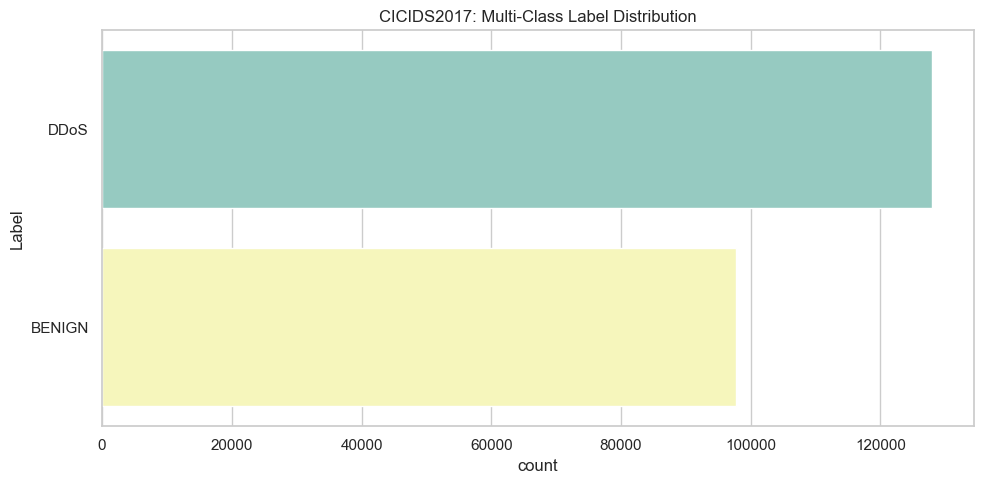

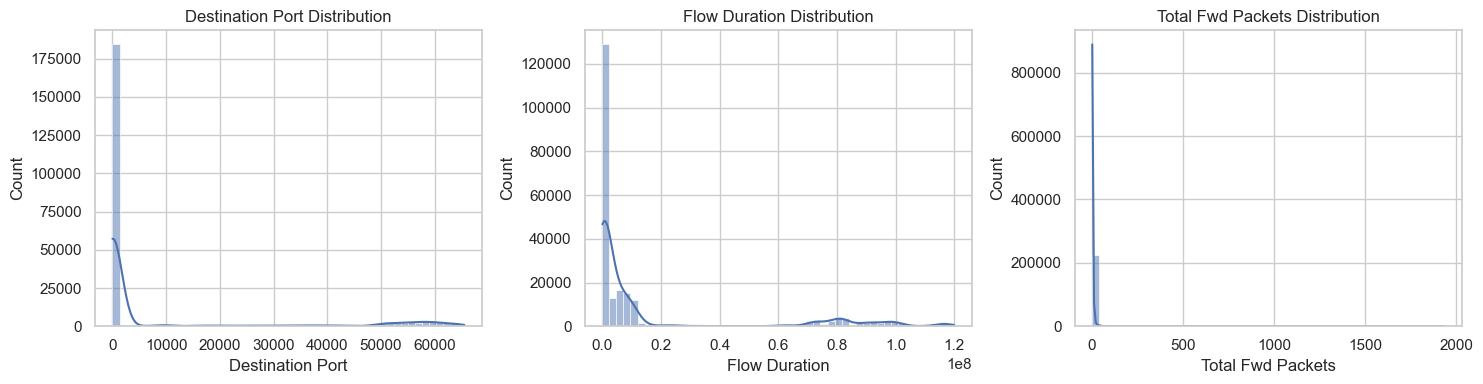


Training Logistic Regression...


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

      BENIGN      1.000     0.975     0.987     29316
        DDoS      0.981     1.000     0.990     38408

    accuracy                          0.989     67724
   macro avg      0.990     0.987     0.989     67724
weighted avg      0.989     0.989     0.989     67724


Training Decision Tree...
              precision    recall  f1-score   support

      BENIGN      1.000     1.000     1.000     29316
        DDoS      1.000     1.000     1.000     38408

    accuracy                          1.000     67724
   macro avg      1.000     1.000     1.000     67724
weighted avg      1.000     1.000     1.000     67724


Training Random Forest...
              precision    recall  f1-score   support

      BENIGN      1.000     1.000     1.000     29316
        DDoS      1.000     1.000     1.000     38408

    accuracy                          1.000     67724
   macro avg      1.000     1.000     1.000     67724
weighted avg      1.

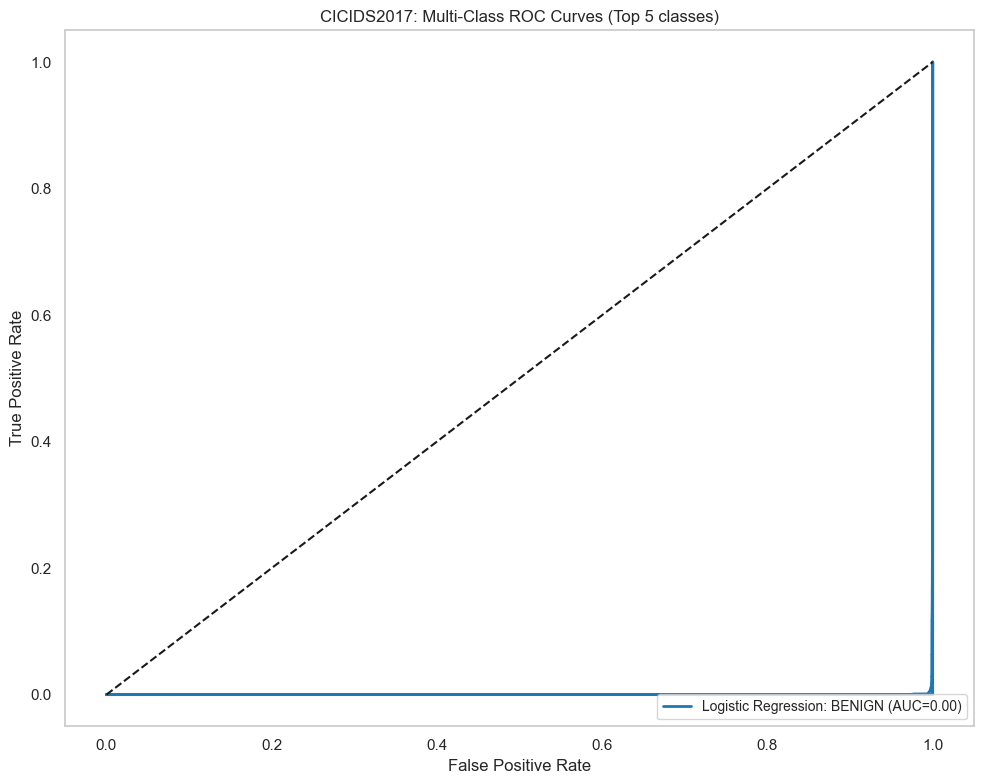

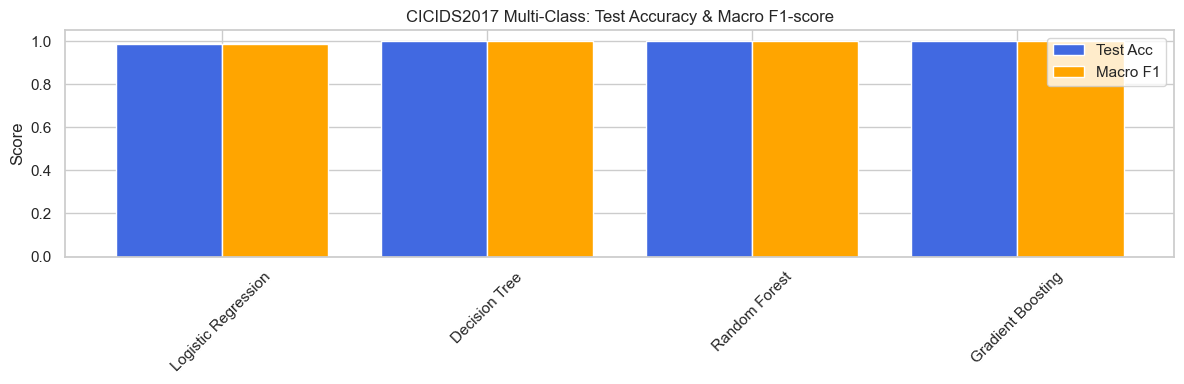

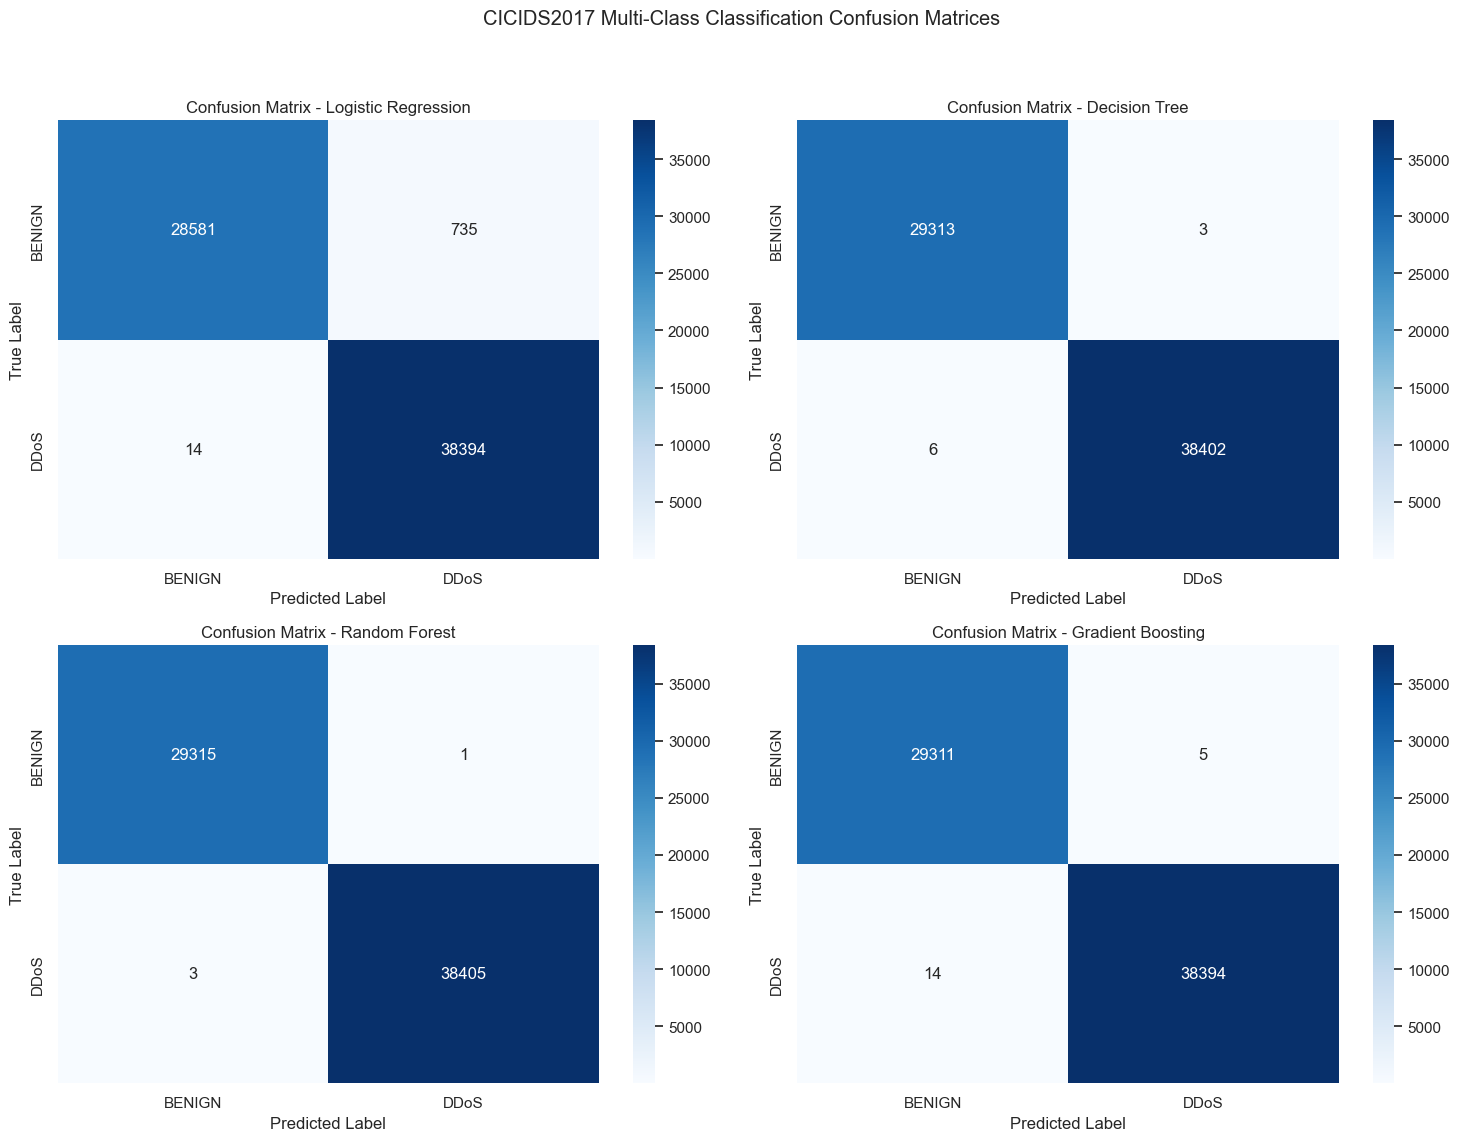


Summary Table:
                  Model  Train Acc  Test Acc  Precision    Recall        F1  \
0  Logistic Regression   0.988812  0.988940   0.990363  0.987282  0.988703   
1        Decision Tree   1.000000  0.999867   0.999859  0.999871  0.999865   
2        Random Forest   1.000000  0.999941   0.999936  0.999944  0.999940   
3    Gradient Boosting   0.999854  0.999719   0.999696  0.999732  0.999714   

            AUC     Time(s)  
0  3.358814e-04   17.722728  
1  1.292753e-04    6.094039  
2  1.265577e-07   70.841179  
3  5.959312e-07  417.499166  


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                             precision_score, recall_score, f1_score, roc_curve, auc)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

sns.set(style='whitegrid')

# Load Data
df = pd.read_csv(r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\CICIDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
df.columns = df.columns.str.strip()

# Prepare Multi-Class Label
label_col_candidates = ['Label', 'label', 'Flow Label', 'FlowLabel']
label_col = None
for col in label_col_candidates:
    if col in df.columns:
        label_col = col
        print(f"Using label column: {label_col}")
        break
if label_col is None:
    raise KeyError("Label column not found.")

y = df[label_col]

# Visualize Multi-Class Distribution
plt.figure(figsize=(10,5))
order = y.value_counts().index
sns.countplot(y, order=order, palette="Set3")
plt.title('CICIDS2017: Multi-Class Label Distribution')
plt.tight_layout()
plt.show()

# Feature Preparation
X = df.drop(columns=[label_col])
cat_feats = X.select_dtypes(include='object').columns.tolist()
num_feats = X.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(15,4))
for i, col in enumerate(num_feats[:3]):
    plt.subplot(1,3,i+1)
    sns.histplot(X[col], bins=50, kde=True)
    plt.title(f"{col} Distribution")
plt.tight_layout()
plt.show()

if cat_feats:
    plt.figure(figsize=(8,4))
    sns.countplot(x=cat_feats[0], data=X, palette="pastel")
    plt.title(f"Distribution of {cat_feats[0]}")
    plt.tight_layout()
    plt.show()

X[num_feats] = X[num_feats].replace([np.inf, -np.inf], np.nan).fillna(0)

# Preprocessing
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats)
])
X_processed = preprocessor.fit_transform(X)

# Stratified Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.3, random_state=42, stratify=y)

# Models Setup
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, solver='saga', multi_class='auto'),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}

summary = []

classes = np.unique(y)
y_test_binarized = label_binarize(y_test, classes=classes)
n_classes = y_test_binarized.shape[1]
color_cycle = plt.cm.tab10.colors

plt.figure(figsize=(10,8))
for name_idx, (name, model) in enumerate(models.items()):
    print(f"\nTraining {name}...")
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc  = accuracy_score(y_test, y_test_pred)
    macro_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
    macro_recall = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
    macro_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

    print(classification_report(y_test, y_test_pred, digits=3))

    # ROC Curve (one-vs-rest, limited to up to 5 classes for clarity)
    macro_roc_auc = np.nan
    plotted = 0
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
        roc_aucs = []
        for i in range(n_classes):
            if plotted < 5:  # Too many lines get crowded
                fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
                auc_score = auc(fpr, tpr)
                plt.plot(fpr, tpr, color=color_cycle[i%10], lw=2,
                         label=f"{name}: {classes[i]} (AUC={auc_score:.2f})" if name_idx==0 else None)
                roc_aucs.append(auc_score)
                plotted += 1
        if roc_aucs:
            macro_roc_auc = np.nanmean(roc_aucs)
    else:
        macro_roc_auc = np.nan

    summary.append({
        'Model': name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Precision': macro_precision,
        'Recall': macro_recall,
        'F1': macro_f1,
        'AUC': macro_roc_auc,
        'Time(s)': train_time,
        'y_test_pred': y_test_pred
    })

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('CICIDS2017: Multi-Class ROC Curves (Top 5 classes)')
plt.legend(loc='lower right', fontsize='small')
plt.grid()
plt.tight_layout()
plt.show()

# Results Table and Plot
summary_df = pd.DataFrame(summary)

plt.figure(figsize=(12,4))
x = np.arange(len(models))
plt.bar(x-0.2, summary_df['Test Acc'], width=0.4, label='Test Acc', color='royalblue')
plt.bar(x+0.2, summary_df['F1'], width=0.4, label='Macro F1', color='orange')
plt.xticks(x, summary_df['Model'], rotation=45)
plt.ylabel('Score')
plt.title('CICIDS2017 Multi-Class: Test Accuracy & Macro F1-score')
plt.legend()
plt.tight_layout()
plt.show()

# Confusion Matrices for all models in one figure
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
for i, (name, model) in enumerate(models.items()):
    y_test_pred = summary[i]['y_test_pred']
    cm = confusion_matrix(y_test, y_test_pred, labels=classes)
    sns.heatmap(cm, annot=True, fmt='d', ax=axs[i//2, i%2], 
                xticklabels=classes, yticklabels=classes, cmap='Blues')
    axs[i//2, i%2].set_title(f'Confusion Matrix - {name}')
    axs[i//2, i%2].set_xlabel('Predicted Label')
    axs[i//2, i%2].set_ylabel('True Label')

plt.suptitle('CICIDS2017 Multi-Class Classification Confusion Matrices')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Remove predictions from summary for display
summary_df.drop(columns=['y_test_pred'], inplace=True)
print("\nSummary Table:\n", summary_df)


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Unique classes in y_test: ['BENIGN' 'DDoS']
Shape of y_test_binarized: (67724, 1)
Shape of y_score_all: (67724, 2)
Not enough classes for ROC curve plotting or mismatch in predict_proba output


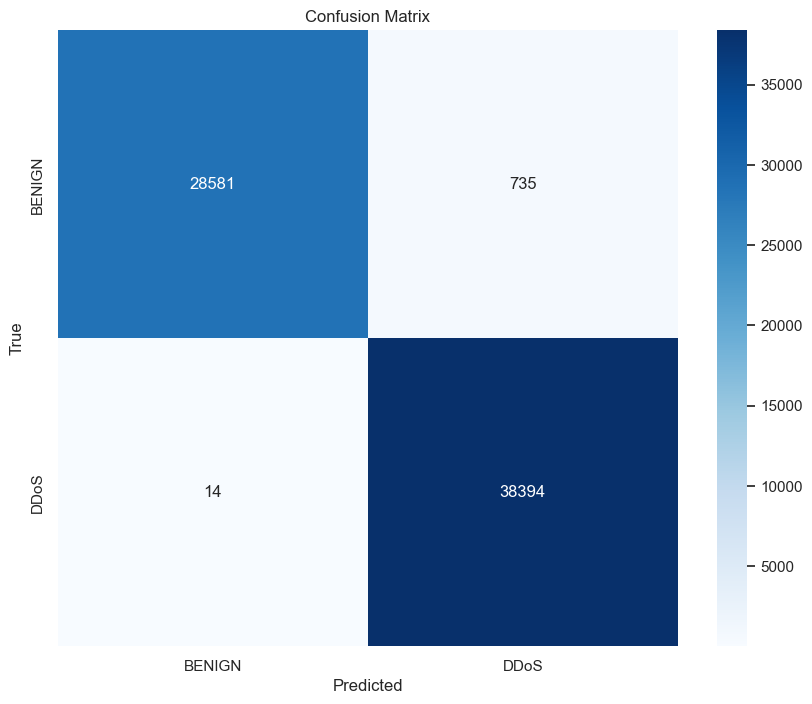

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression

sns.set(style='whitegrid')

# Load Data - update path as needed
df = pd.read_csv(r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\CICIDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
df.columns = df.columns.str.strip()

# Identify label column
label_col = next(col for col in ['Label', 'label', 'Flow Label', 'FlowLabel'] if col in df.columns)
y = df[label_col]
X = df.drop(columns=[label_col])

# Features
cat_feats = X.select_dtypes(include='object').columns.tolist()
num_feats = X.select_dtypes(include=[np.number]).columns.tolist()
X[num_feats] = X[num_feats].replace([np.inf, -np.inf], np.nan).fillna(0)

# Preprocessing
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats)
])
X_processed = preprocessor.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.3, random_state=42, stratify=y)

# Model training
model = LogisticRegression(max_iter=500, solver='saga', multi_class='auto')
model.fit(X_train, y_train)
y_test_pred = model.predict(X_test)

# Binarize labels for ROC based on actual test classes
actual_classes = np.unique(y_test)
print("Unique classes in y_test:", actual_classes)

y_test_binarized = label_binarize(y_test, classes=actual_classes)
print("Shape of y_test_binarized:", y_test_binarized.shape)

if hasattr(model, "predict_proba"):
    y_score_all = model.predict_proba(X_test)
    print("Shape of y_score_all:", y_score_all.shape)

    # Ensure dimensions match and more than one class
    if y_test_binarized.shape[1] > 1 and y_score_all.shape[1] == y_test_binarized.shape[1]:
        plt.figure(figsize=(12, 6))
        colors = plt.cm.tab10.colors
        for i, cls in enumerate(actual_classes[:min(5, len(actual_classes))]):
            y_score = y_score_all[:, i]
            fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score)
            auc_score = auc(fpr, tpr)
            plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{cls} (AUC={auc_score:.2f})')
        plt.plot([0, 1], [0, 1], 'k--', lw=1)
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Multi-Class ROC Curve (Top 5 Classes Present in Test Set)')
        plt.legend(loc='lower right')
        plt.grid(True)
        plt.show()
    else:
        print("Not enough classes for ROC curve plotting or mismatch in predict_proba output")
else:
    print("Model does not support predict_proba, ROC curve cannot be plotted.")


# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

plt.show()


              precision    recall  f1-score   support

      BENIGN      1.000     1.000     1.000     29316
        DDoS      1.000     1.000     1.000     38408

    accuracy                          1.000     67724
   macro avg      1.000     1.000     1.000     67724
weighted avg      1.000     1.000     1.000     67724

Unique classes in test set: ['BENIGN' 'DDoS']


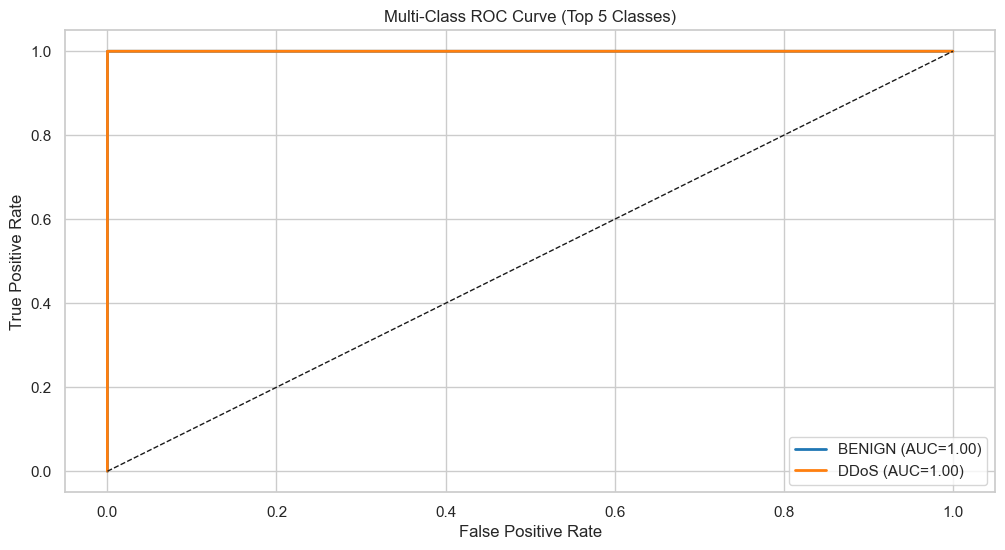

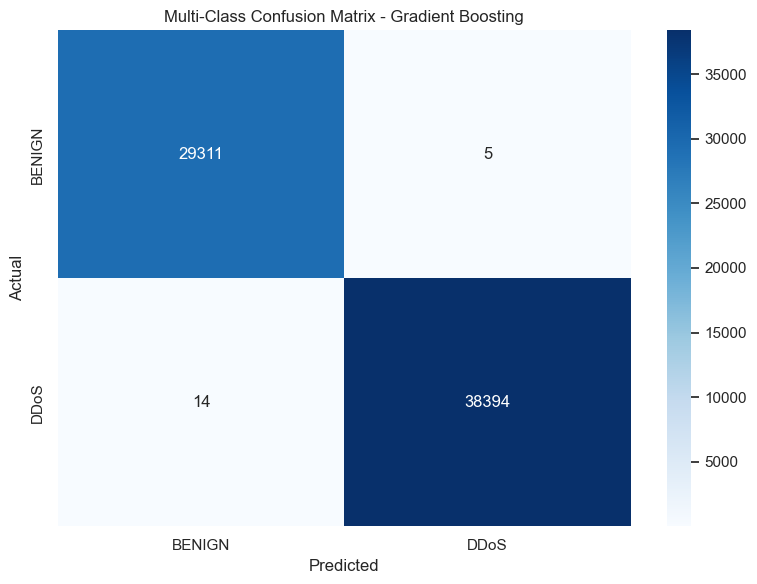

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
from sklearn.ensemble import GradientBoostingClassifier

sns.set(style='whitegrid')

# Load the data
df = pd.read_csv(r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\CICIDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
df.columns = df.columns.str.strip()

# Identify label column
label_col = next(col for col in ['Label', 'label', 'Flow Label', 'FlowLabel'] if col in df.columns)
y = df[label_col]
X = df.drop(columns=[label_col])

# Separate feature types
cat_feats = X.select_dtypes(include='object').columns.tolist()
num_feats = X.select_dtypes(include=[np.number]).columns.tolist()

# Handle infinite and missing values in numeric features
X[num_feats] = X[num_feats].replace([np.inf, -np.inf], np.nan).fillna(0)

# Preprocessing
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats)
])
X_processed = preprocessor.fit_transform(X)

# Train/Test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.3, random_state=42, stratify=y)

# Train Gradient Boosting Classifier
model = GradientBoostingClassifier()
model.fit(X_train, y_train)

# Predictions
y_test_pred = model.predict(X_test)

# Evaluate & print classification report
print(classification_report(y_test, y_test_pred, digits=3))

# Check for number of unique classes in test set
actual_classes = np.unique(y_test)
print(f"Unique classes in test set: {actual_classes}")

if len(actual_classes) > 1:
    y_test_binarized = label_binarize(y_test, classes=actual_classes)
    if y_test_binarized.shape[1] == 1:
        # Add complementary column for binary case
        y_test_binarized = np.hstack((1 - y_test_binarized, y_test_binarized))

    y_score_all = model.predict_proba(X_test)

    plt.figure(figsize=(12, 6))
    colors = plt.cm.tab10.colors

    for i, cls in enumerate(actual_classes[:min(5, len(actual_classes))]):
        y_true_class = y_test_binarized[:, i]
        y_score_class = y_score_all[:, i]
        fpr, tpr, _ = roc_curve(y_true_class, y_score_class)
        auc_score = auc(fpr, tpr)

        plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{cls} (AUC={auc_score:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-Class ROC Curve (Top 5 Classes)')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
else:
    print("ROC curve cannot be plotted because there is only one class in the test set.")

# Confusion Matrix plot
cm = confusion_matrix(y_test, y_test_pred, labels=actual_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=actual_classes, yticklabels=actual_classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Multi-Class Confusion Matrix - Gradient Boosting')
plt.tight_layout()
plt.show()


Summary of NSL-KDD Dataset - Binary 
Classification

Binary Classification Final Results

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
              Model  Sensitivity  Specificity  Precision  F1-Score   AUC Train Acc Val Acc Test Acc  Train Time (s)
Logistic Regression       1.0000       1.0000       0.99       1.0 0.739    99.96%  99.95%   99.45%            0.49
      Decision Tree       0.9999       0.9999       0.99       1.0 0.508   100.00%  99.98%   99.45%            2.24
      Random Forest       1.0000       1.0000       0.99       1.0 0.600   100.00%  99.96%   99.45%           14.10
  Gradient Boosting       0.9990       0.9990       0.99       1.0 0.512    99.94%  99.93%   99.37%          108.24


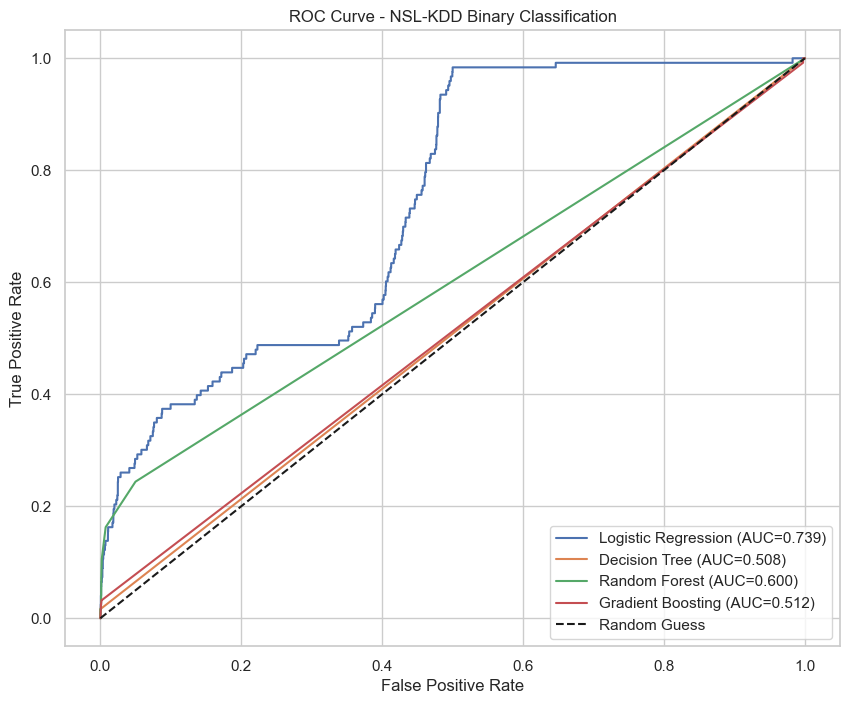

In [40]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

sns.set(style='whitegrid')

# Load dataset
column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label"
]

train_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTrain+.txt'
test_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTest+.txt'

train_df = pd.read_csv(train_file, names=column_names)
test_df = pd.read_csv(test_file, names=column_names)

# Map numeric labels to attack types (if needed)
label_map = {
    0:'normal', 1:'neptune', 2:'warezclient', 3:'ipsweep', 4:'portsweep', 5:'teardrop',
    6:'nmap', 7:'satan', 8:'smurf', 9:'guess_passwd', 10:'pod', 11:'buffer_overflow',
    12:'imap', 13:'back', 14:'land', 15:'ftp_write', 16:'multihop', 17:'phf',
    18:'perl', 19:'spy', 20:'rootkit', 21:'loadmodule'
}
train_df['label'] = train_df['label'].map(label_map).fillna(train_df['label'])
test_df['label'] = test_df['label'].map(label_map).fillna(test_df['label'])

# Drop duplicates in training data
train_df.drop_duplicates(inplace=True)

# Binary Label: Normal vs Attack
train_df['binary_label'] = train_df['label'].apply(lambda x: 'Normal' if x=='normal' else 'Attack')
test_df['binary_label'] = test_df['label'].apply(lambda x: 'Normal' if x=='normal' else 'Attack')

# Feature-target split
X_train_full = train_df.drop(['label', 'binary_label'], axis=1)
y_train_full = train_df['binary_label']

X_test = test_df.drop(['label', 'binary_label'], axis=1)
y_test = test_df['binary_label']

categorical_features = ['protocol_type', 'service', 'flag']
numeric_features = [col for col in X_train_full.columns if col not in categorical_features]

# Convert numerics and fill missing
for col in numeric_features:
    X_train_full[col] = pd.to_numeric(X_train_full[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

X_train_full[numeric_features] = X_train_full[numeric_features].fillna(0)
X_test[numeric_features] = X_test[numeric_features].fillna(0)

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=42, stratify=y_train_full)

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Models to evaluate
models = {
    'Logistic Regression': LogisticRegression(max_iter=300),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}

def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp)

lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)

results = []

print("Binary Classification Final Results\n")

for name, model in models.items():
    print(f"Training {name}...")
    start_time = time.time()
    model.fit(X_train_processed, y_train)
    train_time = time.time() - start_time

    # Predictions
    train_preds = model.predict(X_train_processed)
    val_preds = model.predict(X_val_processed)
    test_preds = model.predict(X_test_processed)

    # Accuracy
    train_acc = accuracy_score(y_train, train_preds)
    val_acc = accuracy_score(y_val, val_preds)
    test_acc = accuracy_score(y_test, test_preds)

    # Metrics on test set
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, test_preds, average='binary', pos_label='Attack')
    spec = specificity_score(y_test, test_preds)

    # Sensitivity (Recall for Attack class)
    sensitivity = recall

    # AUC
    try:
        y_proba = model.predict_proba(X_test_processed)[:, 1]
    except AttributeError:
        y_proba = model.decision_function(X_test_processed)
        y_proba = (y_proba - y_proba.min())/(y_proba.max() - y_proba.min())  # Scale to [0,1]

    auc = roc_auc_score(y_test_bin, y_proba)

    # Store results
    results.append({
        'Model': name,
        'Sensitivity': round(sensitivity, 4),
        'Specificity': round(spec, 4),
        'Precision': round(precision, 2),
        'F1-Score': round(f1, 2),
        'AUC': round(auc, 3),
        'Train Acc': f"{train_acc*100:.2f}%",
        'Val Acc': f"{val_acc*100:.2f}%",
        'Test Acc': f"{test_acc*100:.2f}%",
        'Train Time (s)': round(train_time, 2)
    })

# Display final results table
final_results_df = pd.DataFrame(results)
print(final_results_df.to_string(index=False))

# Plot ROC curves for all models
plt.figure(figsize=(10, 8))
for name, model in models.items():
    y_proba = model.predict_proba(X_test_processed)[:,1] if hasattr(model, 'predict_proba') else None
    if y_proba is None:
        dec = model.decision_function(X_test_processed)
        y_proba = (dec - dec.min()) / (dec.max() - dec.min())
    fpr, tpr, _ = roc_curve(y_test_bin, y_proba)
    auc_val = roc_auc_score(y_test_bin, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('ROC Curve - NSL-KDD Binary Classification')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


Summary of NSL-KDD Dataset - Multi-Class
Classification

Multi-Class Classification Final Results

Training Logistic Regression...


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Training Accuracy: 0.7057
Logistic Regression Validation Accuracy: 0.6977
Logistic Regression Test Accuracy: 0.5644


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logistic Regression Classification Report:
                 precision    recall  f1-score   support

           back     0.0000    0.0000    0.0000       519
buffer_overflow     0.1394    0.0759    0.0983       461
      ftp_write     0.4067    0.0723    0.1227      1176
   guess_passwd     0.0000    0.0000    0.0000       106
           imap     0.1364    0.0062    0.0118       486
        ipsweep     0.0000    0.0000    0.0000       116
           land     0.0166    0.0041    0.0065       736
     loadmodule     0.7806    0.9590    0.8607     10694
       multihop     0.1500    0.0705    0.0959       681
        neptune     0.0000    0.0000    0.0000        87
           nmap     0.0000    0.0000    0.0000       157
         normal     0.0000    0.0000    0.0000       123
           perl     0.3502    0.4304    0.3862      2967
            phf     0.1551    0.0325    0.0538      1168
            pod     0.2727    0.0154    0.0291       195
      portsweep     0.0000    0.0000    0.00

c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Gradient Boosting Classification Report:
                 precision    recall  f1-score   support

           back     0.0556    0.0462    0.0505       519
buffer_overflow     0.1739    0.0174    0.0316       461
      ftp_write     0.1618    0.0476    0.0736      1176
   guess_passwd     0.0000    0.0000    0.0000       106
           imap     0.1042    0.0206    0.0344       486
        ipsweep     0.1000    0.0086    0.0159       116
           land     0.0952    0.0027    0.0053       736
     loadmodule     0.7725    0.9698    0.8600     10694
       multihop     0.2639    0.0837    0.1271       681
        neptune     0.0000    0.0000    0.0000        87
           nmap     0.0000    0.0000    0.0000       157
         normal     0.1176    0.0163    0.0286       123
           perl     0.5339    0.6289    0.5775      2967
            phf     0.4174    0.2012    0.2715      1168
            pod     0.0667    0.0154    0.0250       195
      portsweep     0.5000    0.0099    0.0194

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_29580\3614635672.py:167: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10').colors


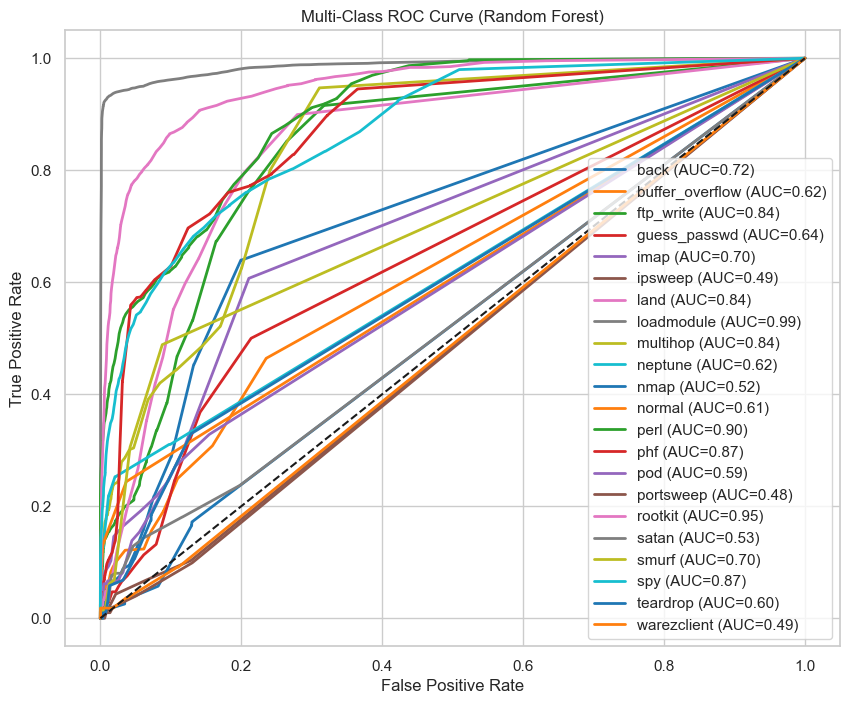

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split

sns.set(style='whitegrid')

# Dataset Columns
column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label"
]

train_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTrain+.txt'
test_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTest+.txt'

# Load datasets
train_df = pd.read_csv(train_file, names=column_names)
test_df = pd.read_csv(test_file, names=column_names)

# Map labels if needed (numeric to string)
label_map = {
    0:'normal', 1:'neptune', 2:'warezclient', 3:'ipsweep', 4:'portsweep', 5:'teardrop',
    6:'nmap', 7:'satan', 8:'smurf', 9:'guess_passwd', 10:'pod', 11:'buffer_overflow',
    12:'imap', 13:'back', 14:'land', 15:'ftp_write', 16:'multihop', 17:'phf',
    18:'perl', 19:'spy', 20:'rootkit', 21:'loadmodule'
}
train_df['label'] = train_df['label'].map(label_map).fillna(train_df['label'])
test_df['label'] = test_df['label'].map(label_map).fillna(test_df['label'])

train_df.drop_duplicates(inplace=True)

# Labels and features
y_train_full = train_df['label']
X_train_full = train_df.drop(['label'], axis=1)
y_test = test_df['label']
X_test = test_df.drop(['label'], axis=1)

categorical_features = ['protocol_type', 'service', 'flag']
numeric_features = [col for col in X_train_full.columns if col not in categorical_features]

# Numeric conversion and missing value fill
for col in numeric_features:
    X_train_full[col] = pd.to_numeric(X_train_full[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

X_train_full[numeric_features] = X_train_full[numeric_features].fillna(0)
X_test[numeric_features] = X_test[numeric_features].fillna(0)

# Train-validation split stratified
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1, stratify=y_train_full, random_state=42)

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Classifier models
models = {
    'Logistic Regression': LogisticRegression(max_iter=200, multi_class='auto'),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}

def multiclass_specificity(cm):
    specificities = []
    for i in range(cm.shape[0]):
        tn = np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1))
        fp = np.sum(np.delete(cm, i, axis=0)[:, i])
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificities.append(spec)
    return np.mean(specificities)

results = []

print("Multi-Class Classification Final Results\n")

classes = np.unique(y_train_full)
y_test_binarized = label_binarize(y_test, classes=classes)

for name, model in models.items():
    print(f"Training {name}...")
    start_time = time.time()
    model.fit(X_train_processed, y_train)
    train_time = time.time() - start_time

    train_preds = model.predict(X_train_processed)
    val_preds = model.predict(X_val_processed)
    test_preds = model.predict(X_test_processed)

    train_acc = accuracy_score(y_train, train_preds)
    val_acc = accuracy_score(y_val, val_preds)
    test_acc = accuracy_score(y_test, test_preds)

    # Macro metrics
    sens = recall_score(y_test, test_preds, average='macro', zero_division=0)  # macro-recall
    precision = precision_score(y_test, test_preds, average='macro', zero_division=0)
    f1 = f1_score(y_test, test_preds, average='macro', zero_division=0)

    # One-vs-rest ROC macro-AUC
    try:
        y_score = model.predict_proba(X_test_processed)
        auc = roc_auc_score(y_test_binarized, y_score, average='macro', multi_class='ovr')
    except Exception:
        auc = np.nan

    # Specificity (average across all classes)
    cm = confusion_matrix(y_test, test_preds, labels=classes)
    spec = multiclass_specificity(cm)

    results.append({
        'Model': name,
        'Sensitivity': round(sens, 4),
        'Specificity': round(spec, 4),
        'Precision': round(precision, 4),
        'F1-Score': round(f1, 4),
        'AUC': round(auc, 4) if not np.isnan(auc) else '-',
        'Train Acc': f"{train_acc*100:.2f}%",
        'Val Acc': f"{val_acc*100:.2f}%",
        'Test Acc': f"{test_acc*100:.2f}%",
        'Train Time (s)': round(train_time, 2)
    })

    print(f"{name} Training Accuracy: {train_acc:.4f}")
    print(f"{name} Validation Accuracy: {val_acc:.4f}")
    print(f"{name} Test Accuracy: {test_acc:.4f}")
    print(f"{name} Classification Report:\n{classification_report(y_test, test_preds, digits=4)}")

results_df = pd.DataFrame(results)

print("\nSummary Table:\n")
print(results_df)


# Plot ROC curve for Random Forest
best_model = models['Random Forest']
y_score = best_model.predict_proba(X_test_processed)

plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10').colors
for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    auc_score = roc_auc_score(y_test_binarized[:, i], y_score[:, i])
    plt.plot(fpr, tpr, lw=2, color=colors[i % 10], label=f'{class_label} (AUC={auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve (Random Forest)')
plt.legend(loc='lower right')
plt.show()


In [2]:
results_df = pd.DataFrame(results)

print("\nSummary Table:\n")
print(results_df)


Summary Table:

                 Model  Sensitivity  Specificity  Precision  F1-Score     AUC  \
0  Logistic Regression       0.1097       0.9737     0.1321    0.0953  0.7790   
1        Decision Tree       0.1660       0.9795     0.1845    0.1623  0.5731   
2        Random Forest       0.1519       0.9769     0.2478    0.1460  0.7006   
3    Gradient Boosting       0.1320       0.9757     0.1931    0.1237  0.7840   

  Train Acc Val Acc Test Acc  Train Time (s)  
0    70.57%  69.77%   56.44%           41.23  
1    99.96%  89.79%   62.79%           21.86  
2    99.96%  89.94%   62.04%          731.64  
3    78.25%  76.80%   60.73%         1975.80  


Summary of CICIDS2017 Dataset - Binary
Classification


Training Logistic Regression...

Training Decision Tree...

Training Random Forest...

Training Gradient Boosting...

Summary Table:
              Model  Sensitivity  Specificity  Precision  F1-Score    AUC Train Acc Val Acc Test Acc  Train Time (s)
Logistic Regression       0.9996       0.9744     0.9808    0.9901 0.0003    98.89%  98.85%   98.87%            1.56
      Decision Tree       0.9997       0.9992     0.9994    0.9995 0.0006   100.00%  99.97%   99.95%            2.08
      Random Forest       0.9997       0.9999     1.0000    0.9998 0.0000   100.00%  99.99%   99.98%           37.03
  Gradient Boosting       0.9997       0.9997     0.9998    0.9997 0.0000    99.98%  99.96%   99.97%          213.16


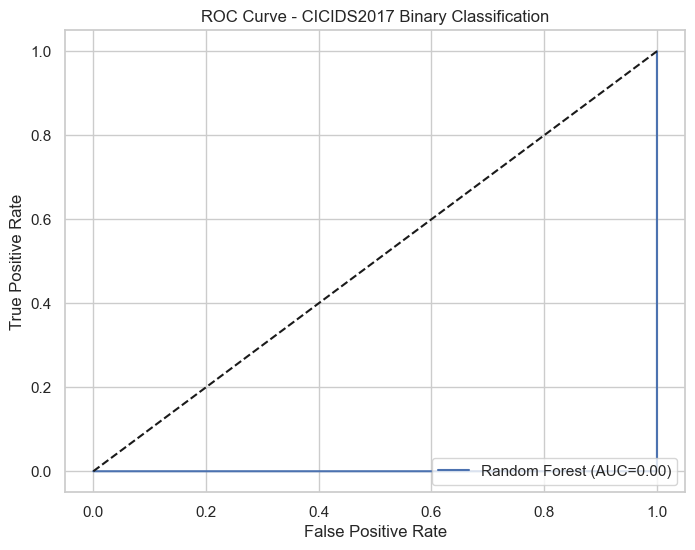

In [4]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split

sns.set(style='whitegrid')

# === LOAD & PREPROCESS DATA ===
df = pd.read_csv(r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\CICIDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
df.columns = df.columns.str.strip()

label_col = 'Label'  # change if yours is different
df[label_col] = df[label_col].str.strip()  # clean up

# Map to binary: Normal vs Attack
df['binary_label'] = df[label_col].apply(lambda x: 'Normal' if x.lower() == 'benign' or x.lower() == 'normal' else 'Attack')

X = df.drop([label_col, 'binary_label'], axis=1)
y = df['binary_label']

categorical_features = X.select_dtypes(include='object').columns.tolist()
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

# Convert columns to numeric and handle infinite and missing values
for col in numeric_features:
    X[col] = pd.to_numeric(X[col], errors='coerce')
# Replace infinite by NaN, then fill NaNs with zero for numeric columns
X[numeric_features] = X[numeric_features].replace([np.inf, -np.inf], np.nan).fillna(0)

# Train, val, test split (60/20/20)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=300),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}

def binary_specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=['Normal', 'Attack'])
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    start_time = time.time()
    model.fit(X_train_processed, y_train)
    train_time = time.time() - start_time

    train_pred = model.predict(X_train_processed)
    val_pred = model.predict(X_val_processed)
    test_pred = model.predict(X_test_processed)

    train_acc = accuracy_score(y_train, train_pred)
    val_acc = accuracy_score(y_val, val_pred)
    test_acc = accuracy_score(y_test, test_pred)
    sensitivity = recall_score(y_test, test_pred, pos_label='Attack')
    specificity = binary_specificity(y_test, test_pred)
    precision = precision_score(y_test, test_pred, pos_label='Attack')
    f1 = f1_score(y_test, test_pred, pos_label='Attack')

    try:
        y_score = model.predict_proba(X_test_processed)[:, 1]
        auc = roc_auc_score((y_test == 'Attack').astype(int), y_score)
    except Exception:
        auc = np.nan

    results.append({
        'Model': name,
        'Sensitivity': round(sensitivity,4),
        'Specificity': round(specificity,4),
        'Precision': round(precision,4),
        'F1-Score': round(f1,4),
        'AUC': round(auc,4) if not np.isnan(auc) else '-',
        'Train Acc': f"{train_acc*100:.2f}%",
        'Val Acc': f"{val_acc*100:.2f}%",
        'Test Acc': f"{test_acc*100:.2f}%",
        'Train Time (s)': round(train_time,2)
    })

results_df = pd.DataFrame(results)
print("\nSummary Table:")
print(results_df.to_string(index=False))

# Optional: ROC Curve for best model (Random Forest)
best_model = models['Random Forest']
y_score_best = best_model.predict_proba(X_test_processed)[:, 1]
fpr, tpr, _ = roc_curve((y_test == 'Attack').astype(int), y_score_best)
auc_score = roc_auc_score((y_test == 'Attack').astype(int), y_score_best)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC={auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CICIDS2017 Binary Classification')
plt.legend(loc='lower right')
plt.show()


Summary of CICIDS2017 Dataset - Multi-Class
Classification


Training Logistic Regression...


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Training Decision Tree...

Training Random Forest...

Training Gradient Boosting...

Summary Table:
              Model  Sensitivity  Specificity  Precision  F1-Score AUC Train Acc Val Acc Test Acc  Train Time (s)
Logistic Regression       0.9870       0.9870     0.9901    0.9884   -    98.89%  98.85%   98.87%            2.76
      Decision Tree       0.9995       0.9995     0.9995    0.9995   -   100.00%  99.97%   99.95%            4.21
      Random Forest       0.9998       0.9998     0.9998    0.9998   -   100.00%  99.99%   99.98%           53.65
  Gradient Boosting       0.9997       0.9997     0.9997    0.9997   -    99.98%  99.96%   99.97%          280.49


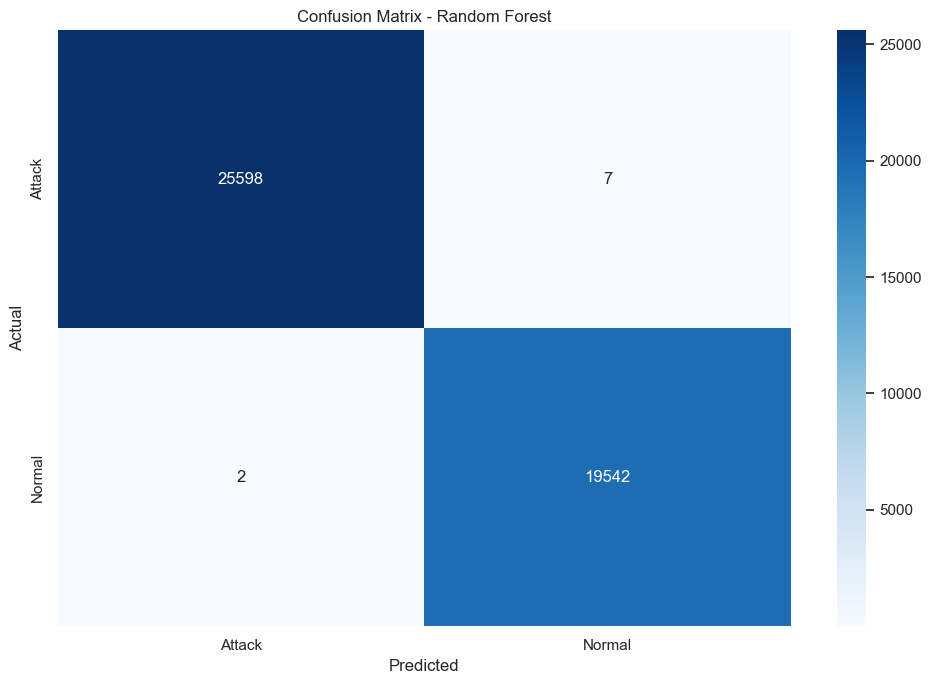

In [6]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split

sns.set(style='whitegrid')

# === LOAD & PREPROCESS DATA ===
df = pd.read_csv(r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\CICIDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
df.columns = df.columns.str.strip()

label_col = 'Label'
df[label_col] = df[label_col].astype(str).str.strip()

# Map to binary: Normal vs Attack
df['binary_label'] = df[label_col].apply(lambda x: 'Normal' if x.lower() == 'benign' or x.lower() == 'normal' else 'Attack')

X = df.drop([label_col, 'binary_label'], axis=1)
y = df['binary_label']

categorical_features = X.select_dtypes(include='object').columns.tolist()
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

# Convert columns to numeric and handle infinite and missing values
for col in numeric_features:
    X[col] = pd.to_numeric(X[col], errors='coerce')
# Replace infinite values with NaN, then fill NaNs with zero
X[numeric_features] = X[numeric_features].replace([np.inf, -np.inf], np.nan).fillna(0)

# Split dataset: 60/20/20
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# Fit and transform train, transform val and test
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=300, multi_class='auto', solver='lbfgs'),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}

def multiclass_specificity(cm):
    # Mean specificity across classes
    specs = []
    for i in range(cm.shape[0]):
        tn = np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1))
        fp = np.sum(np.delete(cm, i, axis=0)[:, i])
        specs.append(tn / (tn + fp) if (tn + fp) else 0)
    return np.mean(specs)

results = []
classes = np.unique(y)

# Binarize labels for ROC AUC
y_test_binarized = label_binarize(y_test, classes=classes)

for name, model in models.items():
    print(f"\nTraining {name}...")
    start_time = time.time()
    model.fit(X_train_processed, y_train)
    train_time = time.time() - start_time

    train_pred = model.predict(X_train_processed)
    val_pred = model.predict(X_val_processed)
    test_pred = model.predict(X_test_processed)

    train_acc = accuracy_score(y_train, train_pred)
    val_acc = accuracy_score(y_val, val_pred)
    test_acc = accuracy_score(y_test, test_pred)

    sensitivity = recall_score(y_test, test_pred, average='macro', zero_division=0)
    precision = precision_score(y_test, test_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, test_pred, average='macro', zero_division=0)

    # ROC-AUC
    try:
        y_score = model.predict_proba(X_test_processed)
        auc = roc_auc_score(y_test_binarized, y_score, average='macro', multi_class='ovr')
    except Exception:
        auc = np.nan

    cm = confusion_matrix(y_test, test_pred, labels=classes)
    specificity = multiclass_specificity(cm)

    results.append({
        'Model': name,
        'Sensitivity': round(sensitivity,4),
        'Specificity': round(specificity,4),
        'Precision': round(precision,4),
        'F1-Score': round(f1,4),
        'AUC': round(auc,4) if not np.isnan(auc) else '-',
        'Train Acc': f"{train_acc*100:.2f}%",
        'Val Acc': f"{val_acc*100:.2f}%",
        'Test Acc': f"{test_acc*100:.2f}%",
        'Train Time (s)': round(train_time,2)
    })

# Results table
import pandas as pd
results_df = pd.DataFrame(results)
print("\nSummary Table:")
print(results_df.to_string(index=False))

# Plot confusion matrix for the best model based on test accuracy
best_model_idx = max(range(len(results)), key=lambda i: float(str(results[i]['Test Acc']).replace('%', '')))
best_model_name = results[best_model_idx]['Model']
best_model = models[best_model_name]
best_pred = best_model.predict(X_test_processed)

# Plot confusion matrix
import seaborn as sns
plt.figure(figsize=(10, 7))
cm_best = confusion_matrix(y_test, best_pred, labels=classes)
sns.heatmap(cm_best, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()



Training Logistic Regression...


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Training Decision Tree...

Training Random Forest...

Training Gradient Boosting...

Summary Table:

              Model  Sensitivity  Specificity  Precision  F1-Score AUC Train Acc Val Acc Test Acc  Train Time (s)
Logistic Regression       0.9875       0.9875     0.9906    0.9890   -    98.90%  98.78%   98.92%            1.53
      Decision Tree       1.0000       1.0000     0.9999    1.0000   -   100.00%  99.99%  100.00%            3.65
      Random Forest       0.9999       0.9999     0.9999    0.9999   -   100.00%  99.99%   99.99%           40.86
  Gradient Boosting       0.9998       0.9998     0.9998    0.9998   -    99.99%  99.98%   99.98%          266.70


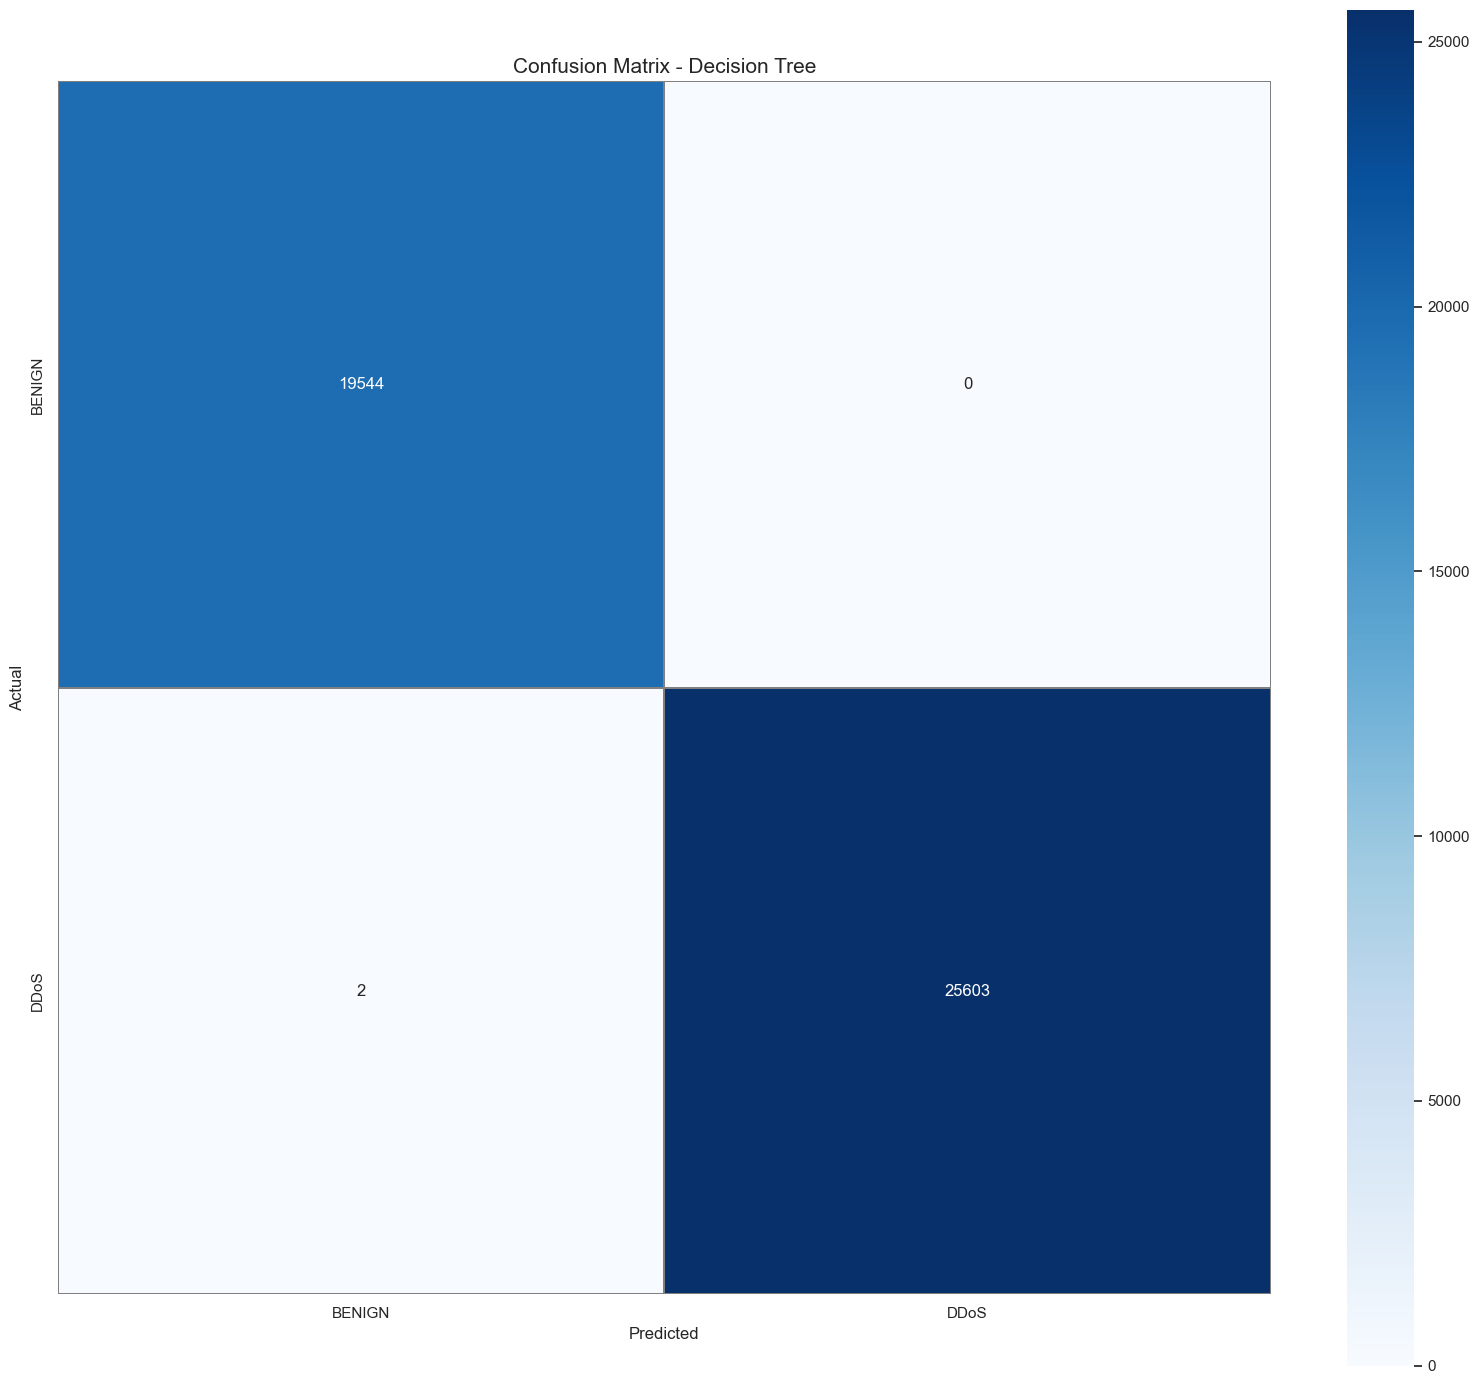

In [7]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split

sns.set(style='whitegrid')

# Load dataset
df = pd.read_csv(r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\CICIDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
df.columns = df.columns.str.strip()

label_col = 'Label'
df[label_col] = df[label_col].astype(str).str.strip()

X = df.drop([label_col], axis=1)
y = df[label_col]

# Identify categorical and numeric columns
categorical_features = X.select_dtypes(include='object').columns.tolist()
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

# Convert numeric columns to numeric type, handle errors
for col in numeric_features:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Replace infinite values with NaN and fill NaNs with 0
X[numeric_features] = X[numeric_features].replace([np.inf, -np.inf], np.nan).fillna(0)

# Split dataset: train (60%), val (20%), test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# Preprocessing pipeline for numeric scaling and categorical encoding
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=300, multi_class='auto', solver='lbfgs'),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}

def macro_specificity(cm):
    specs = []
    for i in range(cm.shape[0]):
        tn = np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1))
        fp = np.sum(np.delete(cm, i, axis=0)[:, i])
        spec = tn / (tn + fp) if (tn + fp) else 0
        specs.append(spec)
    return np.mean(specs)

results = []
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

for name, model in models.items():
    print(f"\nTraining {name}...")
    start_time = time.time()
    model.fit(X_train_processed, y_train)
    train_time = time.time() - start_time

    train_pred = model.predict(X_train_processed)
    val_pred = model.predict(X_val_processed)
    test_pred = model.predict(X_test_processed)

    train_acc = accuracy_score(y_train, train_pred)
    val_acc = accuracy_score(y_val, val_pred)
    test_acc = accuracy_score(y_test, test_pred)

    sensitivity = recall_score(y_test, test_pred, average='macro', zero_division=0)
    precision = precision_score(y_test, test_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, test_pred, average='macro', zero_division=0)

    try:
        y_score = model.predict_proba(X_test_processed)
        auc = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')
    except Exception:
        auc = np.nan

    cm = confusion_matrix(y_test, test_pred, labels=classes)
    specificity = macro_specificity(cm)

    results.append({
        'Model': name,
        'Sensitivity': round(sensitivity, 4),
        'Specificity': round(specificity, 4),
        'Precision': round(precision, 4),
        'F1-Score': round(f1, 4),
        'AUC': round(auc, 4) if not np.isnan(auc) else '-',
        'Train Acc': f"{train_acc*100:.2f}%",
        'Val Acc': f"{val_acc*100:.2f}%",
        'Test Acc': f"{test_acc*100:.2f}%",
        'Train Time (s)': round(train_time, 2)
    })

# Summary table
results_df = pd.DataFrame(results)
print("\nSummary Table:\n")
print(results_df.to_string(index=False))

# Plot confusion matrix for best model based on test accuracy
best_model_index = max(range(len(results)), key=lambda i: float(results[i]['Test Acc'].strip('%')))
best_model_name = results[best_model_index]['Model']
best_model = models[best_model_name]
best_pred = best_model.predict(X_test_processed)

plt.figure(figsize=(16, 14))
cm_best = confusion_matrix(y_test, best_pred, labels=classes)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, square=True,
            cbar=True, linewidths=0.2, linecolor='gray')
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=15)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()
